# Taxonomy Group Analysis: Main Groups & Subgroups Across Tiers

**Scope:** Group-level analysis aggregating 368 topics into taxonomy main groups and subgroups. Uses dual normalization (absolute vs conditional shares) to handle OTHER bucket variation. Compares distributions across Top/Middle/Trash tiers.

**Key Pipeline Truths:**
1. **OTHER bucket** (~0.32 mean mass) differs by tier - must normalize conditionally
2. **Author-signature topics** (41 high-dominant) excluded from main comparisons
3. **Gate 3 filter**: prevalence >= 0.10 AND NOT author-dominant

**Statistical Procedures:**
- **Kruskal-Wallis test**: Non-parametric test for differences across 3+ groups (Top/Middle/Trash)
- **Mann-Whitney U test**: Pairwise comparisons between tiers
- **Cliff's Delta**: Effect size for ordinal data (interpretation: |δ| < 0.147 = negligible, 0.147-0.33 = small, 0.33-0.474 = medium, > 0.474 = large)
- **Epsilon-squared**: Effect size for Kruskal-Wallis (interpretation: ε² < 0.01 = negligible, 0.01-0.06 = small, 0.06-0.14 = medium, > 0.14 = large)
- **Holm correction**: Multiple comparison correction for pairwise tests

**Outputs:** `results/stage10_correlation_analysis/02_taxonomy_group_analysis/` (figures, tables)


In [70]:
# 1. Setup & Imports
# NOTE: Always use venv for Python commands
# If running from terminal: source venv/bin/activate

from __future__ import annotations

import os
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.stats import mannwhitneyu, kruskal
from statsmodels.stats.multitest import multipletests

# ----------------------------
# Global plotting style + color policy
# ----------------------------
import matplotlib as mpl
import matplotlib.ticker as mtick
from matplotlib.colors import TwoSlopeNorm

# Set plotting defaults
sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)
mpl.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
})

# Inline plotting for notebook
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import warnings
warnings.filterwarnings('ignore', message='.*IProgress not found.*')
warnings.filterwarnings('ignore', category=UserWarning, module='tqdm.auto')

PROJECT_ROOT = None  # set below
print(f"✓ PROJECT_ROOT: {PROJECT_ROOT}")

# --- Tier policy (ALWAYS) ---
TIER_ORDER_RAW = ["top", "middle", "trash"]
TIER_ORDER_DISPLAY = ["Top", "Middle", "Trash"]
TIER_MAP = {"top": "Top", "middle": "Middle", "trash": "Trash"}

TIER_COLORS = {"top": "#d62728", "middle": "#ff7f0e", "trash": "#1f77b4"}  # Top red, Trash blue
TIER_COLORS_DISPLAY = {"Top": TIER_COLORS["top"], "Middle": TIER_COLORS["middle"], "Trash": TIER_COLORS["trash"]}

# --- Effect/heatmap policy (ALWAYS) ---
# 1) For "temperature" (magnitudes like shares): high = red
HEATMAP_MAG_CMAP = "Reds"   # sequential: higher -> darker red

# 2) For effects (Top - Trash): positive = red, negative = blue, centered at 0
EFFECT_CMAP_MPL = "RdBu_r"  # diverging with red on positive side
EFFECT_CMAP_PLOTLY = [(0.0, "#2166ac"), (0.5, "#f7f7f7"), (1.0, "#b2182b")]  # blue -> white -> red

def ensure_tier_display(df, raw_col="rating_tier", out_col="Tier"):
    df = df.copy()
    df[out_col] = df[raw_col].map(TIER_MAP)
    df[out_col] = pd.Categorical(df[out_col], categories=TIER_ORDER_DISPLAY, ordered=True)
    return df

def symmetric_norm(values, fallback=0.25):
    """
    Returns (norm, lim) where lim = max(|values|) and norm centers at 0.
    For diverging colormaps (effects, deltas).
    """
    v = np.asarray(values, dtype=float)
    v = v[np.isfinite(v)]
    lim = fallback if v.size == 0 else float(np.max(np.abs(v)))
    lim = max(lim, 1e-9)
    return TwoSlopeNorm(vmin=-lim, vcenter=0.0, vmax=lim), lim

def symmetric_effect_norm(values, default=0.35):
    """
    Returns (norm, lim) where lim = max(|values|) and norm centers at 0.
    Alias for symmetric_norm for backward compatibility.
    """
    return symmetric_norm(values, fallback=default)

print("✓ Global plotting style and color policy defined")


def find_project_root() -> Path:
    """
    Resolve project root robustly.
    Priority:
      1) ROMANCE_ROOT env var
      2) walk up from CWD until a folder contains both 'data' and 'results'
    """
    env = os.environ.get("ROMANCE_ROOT", "").strip()
    if env:
        p = Path(env).expanduser().resolve()
        if p.exists():
            return p
    cur = Path.cwd().resolve()
    for p in [cur] + list(cur.parents):
        if (p / "data").exists() and (p / "results").exists():
            return p
    # fallback: current directory
    return cur

PROJECT_ROOT = find_project_root()
print("PROJECT_ROOT:", PROJECT_ROOT)

✓ PROJECT_ROOT: None
✓ Global plotting style and color policy defined
PROJECT_ROOT: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor


In [71]:
# ============================
# Plot Utilities Toolkit
# ============================
# Helper functions that enforce consistent colors, scales, and legends
# across all plots in this notebook.

def heatmap_magnitude_sns(
    pivot_df: pd.DataFrame,
    title: str,
    cbar_label: str,
    vmin: float = 0.0,
    vmax: float | None = None,
    cmap: str = HEATMAP_MAG_CMAP,
    annotate: bool | None = None,
    fmt: str = ".2f",
    figsize=(10, 6),
    linewidths=0.5,
):
    """
    For magnitudes (e.g., mean shares). High = red. Comparable across plots if you fix vmax globally.
    """
    if annotate is None:
        annotate = (pivot_df.size <= 160)
    if vmax is None:
        vmax = float(np.nanmax(pivot_df.values)) if np.isfinite(pivot_df.values).any() else 1.0

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        pivot_df,
        ax=ax,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        annot=annotate,
        fmt=fmt,
        linewidths=linewidths,
        cbar_kws={"label": cbar_label},
    )
    ax.set_title(title)
    plt.tight_layout()
    return fig, ax


def heatmap_effect_sns(
    pivot_df: pd.DataFrame,
    title: str,
    cbar_label: str,
    lim: float | None = None,
    annotate: bool | None = None,
    fmt: str = ".3f",
    figsize=(10, 6),
    linewidths=0.5,
):
    """
    For signed effects (e.g., Top - Trash). Positive = red, negative = blue, centered at 0.
    """
    if annotate is None:
        annotate = (pivot_df.size <= 200)

    values = pivot_df.values.flatten()
    norm, auto_lim = symmetric_norm(values, fallback=0.10)
    if lim is None:
        lim = auto_lim
    norm = TwoSlopeNorm(vmin=-lim, vcenter=0.0, vmax=lim)

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        pivot_df,
        ax=ax,
        cmap=EFFECT_CMAP_MPL,
        norm=norm,
        annot=annotate,
        fmt=fmt,
        linewidths=linewidths,
        cbar_kws={'label': cbar_label}
    )
    ax.set_title(title)
    plt.tight_layout()
    return fig, ax


def bar_effect_plotly(
    df: pd.DataFrame,
    x: str,
    y: str,
    title: str,
    label: str,
    sort: bool = True,
    height: int = 500
):
    """
    Plotly horizontal bar:
      - bar length = effect
      - bar color = effect with diverging scale (red positive, blue negative)
      - symmetric range around 0
    """
    d = df.copy()
    if sort:
        d = d.sort_values(x, ascending=True)

    lim = float(np.nanmax(np.abs(d[x].values))) if len(d) else 0.5
    lim = max(lim, 1e-6)

    fig = px.bar(
        d,
        x=x,
        y=y,
        orientation='h',
        color=x,
        color_continuous_scale=EFFECT_CMAP_PLOTLY,
        range_color=[-lim, lim],
        color_continuous_midpoint=0.0,
        title=title,
        labels={x: label},
        height=height
    )
    fig.update_layout(coloraxis_colorbar=dict(title=label))
    return fig


def violin_shares_sns(
    df: pd.DataFrame,
    x: str,
    y: str,
    hue: str = 'Tier',
    title: str = '',
    figsize=(12, 5),
    ylim=(0, 1),
    show_points=True,
    percent=False
):
    """
    Tiered violin/box hybrid that won't swap tier colors.
    """
    fig, ax = plt.subplots(figsize=figsize)
    sns.violinplot(
        data=df,
        x=x, y=y,
        hue=hue,
        hue_order=TIER_ORDER_DISPLAY,
        palette=TIER_COLORS_DISPLAY,
        cut=0,
        inner='quartile',
        ax=ax
    )
    if show_points:
        sns.stripplot(
            data=df, x=x, y=y, hue=hue,
            hue_order=TIER_ORDER_DISPLAY,
            palette=TIER_COLORS_DISPLAY,
            dodge=True,
            alpha=0.35,
            size=2.5,
            ax=ax
        )
        # stripplot duplicates legend entries; remove duplicates:
        handles, labels = ax.get_legend_handles_labels()
        # keep only first 3 (Top/Middle/Trash)
        ax.legend(handles[:3], labels[:3], title=hue, loc='upper right')
    else:
        ax.legend(title=hue, loc='upper right')

    ax.set_title(title)
    if ylim is not None:
        ax.set_ylim(*ylim)
    if percent:
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    plt.tight_layout()
    return fig, ax


def effect_heatmap_plotly(matrix_df: pd.DataFrame, title: str, colorbar_title: str, lim: float | None = None):
    """
    Plotly matrix heatmap for *precomputed* effect matrices.
    Use px.imshow (NOT density_heatmap).
    """
    z = matrix_df.values.astype(float)
    if lim is None:
        lim = float(np.nanmax(np.abs(z))) if np.isfinite(z).any() else 0.10
    lim = max(lim, 1e-9)

    fig = px.imshow(
        matrix_df,
        color_continuous_scale=EFFECT_CMAP_PLOTLY,
        zmin=-lim,
        zmax=lim,
        title=title,
        aspect="auto",
    )
    fig.update_layout(coloraxis_colorbar=dict(title=colorbar_title))
    return fig

print("✓ Plot utilities toolkit loaded")

✓ Plot utilities toolkit loaded


## 2. Statistical Helper Functions

**Cliff's Delta**: Non-parametric effect size measure for ordinal data. Compares the proportion of times values in one group exceed values in another group.

**Epsilon-squared**: Effect size for Kruskal-Wallis test, analogous to eta-squared for ANOVA. Measures the proportion of variance explained by group membership.


In [72]:
def cliffs_delta(x: np.ndarray, y: np.ndarray) -> float:
    """
    Cliff's delta effect size for ordinal data.
    
    Interpretation:
    - |δ| < 0.147: negligible
    - 0.147 ≤ |δ| < 0.33: small
    - 0.33 ≤ |δ| < 0.474: medium
    - |δ| ≥ 0.474: large
    """
    x = np.asarray(x)
    y = np.asarray(y)
    gt = np.sum(x[:, None] > y[None, :])
    lt = np.sum(x[:, None] < y[None, :])
    return (gt - lt) / (len(x) * len(y))


def compute_epsilon_squared(kruskal_stat: float, n: int, k: int) -> float:
    """
    Epsilon-squared effect size for Kruskal-Wallis test.
    
    Interpretation:
    - ε² < 0.01: negligible
    - 0.01 ≤ ε² < 0.06: small
    - 0.06 ≤ ε² < 0.14: medium
    - ε² ≥ 0.14: large
    """
    return (kruskal_stat - (k - 1)) / (n - k)


def unify_book_id_dtype(df: pd.DataFrame) -> pd.DataFrame:
    """Ensure book_id is Int64 dtype."""
    if 'book_id' in df.columns:
        df['book_id'] = pd.to_numeric(df['book_id'], errors='coerce').astype('Int64')
    return df

print("✓ Helper functions defined")

✓ Helper functions defined


## 3. Paths & Output Configuration

Setup data input paths and output directories. Outputs will be saved to a dedicated subfolder for this analysis.


In [73]:
# 3. Paths & configuration (contract-aware)
RESULTS_DIR = PROJECT_ROOT / "results"
DATA_DIR = PROJECT_ROOT / "data"

CANDIDATE_DATA_PREP_DIRS = [
    RESULTS_DIR / "stage10_correlation_analysis" / "00_data_preparation",
    RESULTS_DIR / "stage10_correlation_analysis" / "01_data_preparation",
    RESULTS_DIR / "stage10_correlation_analysis" / "data_preparation",
    RESULTS_DIR / "correlation_analysis" / "data_preparation",
]

def pick_existing(paths):
    for p in paths:
        if p.exists():
            return p
    return paths[0]

def find_file(candidates):
    """Try multiple candidate paths and return the first that exists, or the first candidate if none exist."""
    for candidate in candidates:
        if candidate.exists():
            return candidate
    return candidates[0]  # Return first candidate even if it doesn't exist (for error messages)

DATA_PREP_DIR = pick_existing(CANDIDATE_DATA_PREP_DIRS)
# Ensure the directory exists (create if needed)
DATA_PREP_DIR.mkdir(parents=True, exist_ok=True)

# Try multiple candidate paths for subdirectories
# (matching patterns from composite notebook and archive)
TOPIC_PROBS_CANDIDATES = [
    DATA_PREP_DIR / "topic_probabilities",
    RESULTS_DIR / "stage10_correlation_analysis" / "00_data_preparation" / "topic_probabilities",
    RESULTS_DIR / "stage10_correlation_analysis" / "data_preparation" / "topic_probabilities",
    RESULTS_DIR / "correlation_analysis" / "data_preparation" / "topic_probabilities",  # archive pattern
]
TOPIC_PROBS_DIR = pick_existing(TOPIC_PROBS_CANDIDATES)
TOPIC_PROBS_DIR.mkdir(parents=True, exist_ok=True)

TAXONOMY_RADWAY_CANDIDATES = [
    DATA_PREP_DIR / "taxonomy_radway_eda",
    RESULTS_DIR / "stage10_correlation_analysis" / "00_data_preparation" / "taxonomy_radway_eda",
    RESULTS_DIR / "stage10_correlation_analysis" / "data_preparation" / "taxonomy_radway_eda",  # composite notebook pattern
    RESULTS_DIR / "correlation_analysis" / "data_preparation" / "taxonomy_radway_eda",  # archive pattern
]
TAXONOMY_RADWAY_DIR = pick_existing(TAXONOMY_RADWAY_CANDIDATES)
TAXONOMY_RADWAY_DIR.mkdir(parents=True, exist_ok=True)

AUTHOR_DOMINANCE_PATH = TAXONOMY_RADWAY_DIR / "author_dominance.parquet"  # optional

# Topic probability inputs (allow overrides via env vars, but resolve to absolute paths)
BOOK_TOPIC_PROBS_PATH = None
env_book = os.environ.get("BOOK_TOPIC_PROBS_PATH", "").strip()
if env_book:
    candidate = Path(env_book).expanduser().resolve()
    if candidate.exists():
        BOOK_TOPIC_PROBS_PATH = candidate
if BOOK_TOPIC_PROBS_PATH is None:
    # Try multiple candidate paths (matching patterns from composite notebook and archive)
    book_candidates = [
        TOPIC_PROBS_DIR / "book_topic_probs.parquet",
        RESULTS_DIR / "stage10_correlation_analysis" / "00_data_preparation" / "topic_probabilities" / "book_topic_probs.parquet",
        RESULTS_DIR / "stage10_correlation_analysis" / "data_preparation" / "topic_probabilities" / "book_topic_probs.parquet",
        RESULTS_DIR / "correlation_analysis" / "data_preparation" / "topic_probabilities" / "book_topic_probs.parquet",
    ]
    BOOK_TOPIC_PROBS_PATH = find_file(book_candidates)

TOPIC_LOOKUP_PATH = None
env_lookup = os.environ.get("TOPIC_LOOKUP_PATH", "").strip()
if env_lookup:
    candidate = Path(env_lookup).expanduser().resolve()
    if candidate.exists():
        TOPIC_LOOKUP_PATH = candidate
if TOPIC_LOOKUP_PATH is None:
    # Try multiple candidate paths (matching patterns from composite notebook and archive)
    lookup_candidates = [
        TAXONOMY_RADWAY_DIR / "topic_lookup.parquet",
        RESULTS_DIR / "stage10_correlation_analysis" / "00_data_preparation" / "taxonomy_radway_eda" / "topic_lookup.parquet",
        RESULTS_DIR / "stage10_correlation_analysis" / "data_preparation" / "taxonomy_radway_eda" / "topic_lookup.parquet",  # composite notebook pattern
        RESULTS_DIR / "correlation_analysis" / "data_preparation" / "taxonomy_radway_eda" / "topic_lookup.parquet",  # archive pattern
        PROJECT_ROOT / "archive" / "correlation_analysis" / "data_preparation" / "taxonomy_radway_eda" / "topic_lookup.parquet",  # archive fallback
    ]
    TOPIC_LOOKUP_PATH = find_file(lookup_candidates)

SENTENCE_DF_PATH = None
env_sentence = os.environ.get("SENTENCE_DF_PATH", "").strip()
if env_sentence:
    candidate = Path(env_sentence).expanduser().resolve()
    if candidate.exists():
        SENTENCE_DF_PATH = candidate
if SENTENCE_DF_PATH is None:
    SENTENCE_DF_PATH = (DATA_DIR / "processed" / "sentence_df_with_topics.parquet").resolve()

# Output directory: save in stage10_correlation_analysis/02_taxonomy_group_analysis/
OUTPUT_BASE_DIR = RESULTS_DIR / "stage10_correlation_analysis" / "02_taxonomy_group_analysis"
OUTPUT_DIR = OUTPUT_BASE_DIR  # Alias for compatibility
FIG_DIR = OUTPUT_BASE_DIR / "figures"
TABLE_DIR = OUTPUT_BASE_DIR / "tables_csv"  # Consistent with 01_topic_analysis structure
MAIN_GROUP_FIG_DIR = FIG_DIR / "main_group_distributions"
SUBGROUP_FIG_DIR = FIG_DIR / "subgroup_distributions"
EDA_DIR = OUTPUT_BASE_DIR  # Keep for backward compatibility
for d in [EDA_DIR, FIG_DIR, TABLE_DIR, MAIN_GROUP_FIG_DIR, SUBGROUP_FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Using DATA_PREP_DIR:", DATA_PREP_DIR)
print("BOOK_TOPIC_PROBS_PATH:", BOOK_TOPIC_PROBS_PATH, f"(exists: {BOOK_TOPIC_PROBS_PATH.exists()})")
print("TOPIC_LOOKUP_PATH:", TOPIC_LOOKUP_PATH, f"(exists: {TOPIC_LOOKUP_PATH.exists()})")
print("SENTENCE_DF_PATH:", SENTENCE_DF_PATH, f"(exists: {SENTENCE_DF_PATH.exists()})")
print("Outputs:", OUTPUT_BASE_DIR)

Using DATA_PREP_DIR: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/00_data_preparation
BOOK_TOPIC_PROBS_PATH: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/00_data_preparation/topic_probabilities/book_topic_probs.parquet (exists: True)
TOPIC_LOOKUP_PATH: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/00_data_preparation/taxonomy_radway_eda/topic_lookup.parquet (exists: True)
SENTENCE_DF_PATH: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/data/processed/sentence_df_with_topics.parquet (exists: True)
Outputs: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/02_taxonomy_group_analysis


In [74]:
# Example rows from topic_lookup: primary_categories and secondary_categories
# Display 10-20 example rows to understand tag parsing patterns

topic_lookup_example = pd.read_parquet(TOPIC_LOOKUP_PATH)
example_rows = topic_lookup_example[['topic_id', 'primary_categories', 'secondary_categories']].head(20)

print("Example rows from topic_lookup (primary_categories and secondary_categories):")
print("=" * 100)
print(example_rows.to_string(index=False))
print("=" * 100)
print(f"\nTotal rows in topic_lookup: {len(topic_lookup_example)}")
print(f"Rows with non-null primary_categories: {topic_lookup_example['primary_categories'].notna().sum()}")
print(f"Rows with non-null secondary_categories: {topic_lookup_example['secondary_categories'].notna().sum()}")

# Extract unique primary and secondary categories
print("\n" + "=" * 100)
print("UNIQUE CATEGORIES ANALYSIS")
print("=" * 100)

# Parse primary categories (comma-separated, no prefix)
primary_cats_set = set()
for val in topic_lookup_example['primary_categories'].dropna():
    if pd.notna(val) and val != 'None':
        cats = [c.strip() for c in str(val).split(',')]
        primary_cats_set.update(cats)

primary_cats_sorted = sorted(primary_cats_set)
print(f"\nPRIMARY CATEGORIES:")
print(f"  Count: {len(primary_cats_sorted)}")
print(f"  Names:")
for cat in primary_cats_sorted:
    print(f"    - {cat}")

# Parse secondary categories (comma-separated, with prefix like "setting:", "activity:", etc.)
secondary_cats_set = set()
for val in topic_lookup_example['secondary_categories'].dropna():
    if pd.notna(val) and val != 'None':
        cats = [c.strip() for c in str(val).split(',')]
        secondary_cats_set.update(cats)

secondary_cats_sorted = sorted(secondary_cats_set)
print(f"\nSECONDARY CATEGORIES:")
print(f"  Count: {len(secondary_cats_sorted)}")
print(f"  Names:")
for cat in secondary_cats_sorted:
    print(f"    - {cat}")

# Also show breakdown by prefix type for secondary categories
print(f"\nSECONDARY CATEGORIES BY PREFIX:")
secondary_by_prefix = {}
for cat in secondary_cats_sorted:
    if ':' in cat:
        prefix = cat.split(':')[0]
        if prefix not in secondary_by_prefix:
            secondary_by_prefix[prefix] = []
        secondary_by_prefix[prefix].append(cat)
    else:
        if 'no_prefix' not in secondary_by_prefix:
            secondary_by_prefix['no_prefix'] = []
        secondary_by_prefix['no_prefix'].append(cat)

for prefix in sorted(secondary_by_prefix.keys()):
    print(f"  {prefix}: {len(secondary_by_prefix[prefix])} categories")
    for cat in sorted(secondary_by_prefix[prefix]):
        print(f"    - {cat}")
print("=" * 100)

Example rows from topic_lookup (primary_categories and secondary_categories):
 topic_id                   primary_categories                                               secondary_categories
        0 relationship_conflict, domestic_life                           setting:living_room, activity:discussion
        1   physical_affection, sexual_content                                  setting:bedroom, activity:kissing
        2         sexual_content, romance_core    setting:bedroom, activity:oral_sex, sexual:clitoral_stimulation
        3         romance_core, social_setting                            setting:restaurant, activity:invitation
        4  romance_core, relationship_conflict                                setting:home, activity:conversation
        5  romance_core, relationship_conflict                               setting:home, relationship:long_term
        6   social_setting, physical_affection                              setting:table, activity:drinking_wine
        7 

## 4. Data Loading

Load all required data files: topic lookup (taxonomy mappings), author dominance flags, book topic probabilities, topic health metrics, and book features (for rating tiers).


In [75]:
print("=" * 80)
print("Loading data (normalized probs + taxonomy mappings):")
print("=" * 80)

import re

def norm_book_id(x) -> str:
    s = str(x).strip()
    if re.fullmatch(r"\d+\.0", s):
        s = s[:-2]
    return s

book_topic_probs = pd.read_parquet(BOOK_TOPIC_PROBS_PATH)
topic_lookup = pd.read_parquet(TOPIC_LOOKUP_PATH)

book_topic_probs["book_id"] = book_topic_probs["book_id"].map(norm_book_id)
topic_lookup["topic_id"] = pd.to_numeric(topic_lookup["topic_id"], errors="coerce").astype("Int64")

# Optional author dominance
author_dominance = None
if AUTHOR_DOMINANCE_PATH.exists():
    author_dominance = pd.read_parquet(AUTHOR_DOMINANCE_PATH)
    print("✓ Loaded author_dominance:", author_dominance.shape)
else:
    print("ℹ️ author_dominance not found (optional):", AUTHOR_DOMINANCE_PATH)

# Metadata for tiers/authors/titles
sent = pd.read_parquet(SENTENCE_DF_PATH)
sent["book_id"] = sent["book_id"].map(norm_book_id)
meta_cols = [c for c in ["rating_mean","rating_count","rating_class","Author","Book Title"] if c in sent.columns]
book_meta = (sent.groupby("book_id")[meta_cols].agg({c:"first" for c in meta_cols}).reset_index())
if "rating_count" in book_meta.columns:
    book_meta["log_rating_count"] = np.log1p(pd.to_numeric(book_meta["rating_count"], errors="coerce"))

# Contract check + normalize safeguard
def renormalize(df, group_cols, prob_col="prob"):
    sums = df.groupby(group_cols)[prob_col].sum()
    print(f"Prob sum contract ({group_cols}) min/median/max:", float(sums.min()), float(sums.median()), float(sums.max()))
    if not (0.99 <= float(sums.median()) <= 1.01):
        print("⚠️  Probabilities not normalized; renormalizing in-notebook (better to fix upstream).")
        df = df.merge(sums.rename("sum_prob"), on=group_cols, how="left")
        df[prob_col] = df[prob_col] / df["sum_prob"].replace(0, np.nan)
        df = df.drop(columns=["sum_prob"])
        sums2 = df.groupby(group_cols)[prob_col].sum()
        print("After renorm min/median/max:", float(sums2.min()), float(sums2.median()), float(sums2.max()))
    return df

book_topic_probs = renormalize(book_topic_probs, ["book_id"], "prob")

# Merge labels
# Check if 'label' column already exists, otherwise look for 'name' or 'topic_name'
if "label" in topic_lookup.columns:
    # Label column already exists, no need to rename
    pass
else:
    label_col = "name" if "name" in topic_lookup.columns else ("topic_name" if "topic_name" in topic_lookup.columns else None)
    if label_col is None:
        raise ValueError("topic_lookup has no label column (expected 'label', 'name', or 'topic_name'). Available columns: " + str(list(topic_lookup.columns)))
    topic_lookup = topic_lookup.rename(columns={label_col:"label"})

print("✓ book_topic_probs:", book_topic_probs.shape)
print("✓ topic_lookup:", topic_lookup.shape)
print("✓ book_meta:", book_meta.shape)

Loading data (normalized probs + taxonomy mappings):
ℹ️ author_dominance not found (optional): /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/00_data_preparation/taxonomy_radway_eda/author_dominance.parquet
Prob sum contract (['book_id']) min/median/max: 0.9999999999999999 1.0 1.0000000000000002
✓ book_topic_probs: (33856, 3)
✓ topic_lookup: (369, 21)
✓ book_meta: (92, 7)


## 5. Add OTHER Bucket (Missing Probability Mass)

Create topic_id = -1 rows for the missing probability mass per book. This ensures OTHER is tracked as a first-class variable throughout the analysis.


In [76]:
# 5. Add UNMAPPED bucket (prob mass not assigned to taxonomy groups)
# This is NOT missing normalization mass.

import warnings

# Suppress pandas fillna FutureWarning about downcasting behavior
with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore",
        message=(
            "Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. "
            "Call result.infer_objects\\(copy=False\\) instead. To opt-in to the future behavior, "
            "set `pd.set_option\\('future.no_silent_downcasting', True\\)`"
        ),
        category=FutureWarning,
        module="pandas"
    )

    # Mark mapped topics
    if 'taxonomy_main_id' not in topic_lookup.columns:
        raise ValueError('topic_lookup missing taxonomy_main_id')

    tl = topic_lookup.copy()
    tl['is_mapped'] = tl['taxonomy_main_id'].notna()
    if 'taxonomy_is_noise' in tl.columns:
        tl['is_mapped'] = tl['is_mapped'] & (~tl['taxonomy_is_noise'].fillna(False))

    mapped_topics = set(tl.loc[tl['is_mapped'], 'topic_id'].dropna().astype(int).tolist())

    mapped_mass = (book_topic_probs[book_topic_probs['topic_id'].isin(mapped_topics)]
                   .groupby('book_id')['prob'].sum().rename('mapped_mass'))

    total_mass = book_topic_probs.groupby('book_id')['prob'].sum().rename('total_mass')

    mass = pd.concat([total_mass, mapped_mass], axis=1).fillna(0.0).reset_index()
    mass['unmapped_mass'] = (mass['total_mass'] - mass['mapped_mass']).clip(lower=0.0)

print('Unmapped mass summary:')
print(mass['unmapped_mass'].describe())

unmapped_rows = mass[['book_id','unmapped_mass']].copy().rename(columns={'unmapped_mass':'prob'})
unmapped_rows['topic_id'] = -1
unmapped_rows['label'] = 'UNMAPPED_TOPICS'

Unmapped mass summary:
count    92.000000
mean      0.001469
std       0.001698
min       0.000412
25%       0.000676
50%       0.000973
75%       0.001603
max       0.010102
Name: unmapped_mass, dtype: float64


/tmp/ipykernel_117784/4055128723.py:26: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



## 5. Build Topic Taxonomy Mapping (Spine Export)

Create a single source of truth mapping file that combines taxonomy information, author dominance flags, topic health metrics, and Gate 3 pass status. This serves as the "spine" for all downstream analyses.

**Gate 3 Filter**: Topics must have prevalence >= 0.10 AND NOT be author-dominant to pass.


In [77]:
print("=" * 80)
print("Building topic_taxonomy_mapping.csv (spine):")
print("=" * 80)

# Start with topic_lookup
mapping = topic_lookup.copy()

# ---- Defensive merge: Only merge if value is not None and is DataFrame ----
# Helper function to try safely extract columns, else skip
def safe_merge(base_df, to_merge, columns, on='topic_id'):
    if to_merge is not None and isinstance(to_merge, pd.DataFrame):
        columns_present = [c for c in columns if c in to_merge.columns]
        if columns_present:
            return base_df.merge(
                to_merge[columns_present],
                on=on,
                how='left'
            )
        else:
            return base_df
    return base_df

# Initialize topic_health as None (optional - can be computed or loaded if needed)
topic_health = None

# Try to load topic_health from 01_topic_analysis output if available
TOPIC_HEALTH_PATH = RESULTS_DIR / "stage10_correlation_analysis" / "01_topic_analysis" / "tables_csv" / "topic_health_table.parquet"
if TOPIC_HEALTH_PATH.exists():
    try:
        topic_health = pd.read_parquet(TOPIC_HEALTH_PATH)
        # Ensure topic_id column exists and is numeric
        if 'topic_id' not in topic_health.columns and 'label' in topic_health.columns:
            # Merge with topic_lookup to get topic_id from label
            topic_health = topic_health.merge(
                topic_lookup[['topic_id', 'label']].drop_duplicates('label'),
                on='label',
                how='left'
            )
        print(f"✓ Loaded topic_health from: {TOPIC_HEALTH_PATH}")
    except Exception as e:
        print(f"⚠️  Could not load topic_health: {e}")
        topic_health = None
else:
    print(f"ℹ️  topic_health not found at {TOPIC_HEALTH_PATH} (optional)")

# Merge author dominance info, if available
mapping = safe_merge(
    mapping,
    author_dominance,
    ['topic_id', 'author_dominance_flag', 'top_author_share', 'is_author_driven']
)

# Merge topic health (for prevalence), if available
mapping = safe_merge(
    mapping,
    topic_health,
    ['topic_id', 'prevalence']
)

# Constants for thresholds
PREV_MIN = 0.10
AUTHOR_DOM_MIN = 0.50

# Compute Gate 3 pass: prevalence >= 0.10 AND NOT author-dominant
# Handle if 'is_author_driven' or 'prevalence' might be missing after merge
if 'prevalence' in mapping.columns and 'is_author_driven' in mapping.columns:
    mapping['gate3_pass'] = (
        (mapping['prevalence'] >= PREV_MIN) &
        (~mapping['is_author_driven'].fillna(False).infer_objects(copy=False))
    )
else:
    mapping['gate3_pass'] = False

# ----------------------------
# Add analysis flags
# ----------------------------
mapping['is_other'] = (mapping['topic_id'] == -1)

# Paratext heuristics (adjust to taste)
# Uses label/scene_summary/keywords if present
text_cols = [c for c in ['label', 'scene_summary', 'keywords'] if c in mapping.columns]

def _row_text(r):
    parts = []
    for c in text_cols:
        v = r.get(c)
        if pd.notna(v):
            parts.append(str(v).lower())
    return " ".join(parts)

paratext_patterns = [
    "acknowledg", "author's note", "authors note", "about the author",
    "newsletter", "mailing list", "bonus chapter", "epilogue note",
    "copyright", "isbn", "all rights reserved"
]

mapping['is_paratext'] = False
if len(text_cols) > 0:
    joined = mapping.apply(_row_text, axis=1)
    mapping['is_paratext'] = joined.apply(lambda s: any(p in s for p in paratext_patterns))

# Low coverage flag (do NOT automatically drop for group shares)
if 'prevalence' in mapping.columns:
    mapping['is_low_coverage'] = mapping['prevalence'].fillna(0) < PREV_MIN
else:
    mapping['is_low_coverage'] = False

# Author dominance convenience flags
if 'author_dominance_flag' in mapping.columns:
    mapping['is_author_dominant_high'] = mapping['author_dominance_flag'].fillna('') == 'high'
    mapping['is_author_dominant_med'] = mapping['author_dominance_flag'].fillna('') == 'medium'
else:
    mapping['is_author_dominant_high'] = False
    mapping['is_author_dominant_med'] = False

# Unmapped flag: topics without taxonomy_main_group or taxonomy_main_name
main_group = mapping['taxonomy_main_group'] if 'taxonomy_main_group' in mapping.columns else pd.Series([np.nan] * len(mapping))
main_name = mapping['taxonomy_main_name'] if 'taxonomy_main_name' in mapping.columns else pd.Series([np.nan] * len(mapping))
mapping['is_unmapped'] = (
    main_group.isna() | 
    main_name.isna()
) & (~mapping['is_other'].fillna(False))

# Add mapping_notes column (empty for now, can be filled manually later)
if 'mapping_notes' not in mapping.columns:
    mapping['mapping_notes'] = ''

# Ensure OTHER exists as a mapping row
if (-1 not in mapping['topic_id'].values):
    other_row = {col: np.nan for col in mapping.columns}
    other_row['topic_id'] = -1
    other_row['label'] = "OTHER (Missing/Noise Mass)"
    other_row['is_other'] = True
    other_row['is_paratext'] = False
    if 'taxonomy_is_noise' in mapping.columns:
        other_row['taxonomy_is_noise'] = True  # treat as excluded from thematic analysis
    if 'label_is_noise' in mapping.columns:
        other_row['label_is_noise'] = True
    mapping = pd.concat([mapping, pd.DataFrame([other_row])], ignore_index=True)

# Select and order columns for export
core_cols = ['topic_id', 'label', 'keywords', 'scene_summary', 'label_is_noise']
taxonomy_cols = ['taxonomy_main_group', 'taxonomy_main_name', 'taxonomy_confidence', 'taxonomy_is_noise']
taxonomy_secondary_cols = ['taxonomy_secondary_group', 'taxonomy_secondary_name']
radway_cols = ['radway_phase_name', 'radway_phase', 'radway_main_name', 'radway_confidence', 'radway_is_none']
quality_cols = ['author_dominance_flag', 'top_author_share', 'prevalence', 'gate3_pass', 'mapping_notes']
# Analysis flags
flag_cols = ['is_other', 'is_paratext', 'is_unmapped', 'is_low_coverage', 'is_author_dominant_high', 'is_author_dominant_med']

# Build final mapping table with available columns
export_cols = []
for col_list in [core_cols, taxonomy_cols, taxonomy_secondary_cols, radway_cols, quality_cols, flag_cols]:
    for col in col_list:
        if col in mapping.columns:
            export_cols.append(col)

mapping_export = mapping[export_cols].copy()

# Save
mapping_path = TABLE_DIR / "topic_taxonomy_mapping.csv"
mapping_export.to_csv(mapping_path, index=False)
mapping_export.to_csv(TABLE_DIR / "topic_taxonomy_mapping.csv", index=False)
print(f"\n✓ Saved topic_taxonomy_mapping: {mapping_path}")
print(f"  Shape: {mapping_export.shape}")
if 'taxonomy_main_group' in mapping_export.columns:
    print(f"  Topics with taxonomy_main_group: {mapping_export['taxonomy_main_group'].notna().sum()}")
if 'gate3_pass' in mapping_export.columns:
    print(f"  Topics passing Gate 3: {mapping_export['gate3_pass'].sum()}")
if 'author_dominance_flag' in mapping_export.columns:
    print(f"  High author-dominant topics: {(mapping_export['author_dominance_flag'] == 'high').sum()}")
print(f"  OTHER topics: {mapping_export['is_other'].sum()}")
print(f"  Paratext topics: {mapping_export['is_paratext'].sum()}")
print(f"  Unmapped topics: {mapping_export['is_unmapped'].sum()}")
print(f"  Low coverage topics: {mapping_export['is_low_coverage'].sum()}")

# Display sample
print(f"\nSample mapping (first 3 rows):")
display(mapping_export.head(3))

Building topic_taxonomy_mapping.csv (spine):
ℹ️  topic_health not found at /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/01_topic_analysis/tables_csv/topic_health_table.parquet (optional)

✓ Saved topic_taxonomy_mapping: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/02_taxonomy_group_analysis/tables_csv/topic_taxonomy_mapping.csv
  Shape: (369, 24)
  Topics with taxonomy_main_group: 361
  Topics passing Gate 3: 0
  OTHER topics: 1
  Paratext topics: 2
  Unmapped topics: 7
  Low coverage topics: 0

Sample mapping (first 3 rows):


,topic_id,label,keywords,scene_summary,label_is_noise,taxonomy_main_group,taxonomy_main_name,taxonomy_confidence,taxonomy_is_noise,taxonomy_secondary_group,...,radway_confidence,radway_is_none,gate3_pass,mapping_notes,is_other,is_paratext,is_unmapped,is_low_coverage,is_author_dominant_high,is_author_dominant_med
0,0,Negotiating Deal,"ita, ia, need, say, want, going, dona, means, ...",The couple discusses terms and expectations fo...,False,Relationship Trajectory (Main Couple),"Secrets, Misunderstandings & Hidden Information",medium,False,None,...,medium,False,False,,False,False,False,False,False,False
1,1,Intimate Breast And Nipple Kissing,"kissed, hips, tongue, breasts, mouth, body, ar...",He gently kisses her breasts and nipples while...,False,"Sexuality, Attraction & Intimacy",Explicit Sexual Acts,high,False,None,...,high,False,False,,False,False,False,False,False,False
2,2,Clitoral Stimulation During Foreplay,"clit, pussy, tongue, hips, legs, mouth, neck, ...","She spreads her legs, allowing him to run his ...",False,"Sexuality, Attraction & Intimacy",Explicit Sexual Acts,high,False,None,...,high,False,False,,False,False,False,False,False,False


## 6. Dual Normalization Function

**Dual Normalization Strategy**: 
- **Absolute share**: sum(topic_probs in group) / 1.0 (raw proportion of all probability mass)
- **Conditional share**: sum(topic_probs in group) / MODELED_MASS (proportion within modeled topics, excluding OTHER bucket)

This handles the fact that the OTHER bucket (~0.32 mean mass) varies by tier, which would bias absolute comparisons.


In [78]:
def compute_book_group_shares(
    book_topic_probs: pd.DataFrame,
    topic_mapping: pd.DataFrame,
    exclude_author_dominant: bool = True,
    exclude_noise: bool = True,
    exclude_paratext: bool = True,
    apply_prevalence_gate: bool = False,   # IMPORTANT: False for group shares (keep long-tail)
    prevalence_min: float = 0.10
) -> pd.DataFrame:
    """
    Book-level main-group shares with explicit coverage accounting.

    Outputs per (book_id, taxonomy_main_group):
      - abs_share: sum(prob in group) (out of 1.0)
      - cond_share: sum(prob in group) / modeled_mass
      - modeled_mass: total thematic mass used in group sums
      - other_share: mass in topic_id == -1
      - paratext_share: mass in paratext topics (excluded if exclude_paratext)
      - noise_share: mass in noise topics (excluded if exclude_noise)
      - unmapped_share: mass in unmapped topics (topics without taxonomy_main_group/name)
    """
    df0 = book_topic_probs.merge(
        topic_mapping[
            [c for c in [
                'topic_id', 'taxonomy_main_group', 'taxonomy_main_name',
                'author_dominance_flag', 'label_is_noise', 'taxonomy_is_noise',
                'is_paratext', 'is_unmapped', 'prevalence'
            ] if c in topic_mapping.columns]
        ],
        on='topic_id',
        how='left'
    )

    # --- Coverage components computed from df0 (before thematic filtering) ---
    other_by_book = df0[df0['topic_id'] == -1].groupby('book_id', as_index=False)['prob'].sum()
    other_by_book.rename(columns={'prob': 'other_share'}, inplace=True)

    # Paratext
    if 'is_paratext' in df0.columns:
        paratext_by_book = df0[df0['is_paratext'].fillna(False)].groupby('book_id', as_index=False)['prob'].sum()
        paratext_by_book.rename(columns={'prob': 'paratext_share'}, inplace=True)
    else:
        paratext_by_book = pd.DataFrame({'book_id': df0['book_id'].unique(), 'paratext_share': 0.0})

    # Noise
    noise_mask = False
    if 'label_is_noise' in df0.columns:
        noise_mask = noise_mask | df0['label_is_noise'].fillna(False).infer_objects(copy=False)
    if 'taxonomy_is_noise' in df0.columns:
        noise_mask = noise_mask | df0['taxonomy_is_noise'].fillna(False).infer_objects(copy=False)
    
    if isinstance(noise_mask, pd.Series):
        noise_by_book = df0[noise_mask].groupby('book_id', as_index=False)['prob'].sum()
        noise_by_book.rename(columns={'prob': 'noise_share'}, inplace=True)
    else:
        noise_by_book = pd.DataFrame({'book_id': df0['book_id'].unique(), 'noise_share': 0.0})

    # Unmapped (topics without taxonomy_main_group or taxonomy_main_name, excluding OTHER)
    if 'is_unmapped' in df0.columns:
        unmapped_by_book = df0[df0['is_unmapped'].fillna(False)].groupby('book_id', as_index=False)['prob'].sum()
        unmapped_by_book.rename(columns={'prob': 'unmapped_share'}, inplace=True)
    else:
        # Fallback: compute unmapped from missing taxonomy_main_group/name
        unmapped_mask = (
            (df0['taxonomy_main_group'].isna() | df0['taxonomy_main_name'].isna()) &
            (df0['topic_id'] != -1)  # Exclude OTHER
        )
        unmapped_by_book = df0[unmapped_mask].groupby('book_id', as_index=False)['prob'].sum()
        unmapped_by_book.rename(columns={'prob': 'unmapped_share'}, inplace=True)
    
    # Ensure all books have unmapped_share (fill missing with 0)
    all_books = pd.DataFrame({'book_id': df0['book_id'].unique()})
    unmapped_by_book = all_books.merge(unmapped_by_book, on='book_id', how='left')
    unmapped_by_book['unmapped_share'] = unmapped_by_book['unmapped_share'].fillna(0.0)

    # --- Build thematic dataframe for group shares ---
    df = df0.copy()

    # Remove OTHER from thematic group sums (always)
    df = df[df['topic_id'] != -1]
    
    if exclude_paratext and 'is_paratext' in df.columns:
        df = df[~df['is_paratext'].fillna(False).infer_objects(copy=False)]
    
    if exclude_author_dominant and 'author_dominance_flag' in df.columns:
        df = df[df['author_dominance_flag'] != 'high']
    
    if exclude_noise:
        if 'label_is_noise' in df.columns:
            df = df[~df['label_is_noise'].fillna(False).infer_objects(copy=False)]
        if 'taxonomy_is_noise' in df.columns:
            df = df[~df['taxonomy_is_noise'].fillna(False).infer_objects(copy=False)]

    if apply_prevalence_gate and 'prevalence' in df.columns:
        df = df[df['prevalence'].fillna(0) >= prevalence_min]

    # Modeled mass = thematic mass that remains after filters
    modeled_by_book = df.groupby('book_id', as_index=False)['prob'].sum()
    modeled_by_book.rename(columns={'prob': 'modeled_mass'}, inplace=True)

    # Compute absolute group shares
    abs_shares = df.groupby(['book_id', 'taxonomy_main_group'], as_index=False).agg(
        abs_share=('prob', 'sum'),
        n_topics_in_group=('topic_id', 'nunique')
    )

    # Attach rating tier (from original data, safest)
    if 'rating_tier' in df0.columns:
        tier_map = df0[['book_id', 'rating_tier']].drop_duplicates()
        abs_shares = abs_shares.merge(tier_map, on='book_id', how='left')

    # Attach coverage components
    abs_shares = abs_shares.merge(modeled_by_book, on='book_id', how='left')
    abs_shares = abs_shares.merge(other_by_book, on='book_id', how='left')
    abs_shares = abs_shares.merge(paratext_by_book, on='book_id', how='left')
    abs_shares = abs_shares.merge(noise_by_book, on='book_id', how='left')
    abs_shares = abs_shares.merge(unmapped_by_book, on='book_id', how='left')

    for col in ['modeled_mass', 'other_share', 'paratext_share', 'noise_share', 'unmapped_share']:
        abs_shares[col] = abs_shares[col].fillna(0.0)

    abs_shares['cond_share'] = abs_shares['abs_share'] / abs_shares['modeled_mass'].replace(0, np.nan)

    # Book-level sanity checks (optional but recommended)
    # 1) abs shares across groups sum to modeled_mass
    # 2) modeled_mass + other_share + paratext_share + noise_share + unmapped_share ≈ 1

    return abs_shares[[
        'book_id', 'rating_tier', 'taxonomy_main_group',
        'abs_share', 'cond_share',
        'modeled_mass', 'other_share', 'paratext_share', 'noise_share', 'unmapped_share',
        'n_topics_in_group'
    ]].copy()

print("✓ Helper function defined")

✓ Helper function defined


## 7. Compute Main Group Shares

Aggregate topics into taxonomy main groups and compute both absolute and conditional shares per book. This provides the foundation for comparing main group distributions across rating tiers.


In [79]:
import warnings

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    print("=" * 80)
    print("Computing book_main_group_shares:")
    print("=" * 80)

    # Merge book_meta to add rating_tier to book_topic_probs
    # Map rating_class to rating_tier (rating_class values: 'top', 'middle', 'trash')
    if 'rating_tier' not in book_topic_probs.columns:
        if 'rating_class' in book_meta.columns:
            # Create rating_tier from rating_class
            book_meta_with_tier = book_meta.copy()
            book_meta_with_tier['rating_tier'] = book_meta_with_tier['rating_class']
            # Merge into book_topic_probs
            book_topic_probs = book_topic_probs.merge(
                book_meta_with_tier[['book_id', 'rating_tier']],
                on='book_id',
                how='left'
            )
        else:
            # If rating_class doesn't exist, create rating_tier from rating_mean
            if 'rating_mean' in book_meta.columns:
                def assign_tier(rating):
                    if pd.isna(rating):
                        return None
                    if rating >= 4.0:
                        return 'top'
                    elif rating >= 3.8:
                        return 'middle'
                    else:
                        return 'trash'
                book_meta_with_tier = book_meta.copy()
                book_meta_with_tier['rating_tier'] = book_meta_with_tier['rating_mean'].apply(assign_tier)
                book_topic_probs = book_topic_probs.merge(
                    book_meta_with_tier[['book_id', 'rating_tier']],
                    on='book_id',
                    how='left'
                )

    # Add unmapped_rows (topic_id == -1) to book_topic_probs if it exists
    # This ensures other_share is calculated correctly
    if 'unmapped_rows' in locals() and unmapped_rows is not None and len(unmapped_rows) > 0:
        # Ensure unmapped_rows has required columns and add missing ones
        unmapped_for_concat = unmapped_rows[['book_id', 'topic_id', 'prob', 'label']].copy()
        # Add rating_tier if it exists in book_topic_probs
        if 'rating_tier' in book_topic_probs.columns:
            rating_tier_map = book_topic_probs[['book_id', 'rating_tier']].drop_duplicates()
            unmapped_for_concat = unmapped_for_concat.merge(
                rating_tier_map,
                on='book_id',
                how='left'
            )
        # Add any other columns from book_topic_probs that are missing
        for col in book_topic_probs.columns:
            if col not in unmapped_for_concat.columns:
                unmapped_for_concat[col] = None
        # Reorder columns to match book_topic_probs
        unmapped_for_concat = unmapped_for_concat[book_topic_probs.columns]
        # Concatenate
        book_topic_probs = pd.concat([book_topic_probs, unmapped_for_concat], ignore_index=True)
        print(f"✓ Added {len(unmapped_for_concat)} unmapped_rows (topic_id == -1) to book_topic_probs")

    book_main_group_shares = compute_book_group_shares(
        book_topic_probs,
        mapping_export,
        exclude_author_dominant=True,
        exclude_noise=True,
        exclude_paratext=True,
        apply_prevalence_gate=False  # key change: keep long-tail for composition
    )

    print(f"\n✓ Computed book_main_group_shares: {book_main_group_shares.shape}")
    print(f"  Unique books: {book_main_group_shares['book_id'].nunique()}")
    print(f"  Unique main groups: {book_main_group_shares['taxonomy_main_group'].nunique()}")
    print(f"\nMain groups:")
    print(book_main_group_shares['taxonomy_main_group'].value_counts().sort_index())

    # Sanity checks (main groups)
    print("\nSanity checks (main groups):")
    sum_abs = book_main_group_shares.groupby('book_id')['abs_share'].sum()
    modeled = book_main_group_shares.groupby('book_id')['modeled_mass'].first()
    print("  abs_share sum - modeled_mass (mean):", (sum_abs - modeled).mean())
    print("  abs_share sum - modeled_mass (max abs):", (sum_abs - modeled).abs().max())

    cov = book_main_group_shares.groupby('book_id')[['modeled_mass','other_share','paratext_share','noise_share','unmapped_share']].first()
    cov['total'] = cov.sum(axis=1)
    print("  modeled+other+paratext+noise+unmapped total: min/max:", cov['total'].min(), cov['total'].max())
    print("  mean other_share:", cov['other_share'].mean())
    print("  mean paratext_share:", cov['paratext_share'].mean())
    print("  mean noise_share:", cov['noise_share'].mean())
    print("  mean unmapped_share:", cov['unmapped_share'].mean())
    print("  Books with total ≈ 1 (within 0.01):", (cov['total'].between(0.99, 1.01)).sum(), "/", len(cov))
    print("  Books with total ≈ 1 (within 0.05):", (cov['total'].between(0.95, 1.05)).sum(), "/", len(cov))

    # Summary statistics
    print(f"\nSummary statistics:")
    display(book_main_group_shares.groupby('taxonomy_main_group').agg({
        'abs_share': ['mean', 'std'],
        'cond_share': ['mean', 'std'],
        'modeled_mass': 'mean',
        'other_share': 'mean',
        'paratext_share': 'mean',
        'noise_share': 'mean',
        'unmapped_share': 'mean'
    }).round(4))

    # Save
    book_main_group_shares.to_csv(TABLE_DIR / "book_main_group_shares.csv", index=False)
    book_main_group_shares.to_csv(TABLE_DIR / "book_main_group_shares.csv", index=False)
    print(f"\n✓ Saved to: {TABLE_DIR / 'book_main_group_shares.parquet'}")

Computing book_main_group_shares:
✓ Added 92 unmapped_rows (topic_id == -1) to book_topic_probs

✓ Computed book_main_group_shares: (736, 11)
  Unique books: 92
  Unique main groups: 8

Main groups:
taxonomy_main_group
Conflict, Risk & Harm                    92
Embodied & Sensory Experience            92
Emotions, Cognition & Inner Life         92
Relationship Trajectory (Main Couple)    92
Sexuality, Attraction & Intimacy         92
Social World Outside Couple              92
Spaces, Time, Activities & Objects       92
Work, Wealth, Status & Institutions      92
Name: count, dtype: int64

Sanity checks (main groups):
  abs_share sum - modeled_mass (mean): -0.0005086325551424903
  abs_share sum - modeled_mass (max abs): 0.009437145497364186
  modeled+other+paratext+noise+unmapped total: min/max: 1.0008234369621483 1.0202031269645226
  mean other_share: 0.001468775573534975
  mean paratext_share: 0.001971412503247748
  mean noise_share: 0.0009601430183924931
  mean unmapped_share: 0.00

abs_share         cond_share          \
                                           mean     std       mean     std   
taxonomy_main_group                                                          
Conflict, Risk & Harm                    0.0218  0.0083     0.0218  0.0083   
Embodied & Sensory Experience            0.0192  0.0057     0.0192  0.0057   
Emotions, Cognition & Inner Life         0.1920  0.0167     0.1924  0.0167   
Relationship Trajectory (Main Couple)    0.3606  0.0299     0.3613  0.0299   
Sexuality, Attraction & Intimacy         0.1904  0.0315     0.1908  0.0316   
Social World Outside Couple              0.0729  0.0218     0.0731  0.0218   
Spaces, Time, Activities & Objects       0.0755  0.0127     0.0756  0.0127   
Work, Wealth, Status & Institutions      0.0651  0.0125     0.0652  0.0125   

                                      modeled_mass other_share paratext_share  \
                                              mean        mean           mean   
taxonomy_main_group                                                             
Conflict, Risk & Harm                        0.998      0.0015          0.002   
Embodied & Sensory Experience                0.998      0.0015          0.002   
Emotions, Cognition & Inner Life             0.998      0.0015          0.002   
Relationship Trajectory (Main Couple)        0.998      0.0015          0.002   
Sexuality, Attraction & Intimacy             0.998      0.0015          0.002   
Social World Outside Couple                  0.998      0.0015          0.002   
Spaces, Time, Activities & Objects           0.998      0.0015          0.002   
Work, Wealth, Status & Institutions          0.998      0.0015          0.002   

                                      noise_share unmapped_share  
                                             mean           mean  
taxonomy_main_group                                               
Conflict, Risk & Harm                       0.001         0.0005  
Embodied & Sensory Experience               0.001         0.0005  
Emotions, Cognition & Inner Life            0.001         0.0005  
Relationship Trajectory (Main Couple)       0.001         0.0005  
Sexuality, Attraction & Intimacy            0.001         0.0005  
Social World Outside Couple                 0.001         0.0005  
Spaces, Time, Activities & Objects          0.001         0.0005  
Work, Wealth, Status & Institutions         0.001         0.0005


✓ Saved to: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/02_taxonomy_group_analysis/tables_csv/book_main_group_shares.parquet


## 7.5 Coverage Audit by Tier

Report coverage metrics (OTHER, paratext, noise, modeled mass) by rating tier to understand corpus composition differences.


## 7.5 Coverage Audit by Tier

Report coverage metrics (OTHER, paratext, noise, modeled mass) by rating tier to understand corpus composition differences.


## 7.6 Diversity Diagnostics: Testing "OTHER = Thematic Diversity" Hypothesis

Compute diversity metrics (entropy, effective topics, HHI, richness) per book and test whether higher OTHER in Top books correlates with greater thematic diversity rather than model uncertainty.


In [80]:
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=FutureWarning)

    print("=" * 80)
    print("Diversity diagnostics: testing whether OTHER signals greater thematic diversity")
    print("=" * 80)

    # Build a thematic topic matrix per book (exclude OTHER/noise/paratext; keep long tail)
    # Only select columns that exist in mapping_export
    merge_cols = ['topic_id', 'label_is_noise', 'taxonomy_is_noise', 'is_paratext', 'author_dominance_flag']
    available_cols = [c for c in merge_cols if c in mapping_export.columns]
    
    df_topics = book_topic_probs.merge(
        mapping_export[available_cols],
        on='topic_id',
        how='left'
    )

    # Thematic filter (do NOT exclude low-coverage here; do exclude true noise/paratext/OTHER)
    df_topics = df_topics[df_topics['topic_id'] != -1]
    df_topics = df_topics[~df_topics['label_is_noise'].fillna(False).infer_objects(copy=False)]
    df_topics = df_topics[~df_topics['taxonomy_is_noise'].fillna(False).infer_objects(copy=False)]
    if 'is_paratext' in df_topics.columns:
        df_topics = df_topics[~df_topics['is_paratext'].fillna(False).infer_objects(copy=False)]

    # Optional: exclude highly author-dominant for a sensitivity run (keep for main run)
    if 'author_dominance_flag' in df_topics.columns:
        df_topics = df_topics[df_topics['author_dominance_flag'] != 'high']

    # Renormalize within each book to sum to 1
    book_mass = df_topics.groupby('book_id')['prob'].sum()
    df_topics = df_topics.join(book_mass.rename('thematic_mass'), on='book_id')
    df_topics = df_topics[df_topics['thematic_mass'] > 0].copy()
    df_topics['p'] = df_topics['prob'] / df_topics['thematic_mass']

    # Diversity metrics
    eps = 1e-12

    def shannon_entropy(p):
        p = p[p > 0]
        return float(-(p * np.log(p + eps)).sum())

    def hhi(p):
        return float((p**2).sum())

    metrics = []
    for book_id, g in df_topics.groupby('book_id'):
        p = g['p'].values
        H = shannon_entropy(p)
        metrics.append({
            'book_id': book_id,
            'entropy': H,
            'effective_topics': float(np.exp(H)),
            'hhi': hhi(p),
            'richness_1e3': int((p > 0.001).sum()),
            'thematic_mass': float(g['thematic_mass'].iloc[0])
        })

    div_df = pd.DataFrame(metrics)

    # Attach coverage + tier
    cov = book_main_group_shares[['book_id','rating_tier','other_share','paratext_share','noise_share','unmapped_share','modeled_mass']].drop_duplicates()
    div_df = div_df.merge(cov, on='book_id', how='left')

    print("\nTier summaries:")
    display(div_df.groupby('rating_tier')[['other_share','entropy','effective_topics','hhi','richness_1e3','modeled_mass']].agg(['mean','median']).round(4))

    # KW tests across tiers (for diversity metrics + other_share)
    from scipy.stats import spearmanr

    def kw_by_tier(col):
        """
        Kruskal-Wallis test across rating tiers.
        Returns NaN if insufficient data or no variance (all values identical).
        Handles tier name variations: 'top'/'good', 'middle'/'mid', 'trash'/'bad'.
        """
        # Try both naming conventions
        top = div_df[div_df['rating_tier'].isin(['top', 'good'])][col].dropna()
        mid = div_df[div_df['rating_tier'].isin(['middle', 'mid'])][col].dropna()
        tr  = div_df[div_df['rating_tier'].isin(['trash', 'bad'])][col].dropna()
        
        # Check minimum sample size
        if min(len(top), len(mid), len(tr)) < 3:
            return np.nan, np.nan
        
        # Check for variance: if all values across all tiers are identical, Kruskal-Wallis cannot be computed
        all_values = np.concatenate([top.values, mid.values, tr.values])
        if len(np.unique(all_values)) <= 1:
            # All values are identical - no variance to test (e.g., other_share = 0.0 for all)
            return np.nan, np.nan
        
        try:
            stat, p = kruskal(top, mid, tr)
            return stat, p
        except (ValueError, RuntimeError) as e:
            # Handle cases where kruskal fails (e.g., all values identical within tiers)
            return np.nan, np.nan

    div_tests = []
    for col in ['other_share','entropy','effective_topics','hhi','richness_1e3']:
        stat, p = kw_by_tier(col)
        div_tests.append({'metric': col, 'kruskal_stat': stat, 'kruskal_p': p})

    div_tests = pd.DataFrame(div_tests)
    div_tests['kruskal_p_adj'] = multipletests(div_tests['kruskal_p'].fillna(1.0), method='holm')[1]

    print("\nKW tests (Holm-adjusted):")
    display(div_tests.sort_values('kruskal_p_adj'))

    # Correlation: OTHER vs diversity within tier (Spearman)
    # Map tier names: handle both 'top'/'good', 'middle'/'mid', 'trash'/'bad'
    tier_map = {'top': ['top', 'good'], 'middle': ['middle', 'mid'], 'trash': ['trash', 'bad']}
    corr_rows = []
    for tier_key, tier_values in tier_map.items():
        sub = div_df[div_df['rating_tier'].isin(tier_values)].dropna(subset=['other_share','effective_topics'])
        if len(sub) >= 8:
            # Check for constant arrays (no variance) - correlation undefined in this case
            other_vals = sub['other_share'].values
            effective_vals = sub['effective_topics'].values
            
            if len(np.unique(other_vals)) <= 1 or len(np.unique(effective_vals)) <= 1:
                # One or both arrays are constant - correlation undefined
                rho, p = np.nan, np.nan
            else:
                rho, p = spearmanr(other_vals, effective_vals)
            corr_rows.append({'tier': tier_key, 'rho_other_vs_effective_topics': rho, 'p': p, 'n': len(sub)})

    corr_df = pd.DataFrame(corr_rows)
    print("\nSpearman correlations (OTHER vs effective_topics):")
    display(corr_df)

    # Save both in parquet and csv
    div_df.to_csv(TABLE_DIR / "diversity_metrics_by_book.csv", index=False)
    div_df.to_csv(TABLE_DIR / "diversity_metrics_by_book.csv", index=False)
    div_tests.to_csv(TABLE_DIR / "diversity_tests.csv", index=False)
    div_tests.to_csv(TABLE_DIR / "diversity_tests.csv", index=False)
    corr_df.to_csv(TABLE_DIR / "diversity_spearman_corrs.csv", index=False)
    corr_df.to_csv(TABLE_DIR / "diversity_spearman_corrs.csv", index=False)
    print(f"\n✓ Saved diversity metrics to: {TABLE_DIR / 'diversity_metrics_by_book.parquet'} and .csv")
    print(f"✓ Saved diversity tests to: {TABLE_DIR / 'diversity_tests.parquet'} and .csv")
    print(f"✓ Saved diversity Spearman correlations to: {TABLE_DIR / 'diversity_spearman_corrs.parquet'} and .csv")

Diversity diagnostics: testing whether OTHER signals greater thematic diversity

Tier summaries:


other_share         entropy         effective_topics            \
                   mean  median    mean  median             mean    median   
rating_tier                                                                  
bad              0.0015  0.0009  5.3262  5.3314         208.3002  206.7438   
good             0.0018  0.0010  5.4345  5.4797         230.8526  239.7695   
mid              0.0011  0.0009  5.3681  5.4343         217.4537  229.1446   

                hhi         richness_1e3        modeled_mass          
               mean  median         mean median         mean  median  
rating_tier                                                           
bad          0.0094  0.0082     248.0000  247.0       0.9981  0.9982  
good         0.0071  0.0061     259.5333  265.0       0.9976  0.9984  
mid          0.0090  0.0066     254.2188  258.0       0.9984  0.9985


KW tests (Holm-adjusted):


,metric,kruskal_stat,kruskal_p,kruskal_p_adj
4,richness_1e3,8.445946,0.014655,0.073275
1,entropy,7.899345,0.019261,0.077044
2,effective_topics,7.899345,0.019261,0.077044
3,hhi,4.660165,0.097288,0.194575
0,other_share,0.859175,0.650778,0.650778



Spearman correlations (OTHER vs effective_topics):


,tier,rho_other_vs_effective_topics,p,n
0,top,0.076307,0.688585,30
1,middle,-0.074047,0.687124,32
2,trash,0.433148,0.016803,30



✓ Saved diversity metrics to: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/02_taxonomy_group_analysis/tables_csv/diversity_metrics_by_book.parquet and .csv
✓ Saved diversity tests to: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/02_taxonomy_group_analysis/tables_csv/diversity_tests.parquet and .csv
✓ Saved diversity Spearman correlations to: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/02_taxonomy_group_analysis/tables_csv/diversity_spearman_corrs.parquet and .csv


## 7.7 Diversity Metrics Visualization

Create visualizations showing diversity metrics distributions by tier and correlations with OTHER share.


✓ rating_tier is set: {'mid': 32, 'bad': 30, 'good': 30}

✓ Data ready for plotting. Books per tier: {'middle': 32, 'trash': 30, 'top': 30}


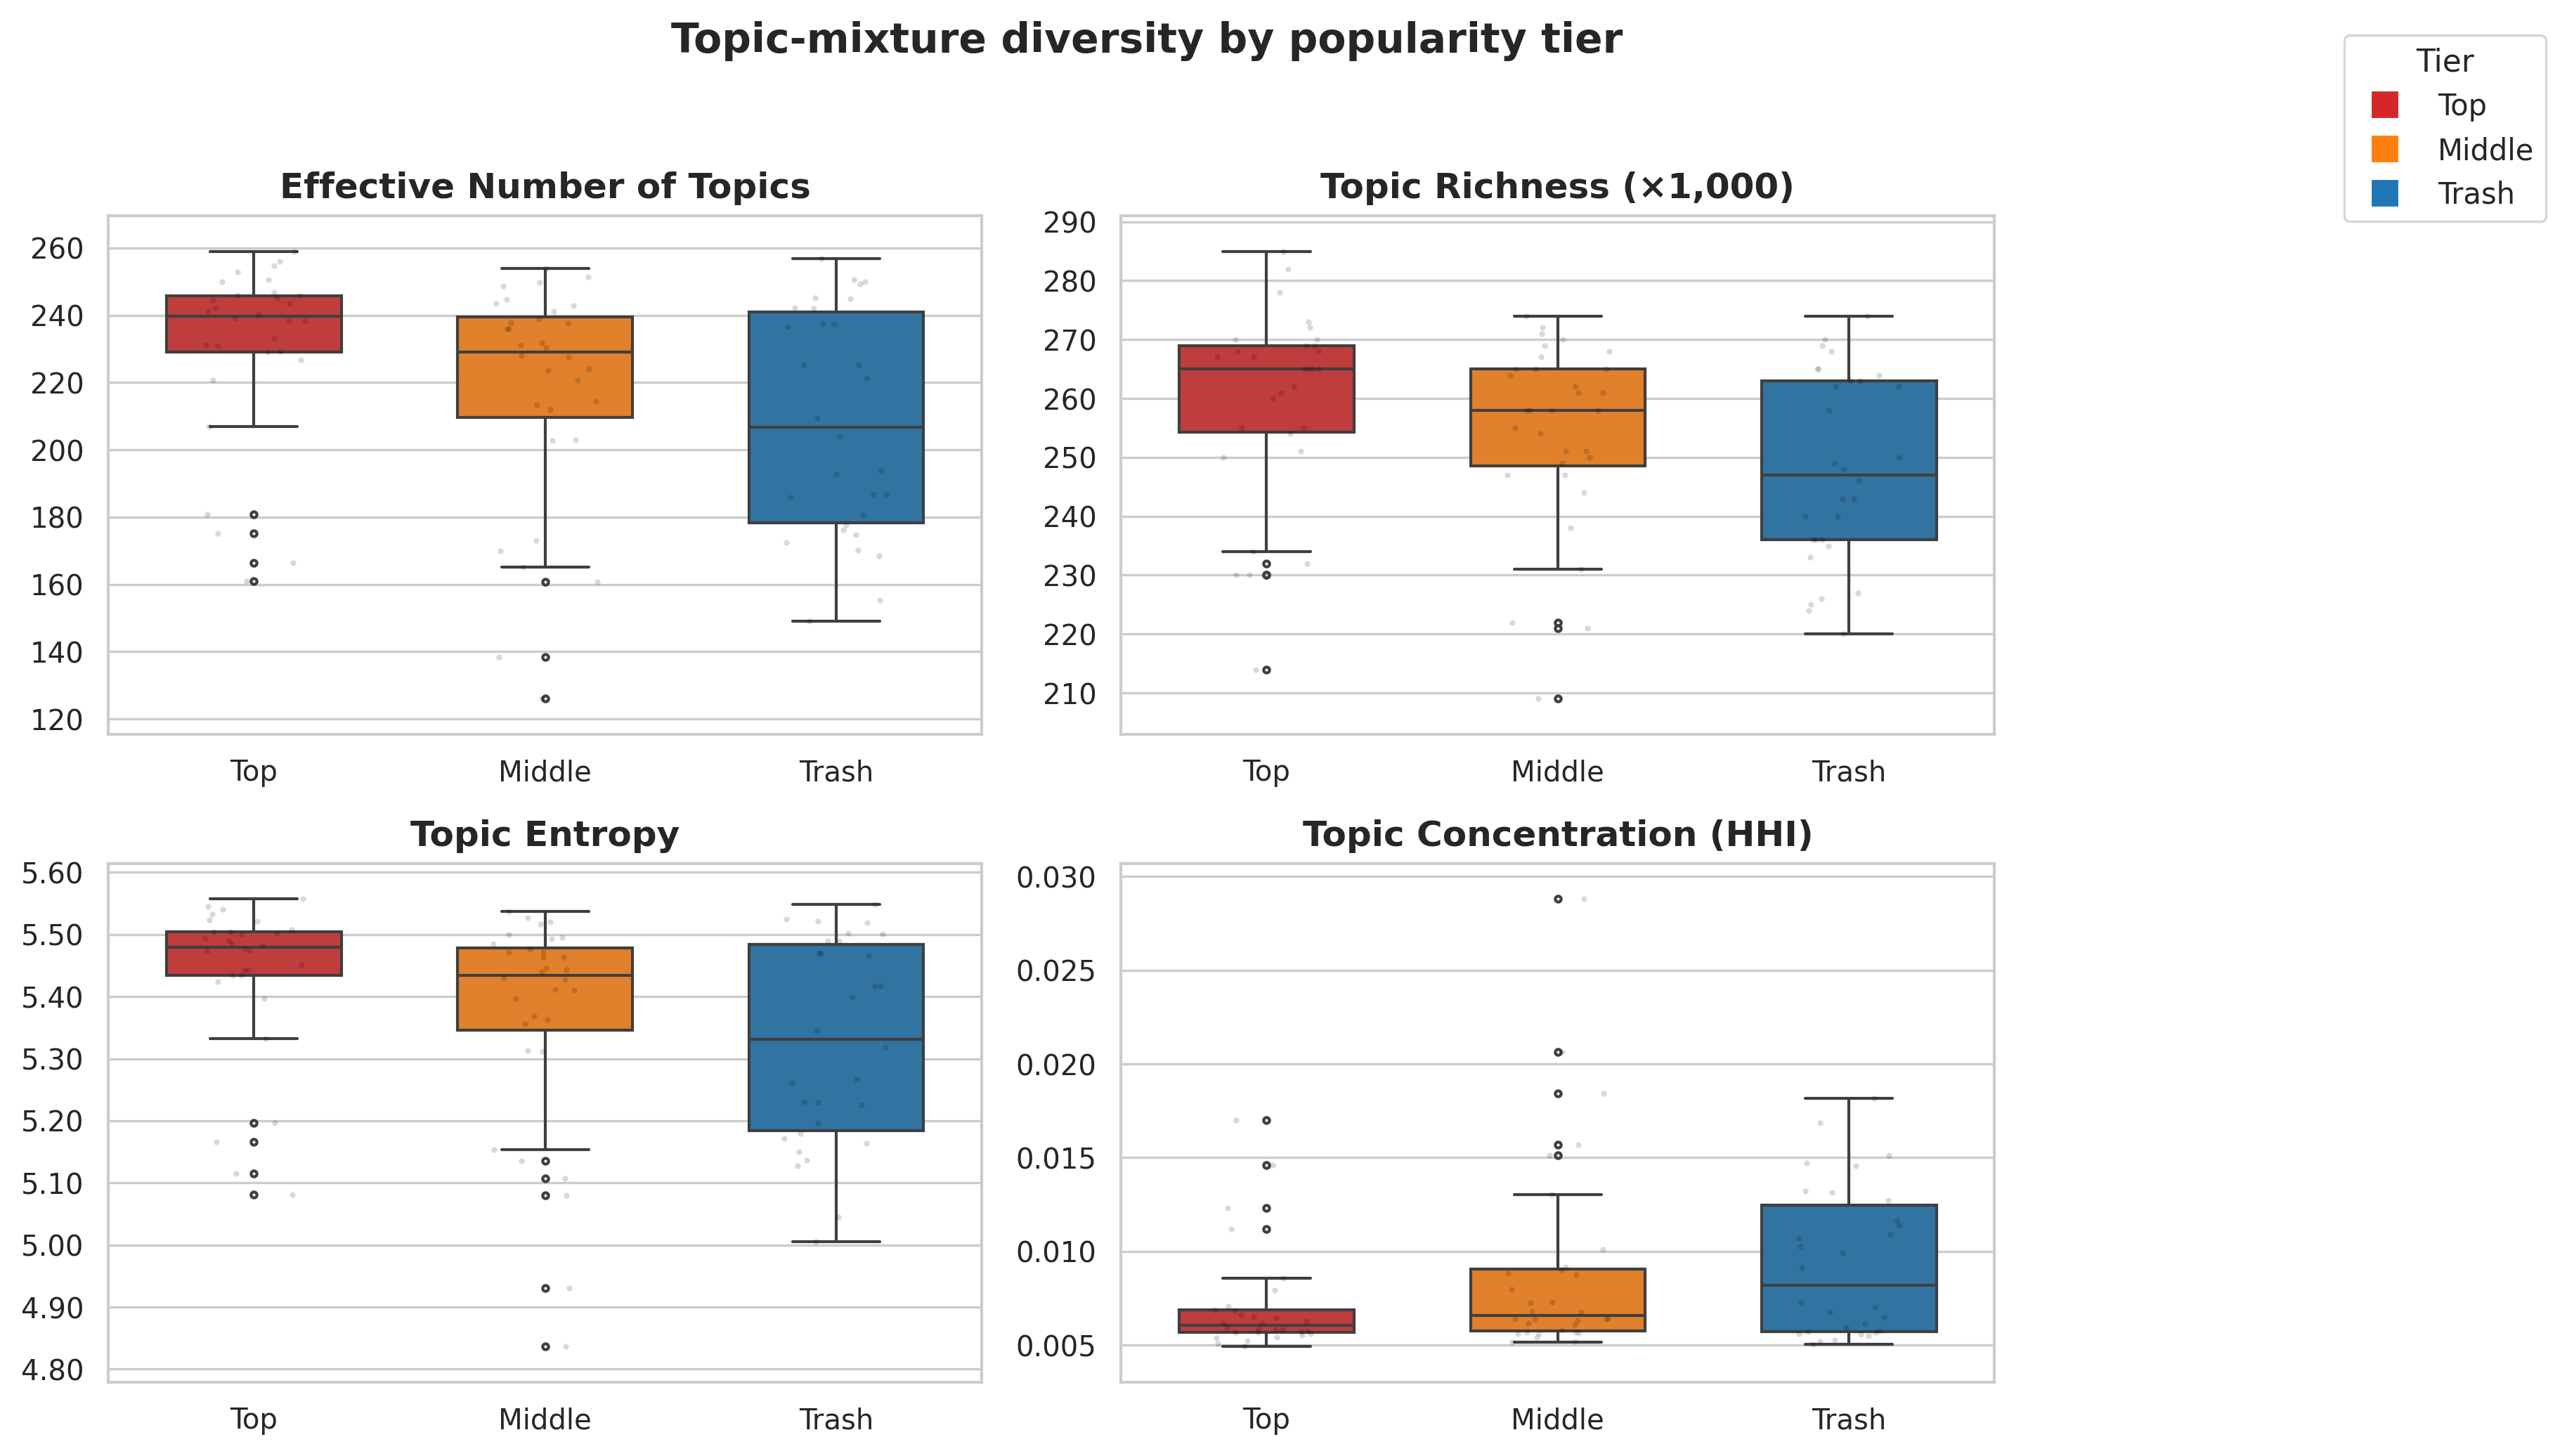

✓ Saved: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/02_taxonomy_group_analysis/figures/diversity_metrics/fig_diversity_by_tier_faceted.png
✓ Saved: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/02_taxonomy_group_analysis/figures/diversity_metrics/fig_diversity_by_tier_faceted.pdf


✓ Saved interactive violin plot (for appendix/interactive use)


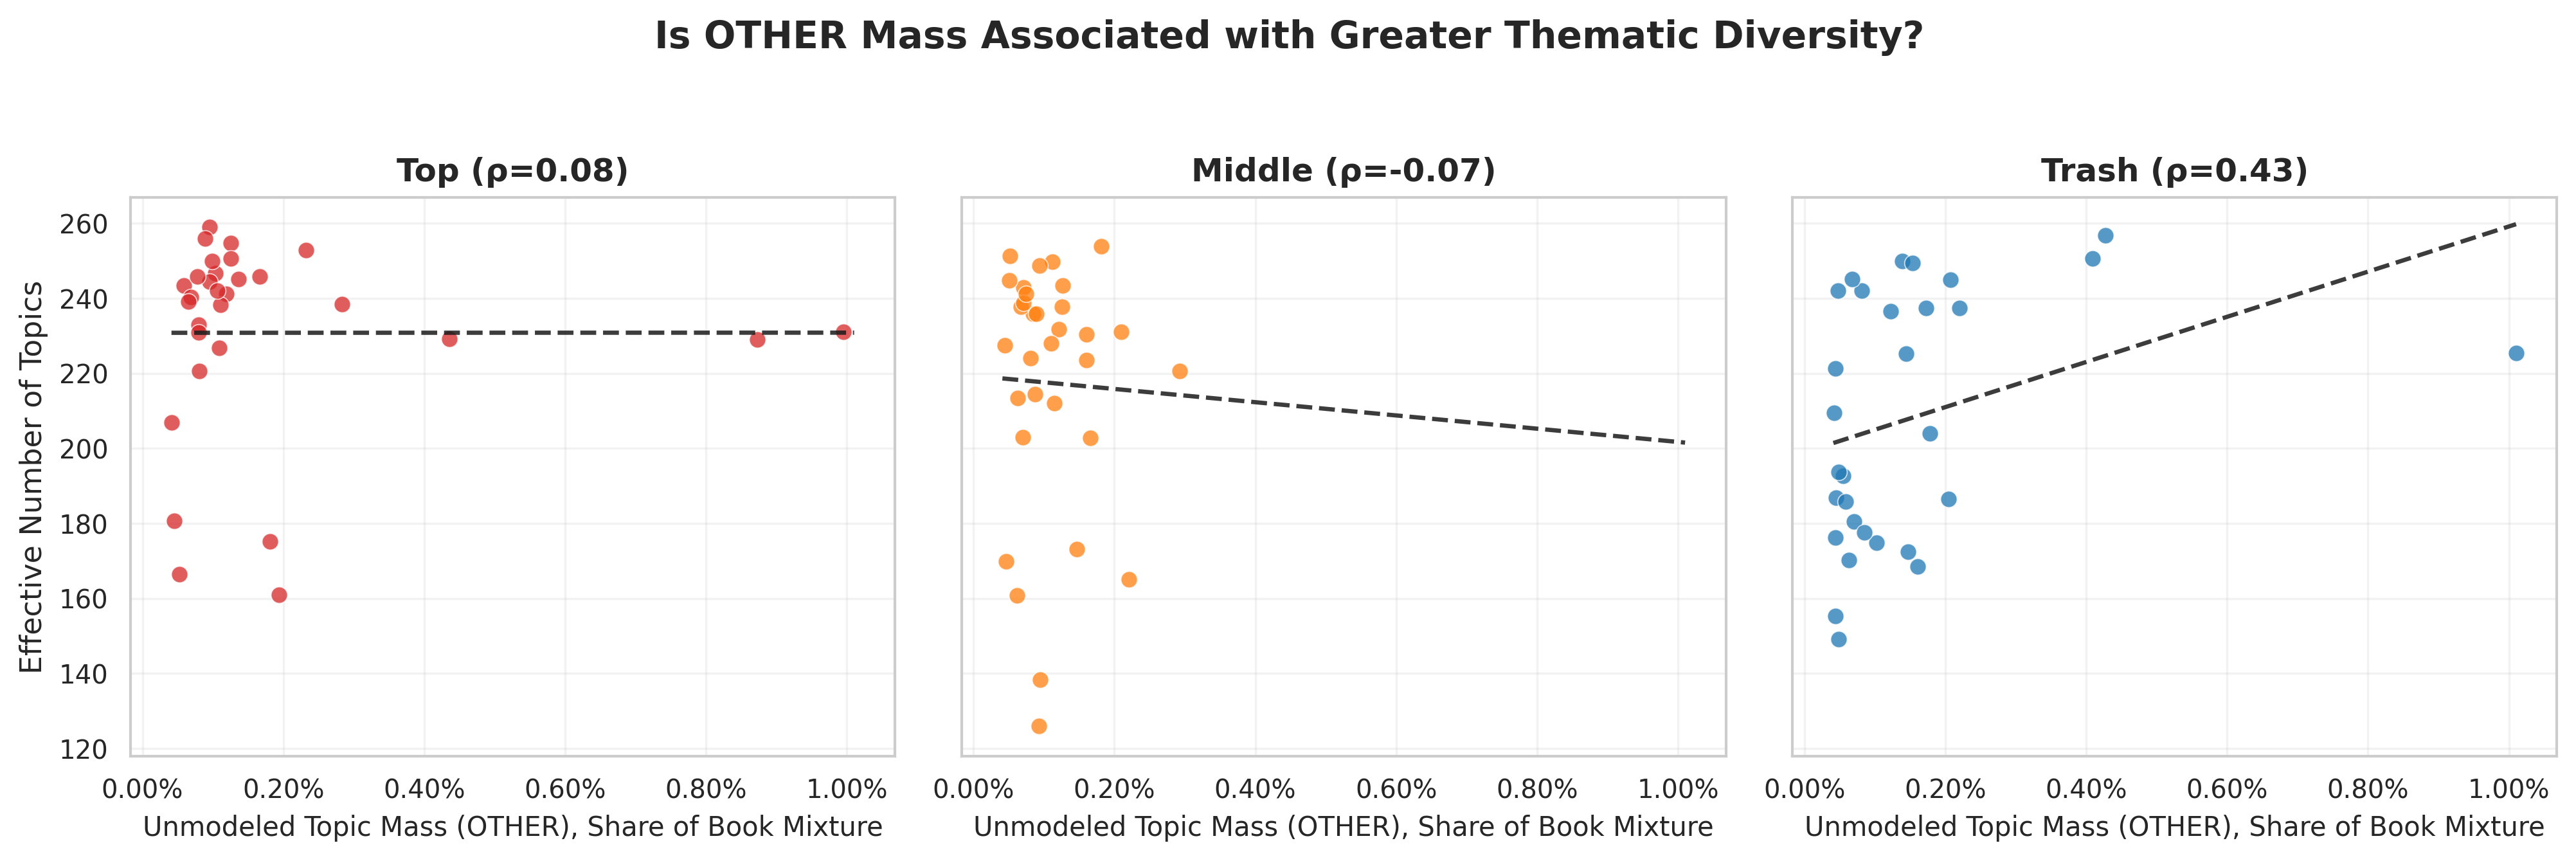

✓ Saved: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/02_taxonomy_group_analysis/figures/diversity_metrics/fig_other_vs_effective_topics_by_tier_faceted.png
✓ Saved: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/02_taxonomy_group_analysis/figures/diversity_metrics/fig_other_vs_effective_topics_by_tier_faceted.pdf

✓ Saved diversity visualizations to: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/02_taxonomy_group_analysis/figures/diversity_metrics


In [81]:
import warnings

# Suppress FutureWarnings and seaborn palette warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=FutureWarning)
    # Create diversity metrics visualizations
    # Try to load div_df from memory or from saved file
    if 'div_df' in locals() and len(div_df) > 0:
        div_df_vis = div_df
    elif 'div_df' in globals() and len(div_df) > 0:
        div_df_vis = div_df
    else:
        # Load from saved file
        div_df_path = TABLE_DIR / "diversity_metrics_by_book.parquet"
        if div_df_path.exists():
            div_df_vis = pd.read_parquet(div_df_path)
            print(f"✓ Loaded div_df from {div_df_path}")
        else:
            div_df_vis = None
            print("⚠️  div_df not available and file not found")

    if div_df_vis is not None and len(div_df_vis) > 0:
        # Ensure rating_tier is properly set
        if 'rating_tier' not in div_df_vis.columns or div_df_vis['rating_tier'].isna().all():
            print("⚠️  rating_tier missing or all NaN in div_df_vis, attempting to fix...")
            # Try to get rating_tier from book_main_group_shares
            if 'book_main_group_shares' in locals() or 'book_main_group_shares' in globals():
                if 'book_main_group_shares' in locals():
                    book_shares = book_main_group_shares
                else:
                    book_shares = globals().get('book_main_group_shares')
                
                if book_shares is not None and 'rating_tier' in book_shares.columns:
                    tier_map = book_shares[['book_id', 'rating_tier']].drop_duplicates()
                    div_df_vis = div_df_vis.merge(tier_map, on='book_id', how='left')
                    print("✓ Added rating_tier from book_main_group_shares")
                elif 'book_meta' in locals() or 'book_meta' in globals():
                    # Fallback to book_meta
                    if 'book_meta' in locals():
                        meta = book_meta
                    else:
                        meta = globals().get('book_meta')
                    
                    if meta is not None:
                        if 'rating_class' in meta.columns:
                            meta_with_tier = meta.copy()
                            meta_with_tier['rating_tier'] = meta_with_tier['rating_class']
                            div_df_vis = div_df_vis.merge(
                                meta_with_tier[['book_id', 'rating_tier']].drop_duplicates(),
                                on='book_id', how='left'
                            )
                            print("✓ Added rating_tier from book_meta['rating_class']")
                        elif 'rating_mean' in meta.columns:
                            def assign_tier(rating):
                                if pd.isna(rating):
                                    return None
                                if rating >= 4.0:
                                    return 'top'
                                elif rating >= 3.8:
                                    return 'middle'
                                else:
                                    return 'trash'
                            meta_with_tier = meta.copy()
                            meta_with_tier['rating_tier'] = meta_with_tier['rating_mean'].apply(assign_tier)
                            div_df_vis = div_df_vis.merge(
                                meta_with_tier[['book_id', 'rating_tier']].drop_duplicates(),
                                on='book_id', how='left'
                            )
                            print("✓ Added rating_tier from book_meta['rating_mean']")
            else:
                print("⚠️  Cannot fix rating_tier: book_main_group_shares and book_meta not available")
        else:
            # Check if rating_tier has valid values
            valid_tiers = div_df_vis['rating_tier'].dropna()
            if len(valid_tiers) == 0:
                print("⚠️  rating_tier column exists but all values are NaN")
            else:
                print(f"✓ rating_tier is set: {valid_tiers.value_counts().to_dict()}")
        
        # Normalize tier names to standard format (good->top, bad->trash, mid->middle)
        if 'rating_tier' in div_df_vis.columns:
            tier_normalization_map = {'good': 'top', 'bad': 'trash', 'mid': 'middle'}
            div_df_vis['rating_tier'] = div_df_vis['rating_tier'].map(
                lambda x: tier_normalization_map.get(x, x) if pd.notna(x) else x
            )
        
        # Final check: verify we have data for plotting
        if 'rating_tier' in div_df_vis.columns:
            tier_counts = div_df_vis['rating_tier'].value_counts()
            print(f"\n✓ Data ready for plotting. Books per tier: {tier_counts.to_dict()}")
            if len(tier_counts) == 0 or tier_counts.sum() == 0:
                print("⚠️  WARNING: No valid tier data found. Plots will be empty.")
        else:
            print("⚠️  WARNING: rating_tier column still missing. Plots will be empty.")
        
        # Create figure directory for diversity plots
        DIVERSITY_FIG_DIR = FIG_DIR / "diversity_metrics"
        DIVERSITY_FIG_DIR.mkdir(parents=True, exist_ok=True)

        # ============================
        # Figure 1 (Publication): Diversity metrics by tier (faceted)
        # ============================
        # 1) Choose which metrics are "main figure"
        # Recommendation: keep Effective Topics + Richness; move Entropy/HHI to appendix (redundant / technical)
        MAIN_METRICS = [
            ("effective_topics", "Effective Number of Topics"),
            ("richness_1e3", "Topic Richness (×1,000)"),
            ("entropy", "Topic Entropy"),
            ("hhi", "Topic Concentration (HHI)"),
        ]
        # If you truly want to avoid scaling confusion, DO NOT multiply entropy/hhi by 10 here.
        # If tiny values make HHI unreadable, prefer scientific notation formatting instead of arbitrary ×10.
        div_plot = div_df_vis.copy()
        div_plot = ensure_tier_display(div_plot, raw_col="rating_tier", out_col="Tier")
        # 2) Build a long dataframe for plotting
        rows = []
        for col, nice in MAIN_METRICS:
            if col not in div_plot.columns:
                continue
            s = div_plot[[ "Tier", col ]].dropna()
            s = s.rename(columns={col: "Value"})
            s["Metric"] = nice
            s["MetricKey"] = col
            rows.append(s)
        plot_long = pd.concat(rows, ignore_index=True)
        # 3) Fixed tier ordering
        plot_long["Tier"] = pd.Categorical(plot_long["Tier"], categories=TIER_ORDER_DISPLAY, ordered=True)
        # 4) Faceted 2×2 plot (same scale within each metric)
        fig, axes = plt.subplots(2, 2, figsize=(11, 7))
        axes = axes.flatten()
        for ax, (col, nice) in zip(axes, MAIN_METRICS):
            sub = plot_long[plot_long["MetricKey"] == col]
            if sub.empty:
                ax.axis("off")
                continue
            y_min, y_max = float(sub["Value"].min()), float(sub["Value"].max())
            pad = 0.08 * (y_max - y_min + 1e-9)
            ax.set_ylim(y_min - pad, y_max + pad)
            sns.boxplot(
                data=sub,
                x="Tier", y="Value",
                order=TIER_ORDER_DISPLAY,
                palette=TIER_COLORS_DISPLAY,
                fliersize=2,
                width=0.6,
                ax=ax
            )
            sns.stripplot(
                data=sub,
                x="Tier", y="Value",
                order=TIER_ORDER_DISPLAY,
                color="black",
                alpha=0.15,
                size=2.0,
                jitter=0.18,
                ax=ax
            )
            ax.set_title(nice, fontsize=12, fontweight="bold")
            ax.set_xlabel("")
            ax.set_ylabel("")
            # Metric-specific tick formatting (deliberate, not accidental)
            if col == "effective_topics":
                ax.yaxis.set_major_locator(mpl.ticker.MaxNLocator(integer=True))
            elif col == "richness_1e3":
                ax.yaxis.set_major_locator(mpl.ticker.MaxNLocator(integer=True))
            elif col == "entropy":
                ax.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter("%.2f"))
            elif col == "hhi":
                ax.ticklabel_format(axis="y", style="sci", scilimits=(-3, 3))
        fig.suptitle("Topic-mixture diversity by popularity tier", fontsize=14, fontweight="bold", y=0.98)

        # Put legend outside (no overlap)
        handles = [mpl.lines.Line2D([0],[0], marker='s', color='w',
                                   markerfacecolor=TIER_COLORS_DISPLAY[t], markersize=10)
                   for t in TIER_ORDER_DISPLAY]
        fig.legend(handles, TIER_ORDER_DISPLAY, title="Tier", loc="upper left", bbox_to_anchor=(1.01, 0.98))

        # Save as vector for publication
        out_png = DIVERSITY_FIG_DIR / "fig_diversity_by_tier_faceted.png"
        out_pdf = DIVERSITY_FIG_DIR / "fig_diversity_by_tier_faceted.pdf"
        plt.tight_layout(rect=[0, 0, 0.88, 0.95])  # reserve right side + top space
        plt.savefig(out_png, dpi=600, bbox_inches="tight")
        plt.savefig(out_pdf, bbox_inches="tight")
        plt.show()
        print(f"✓ Saved: {out_png}")
        print(f"✓ Saved: {out_pdf}")

        # --- 2. Interactive Violin Plot (Appendix/Interactive Supplement) ---
        # NOTE: This figure mixes different metrics with different units on a single y-axis.
        # For publication, use the faceted Figure 1 above instead. This interactive version
        # is suitable for appendix or interactive exploration only.
        try:
            import plotly.express as px
            # Rebuild compact_df for violin plot (if needed)
            if 'div_plot' in locals() and len(div_plot) > 0:
                compact_df_violin = []
                for col, nice in MAIN_METRICS:
                    if col not in div_plot.columns:
                        continue
                    for tier in TIER_ORDER_DISPLAY:
                        vals = div_plot[div_plot["Tier"] == tier][col].dropna()
                        compact_df_violin.extend([{
                            'Tier': tier,
                            'Metric': nice,
                            'Value': v
                        } for v in vals])
                compact_df_violin = pd.DataFrame(compact_df_violin)
            else:
                compact_df_violin = pd.DataFrame()
            
            if not compact_df_violin.empty:
                fig_violin = px.violin(
                    compact_df_violin,
                    x="Metric",
                    y="Value",
                    color="Tier",
                    color_discrete_map=TIER_COLORS_DISPLAY,
                    box=True,
                    points='all',
                )
                fig_violin.update_layout(
                    height=500,
                    width=850,
                    title="Diversity Metrics by Tier (Appendix/Interactive - rescaled for visibility)",
                    xaxis_tickangle=-30
                )
                fig_violin.write_html(str(DIVERSITY_FIG_DIR / "diversity_metrics_violin.html"))
                fig_violin.show()
                print("✓ Saved interactive violin plot (for appendix/interactive use)")
        except ImportError:
            pass

        # ============================
        # Figure 2 (Publication): OTHER vs Effective Topics, consistent axes
        # ============================
        if 'other_share' in div_df_vis.columns and 'effective_topics' in div_df_vis.columns:
            from scipy.stats import spearmanr
            corr_df = div_df_vis.copy()
            corr_df = ensure_tier_display(corr_df, raw_col="rating_tier", out_col="Tier")
            corr_df = corr_df.dropna(subset=["other_share", "effective_topics"])
            # Fixed axis limits across panels (critical for honest comparison)
            x_min, x_max = float(corr_df["other_share"].min()), float(corr_df["other_share"].max())
            y_min, y_max = float(corr_df["effective_topics"].min()), float(corr_df["effective_topics"].max())
            x_pad = 0.06 * (x_max - x_min + 1e-9)
            y_pad = 0.06 * (y_max - y_min + 1e-9)
            fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2), sharex=True, sharey=True)
            for ax, tier in zip(axes, TIER_ORDER_DISPLAY):
                sub = corr_df[corr_df["Tier"] == tier]
                c = TIER_COLORS_DISPLAY[tier]
                ax.scatter(sub["other_share"], sub["effective_topics"], s=38, alpha=0.75, color=c, edgecolor="white", linewidth=0.4)
                # Spearman rho (keep it minimal; move p-values to caption/table)
                rho, pval = spearmanr(sub["other_share"], sub["effective_topics"])
                ax.set_title(f"{tier} (ρ={rho:.2f})", fontsize=12, fontweight="bold")
                # Trend line (simple, consistent)
                if len(sub) >= 2:
                    z = np.polyfit(sub["other_share"], sub["effective_topics"], 1)
                    p = np.poly1d(z)
                    xs = np.linspace(x_min, x_max, 100)
                    ax.plot(xs, p(xs), "k--", linewidth=1.6, alpha=0.85)
                ax.set_xlim(x_min - x_pad, x_max + x_pad)
                ax.set_ylim(y_min - y_pad, y_max + y_pad)
                ax.grid(alpha=0.25)
            # Labels once (global)
            axes[0].set_ylabel("Effective Number of Topics", fontsize=11)
            for ax in axes:
                ax.set_xlabel("Unmodeled Topic Mass (OTHER), Share of Book Mixture", fontsize=10)
                ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
            fig.suptitle("Is OTHER Mass Associated with Greater Thematic Diversity?", fontsize=14, fontweight="bold", y=1.05)
            plt.tight_layout()
            out_png = DIVERSITY_FIG_DIR / "fig_other_vs_effective_topics_by_tier_faceted.png"
            out_pdf = DIVERSITY_FIG_DIR / "fig_other_vs_effective_topics_by_tier_faceted.pdf"
            plt.savefig(out_png, dpi=600, bbox_inches="tight")
            plt.savefig(out_pdf, bbox_inches="tight")
            plt.show()
            print(f"✓ Saved: {out_png}")
            print(f"✓ Saved: {out_pdf}")

        print(f"\n✓ Saved diversity visualizations to: {DIVERSITY_FIG_DIR}")
    else:
        print("⚠️  div_df not available for visualization")

In [82]:
print("=" * 80)
print("Coverage audit by tier:")
print("=" * 80)

audit = book_main_group_shares[['book_id','rating_tier','other_share','paratext_share','noise_share','unmapped_share','modeled_mass']].drop_duplicates()

coverage_summary = audit.groupby('rating_tier')[['other_share','paratext_share','noise_share','unmapped_share','modeled_mass']].agg(['mean','median']).round(4)
display(coverage_summary)

# Save
coverage_summary.to_csv(TABLE_DIR / "coverage_audit_by_tier.csv")
coverage_summary.to_csv(TABLE_DIR / "coverage_audit_by_tier.csv", index=False)
print(f"\n✓ Saved coverage audit to: {TABLE_DIR / 'coverage_audit_by_tier.csv'}")

Coverage audit by tier:


other_share         paratext_share         noise_share          \
                   mean  median           mean  median        mean  median   
rating_tier                                                                  
bad              0.0015  0.0009         0.0019  0.0018      0.0010  0.0007   
good             0.0018  0.0010         0.0024  0.0016      0.0010  0.0008   
mid              0.0011  0.0009         0.0016  0.0015      0.0009  0.0007   

            unmapped_share         modeled_mass          
                      mean  median         mean  median  
rating_tier                                              
bad                 0.0005  0.0001       0.9981  0.9982  
good                0.0008  0.0001       0.9976  0.9984  
mid                 0.0002  0.0001       0.9984  0.9985


✓ Saved coverage audit to: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/02_taxonomy_group_analysis/tables_csv/coverage_audit_by_tier.csv


## 7.6 Coverage Audit Visualization

Create visualizations showing coverage components (OTHER, paratext, noise, modeled mass) by tier.


✓ Normalized tier index: ['trash', 'top', 'middle']
✓ coverage_means index: ['trash', 'top', 'middle']
✓ coverage_means columns: ['other_share', 'paratext_share', 'noise_share', 'unmapped_share', 'modeled_mass']
✓ Expected tiers: ['top', 'middle', 'trash']
✓ Coverage validation: max deviation from 1.0 = 0.003600
✓ Prepared 6 data points for major components
✓ Prepared 9 data points for minor components


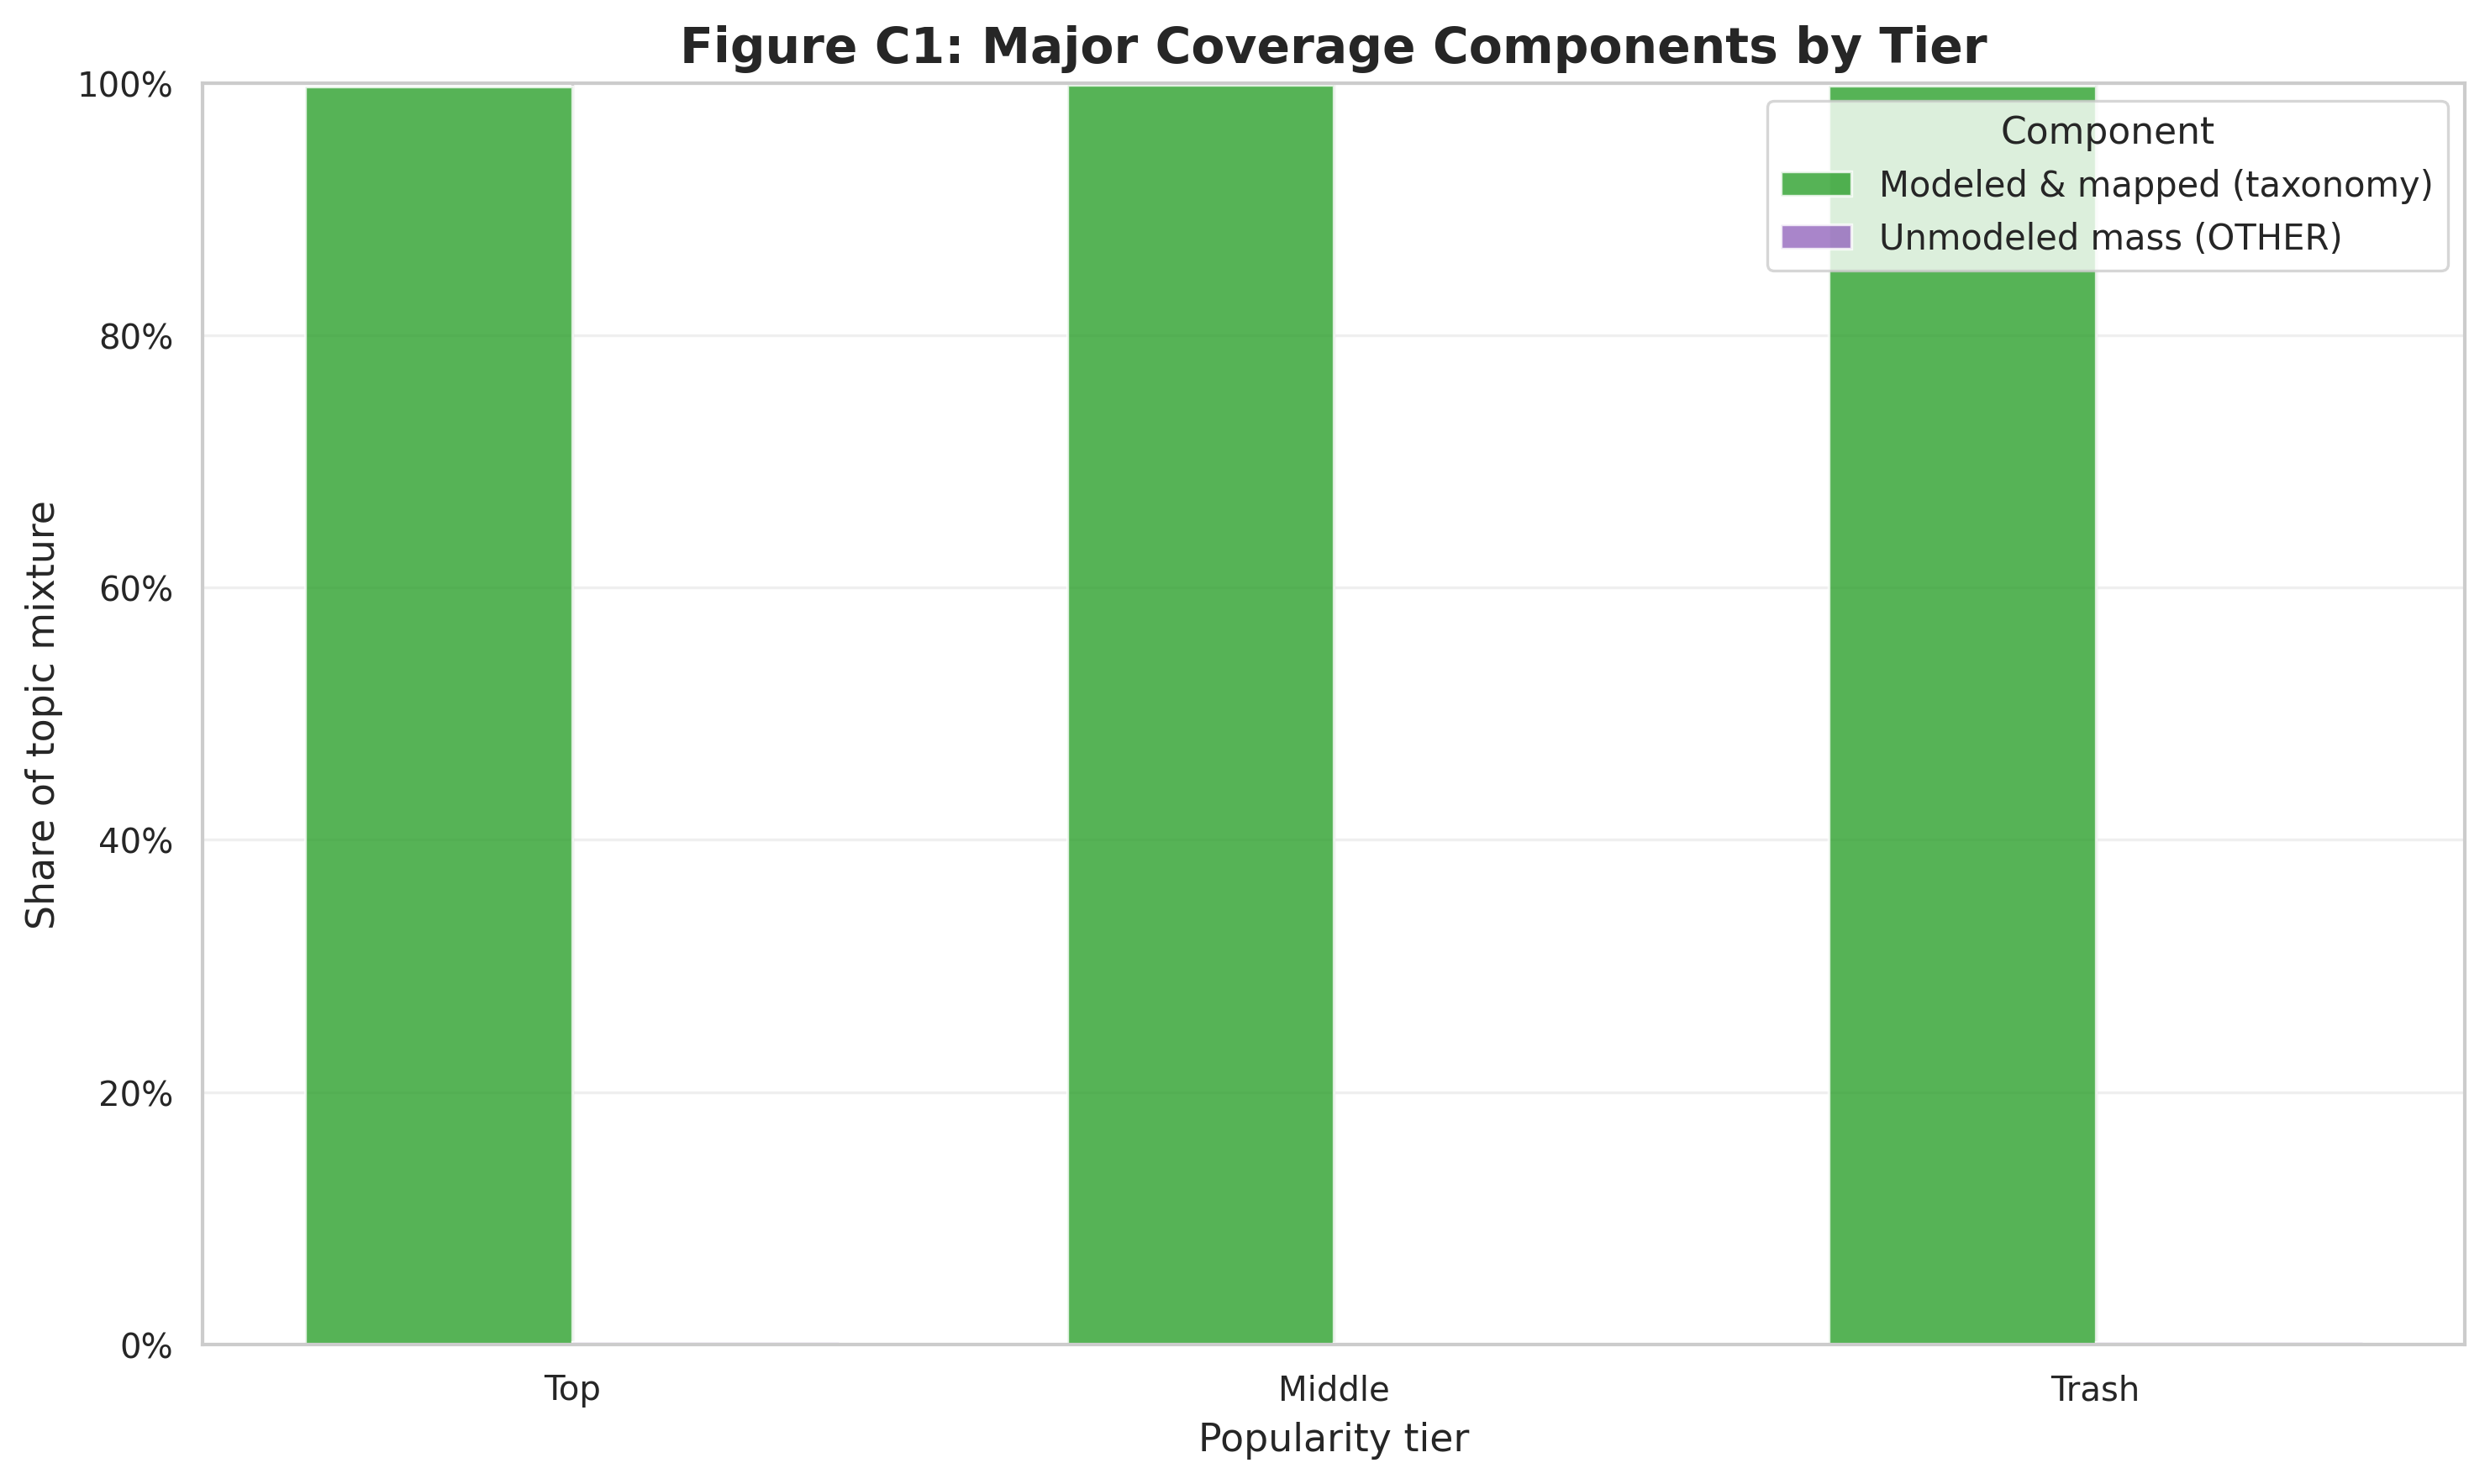

✓ Saved: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/02_taxonomy_group_analysis/figures/coverage_audit/fig_coverage_major_components.png


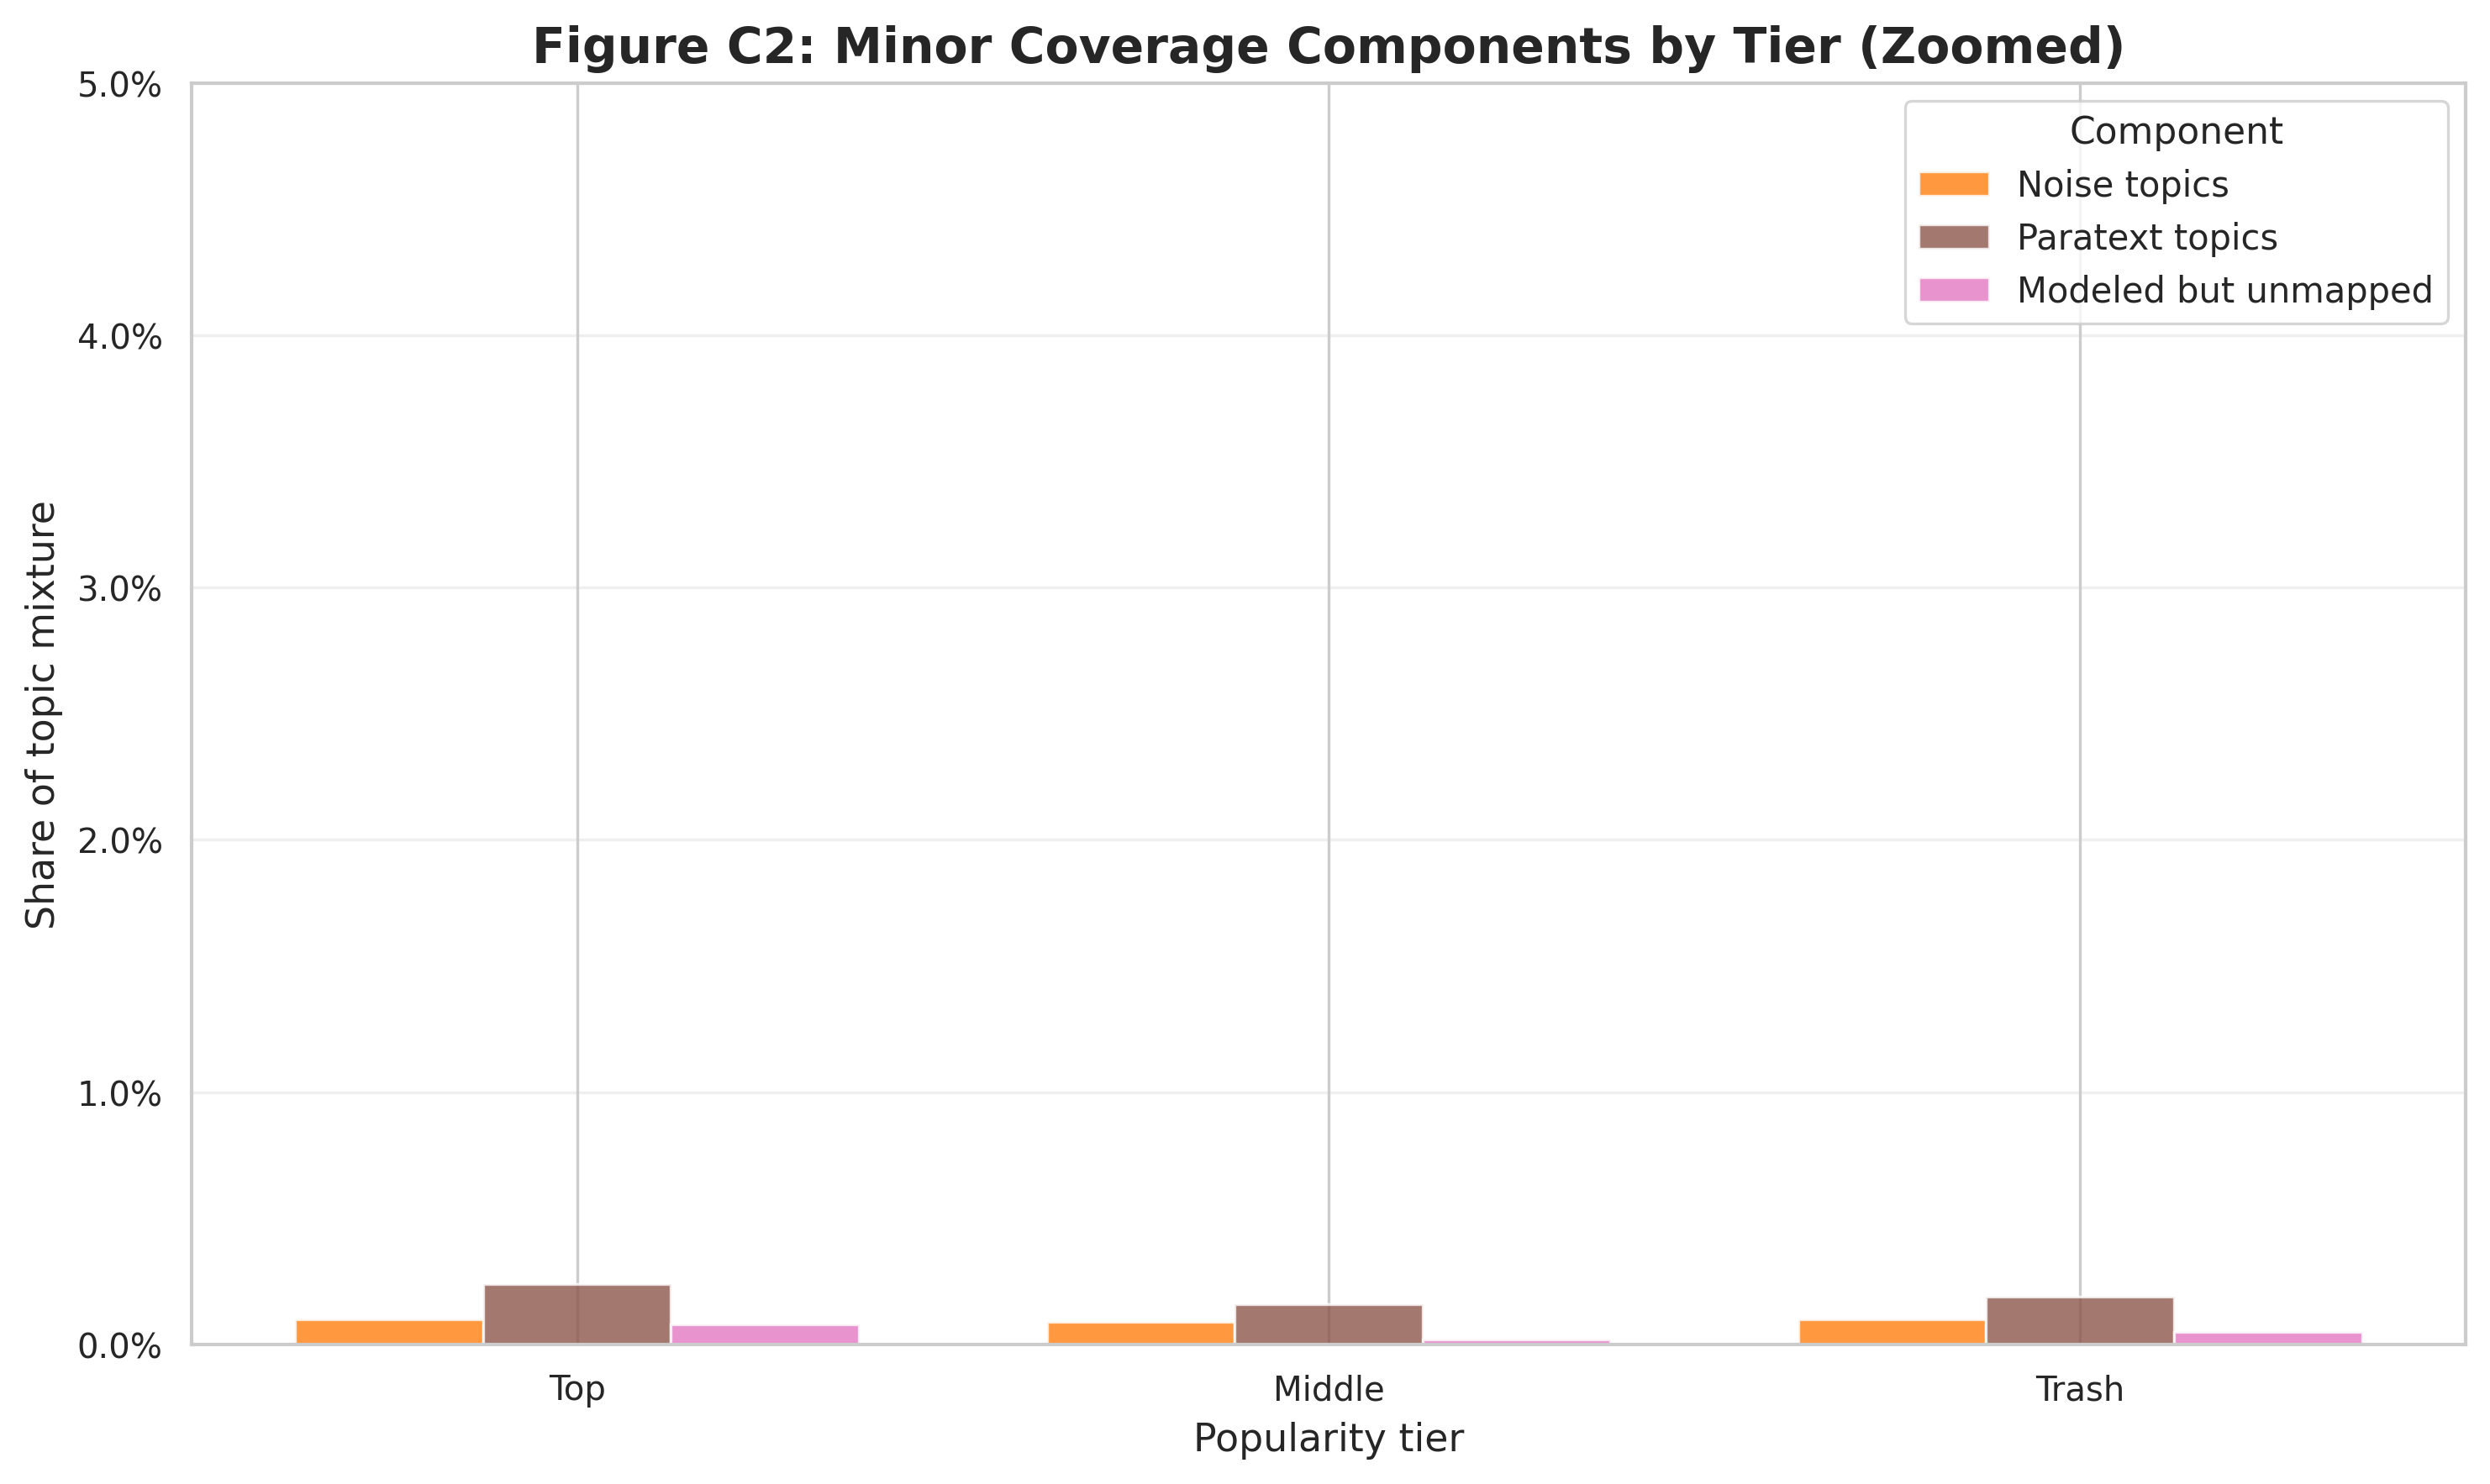

✓ Saved: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/02_taxonomy_group_analysis/figures/coverage_audit/fig_coverage_minor_components.png
  (Y-axis zoomed to 0-5.0% due to much smaller magnitude than major components)


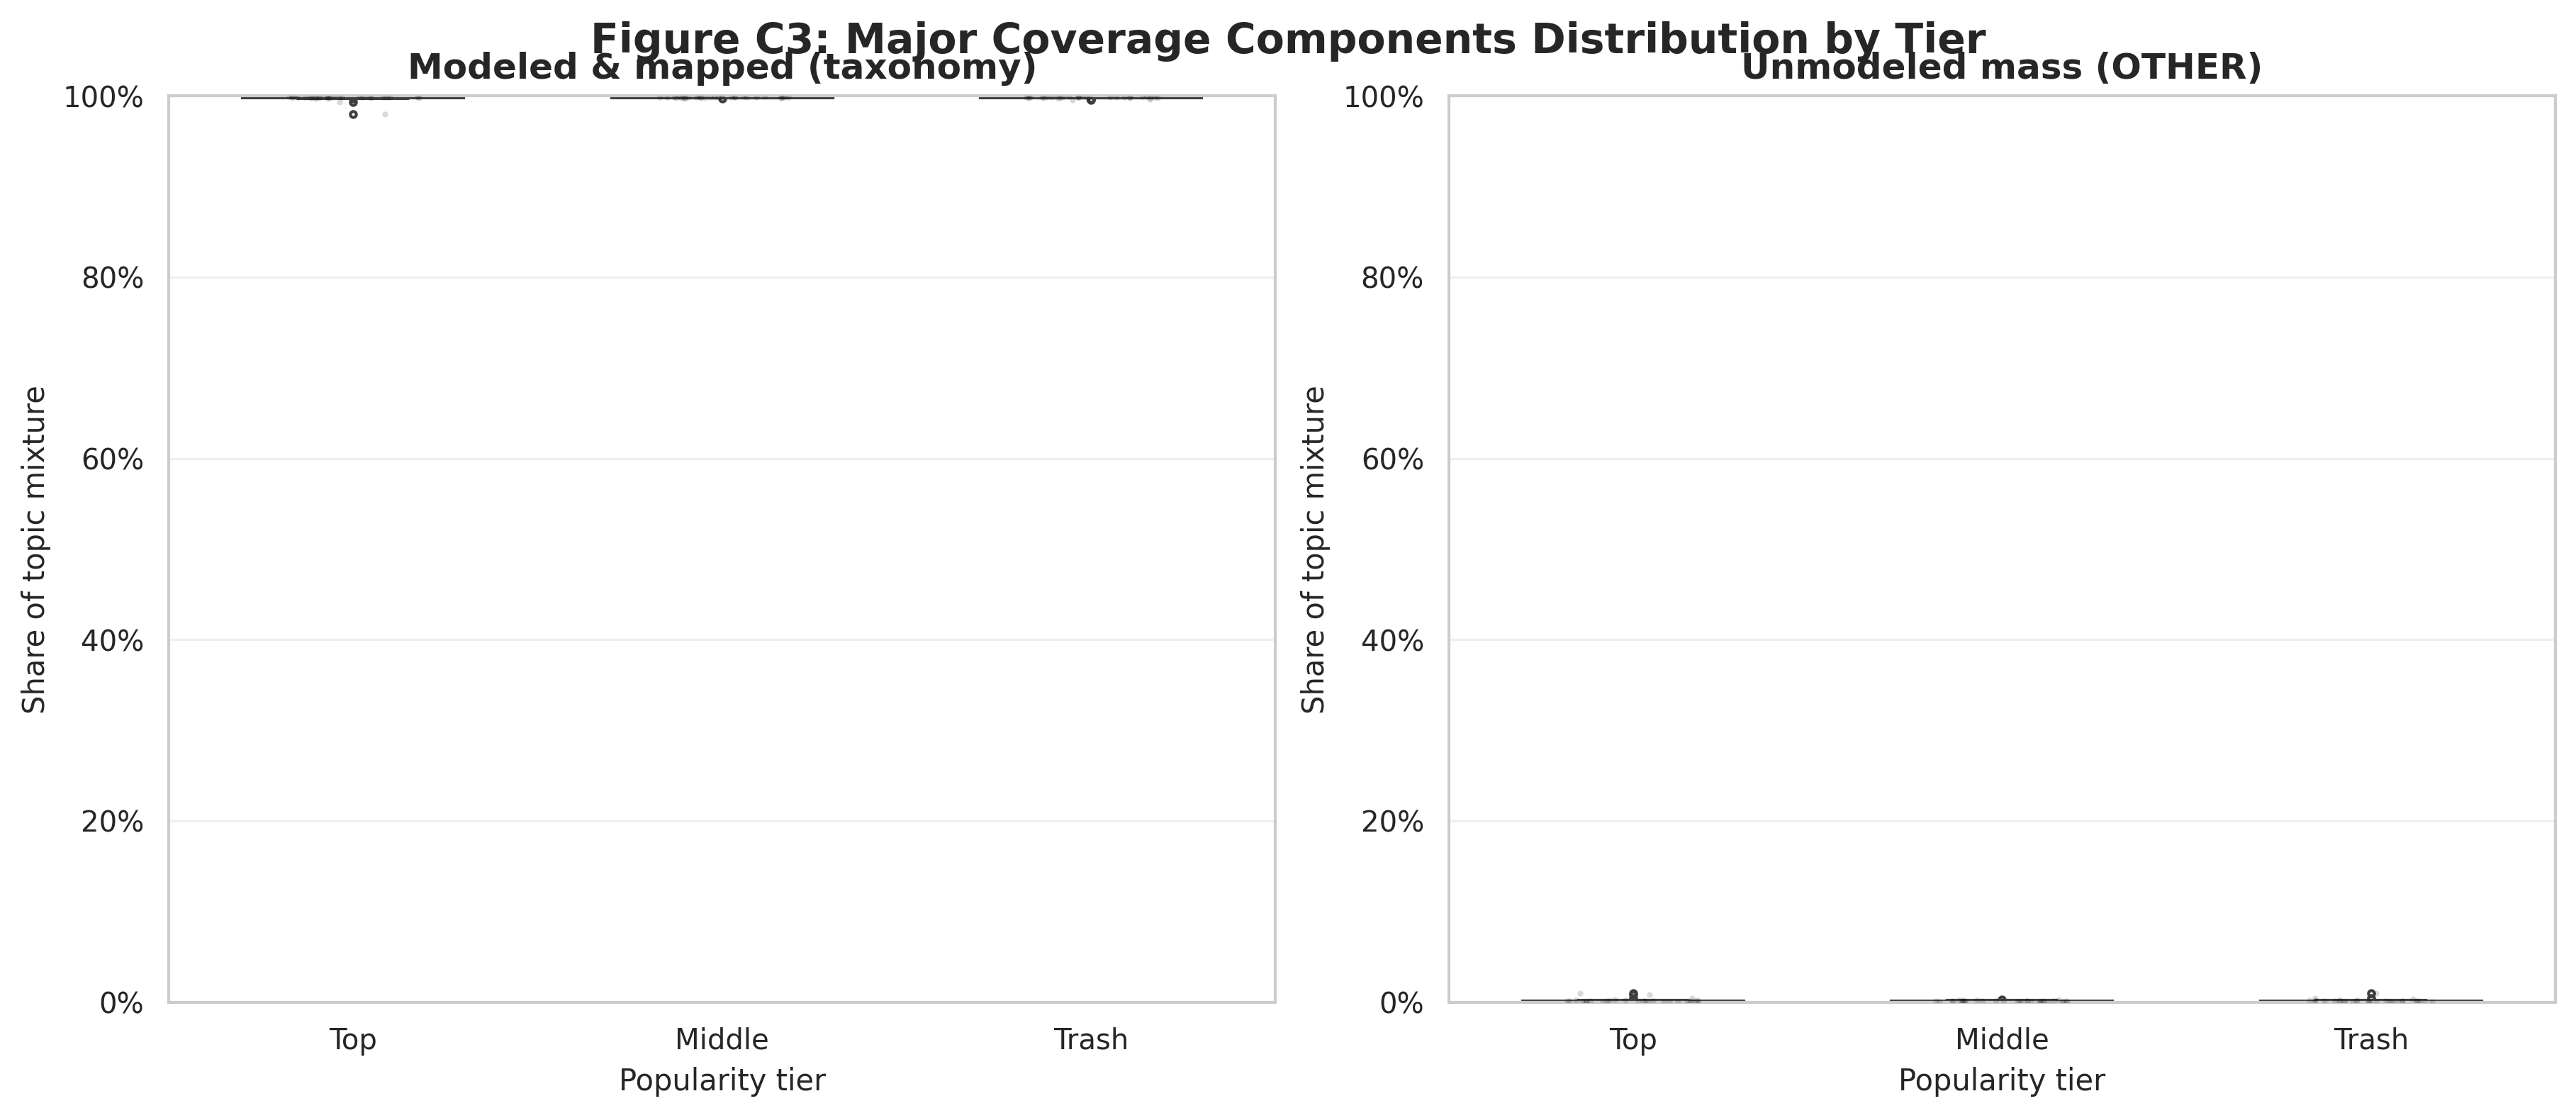

✓ Saved: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/02_taxonomy_group_analysis/figures/coverage_audit/fig_coverage_major_boxplots.png


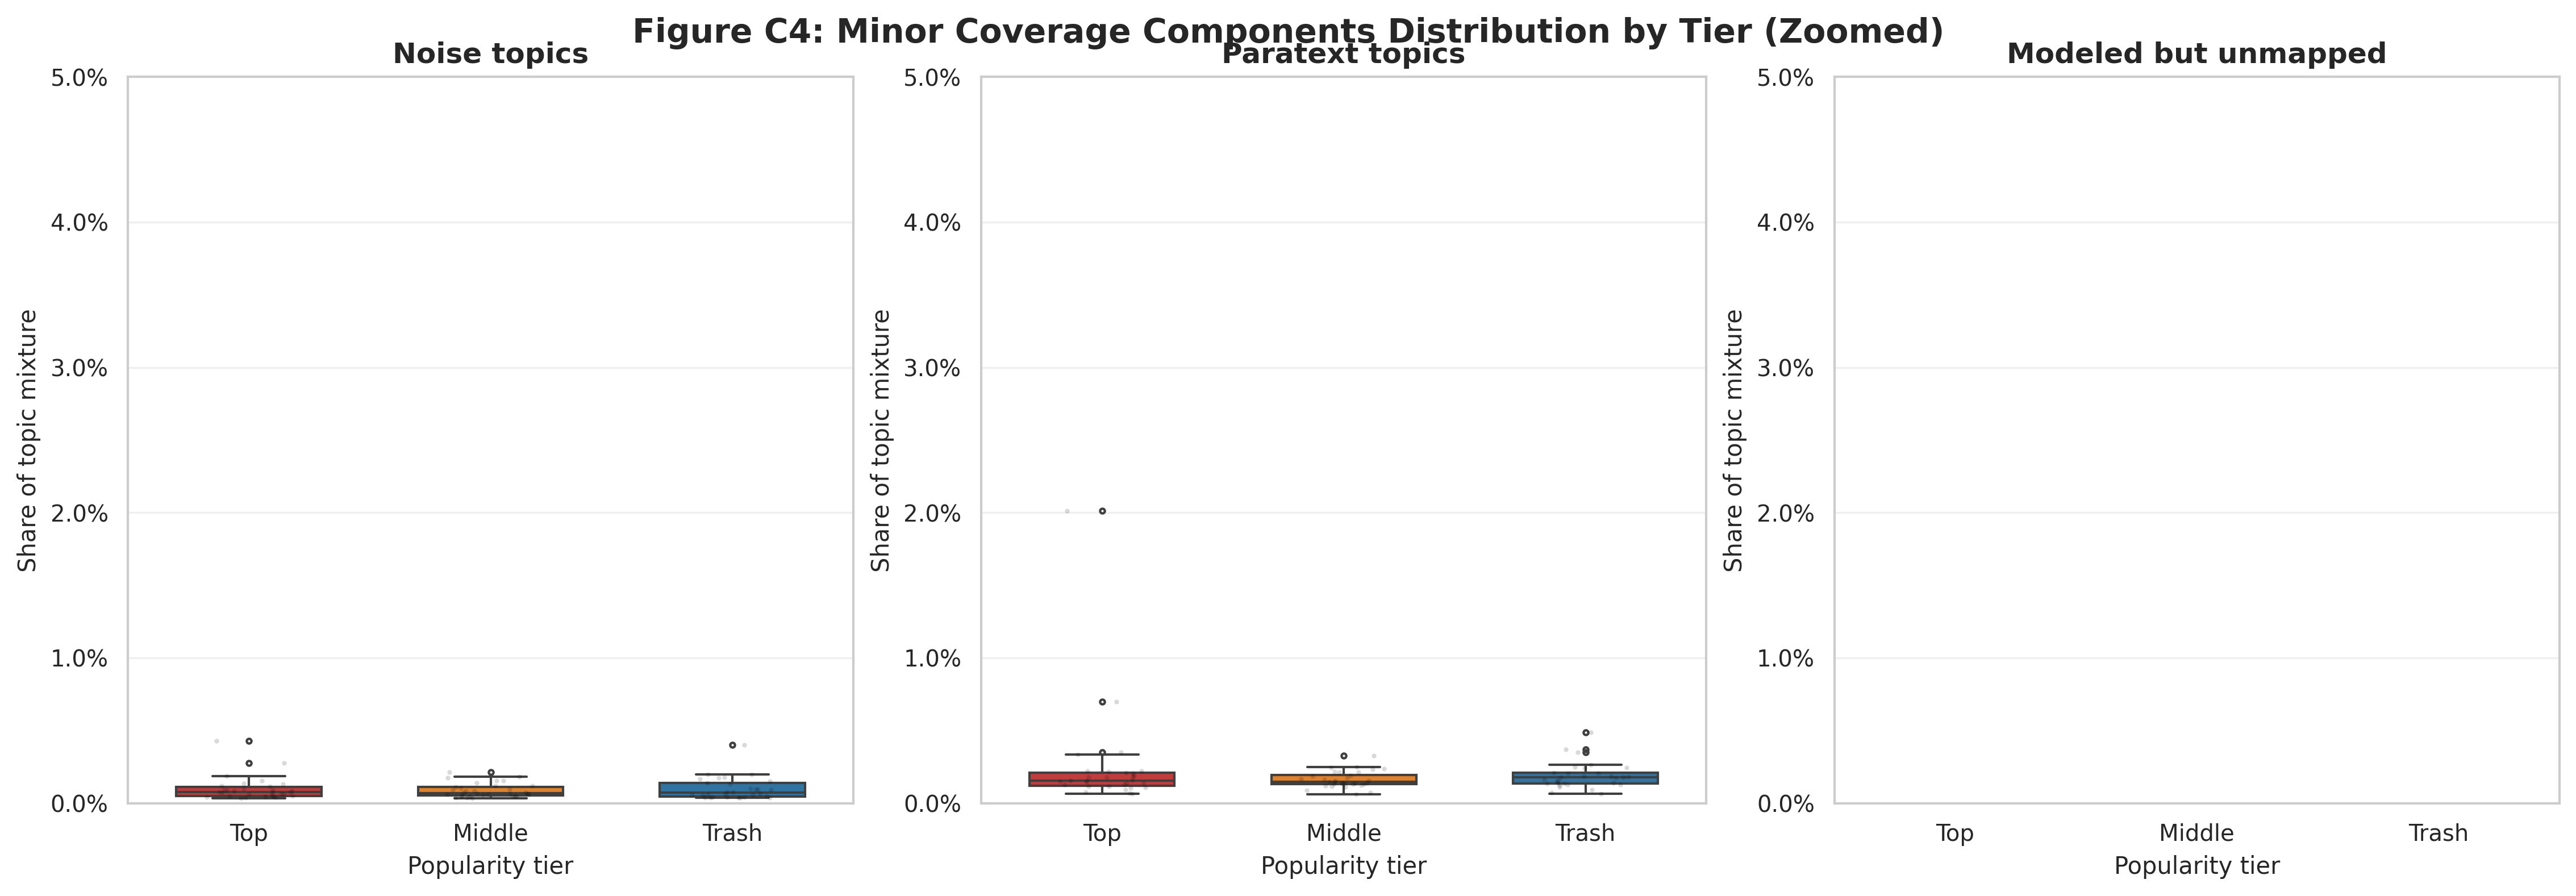

✓ Saved: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/02_taxonomy_group_analysis/figures/coverage_audit/fig_coverage_minor_boxplots.png
  (Y-axes zoomed due to much smaller magnitude than major components)

✓ Saved coverage visualizations to: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/02_taxonomy_group_analysis/figures/coverage_audit


In [83]:
import warnings

# Suppress warnings globally within this cell
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    
    # Create coverage audit visualizations
    # Try to load coverage_summary from memory or reconstruct from saved file
    if 'coverage_summary' in locals() and len(coverage_summary) > 0:
        coverage_summary_vis = coverage_summary
    elif 'coverage_summary' in globals() and len(coverage_summary) > 0:
        coverage_summary_vis = coverage_summary
    else:
        # Try to load from saved file
        coverage_summary_path = TABLE_DIR / "coverage_audit_by_tier.parquet"
        if coverage_summary_path.exists():
            coverage_summary_vis = pd.read_parquet(coverage_summary_path)
            print(f"✓ Loaded coverage_summary from {coverage_summary_path}")
        else:
            # Try to load from diversity_metrics_by_book (guaranteed to have coverage components)
            div_metrics_path = TABLE_DIR / "diversity_metrics_by_book.parquet"
            if div_metrics_path.exists():
                audit = pd.read_parquet(div_metrics_path)
                # Normalize tier names: good->top, bad->trash, mid->middle
                tier_normalization_map = {'good': 'top', 'bad': 'trash', 'mid': 'middle'}
                if 'rating_tier' in audit.columns:
                    audit['rating_tier'] = audit['rating_tier'].map(tier_normalization_map).fillna(audit['rating_tier'])
                audit = ensure_tier_display(audit, raw_col="rating_tier", out_col="Tier")
                # Build component list from columns that actually exist
                candidate_components = ["other_share", "paratext_share", "noise_share", "modeled_mass"]
                components = [c for c in candidate_components if c in audit.columns]
                # If you still want "unmapped_share", compute it ONLY if the ingredients exist:
                if all(c in audit.columns for c in ["other_share","paratext_share","noise_share","modeled_mass"]):
                    audit["unmapped_share"] = 1.0 - (audit["other_share"] + audit["paratext_share"] + audit["noise_share"] + audit["modeled_mass"])
                    components.append("unmapped_share")
                coverage_summary_vis = audit.groupby('rating_tier')[components].agg(['mean', 'median']).round(4)
                print(f"✓ Loaded coverage components from {div_metrics_path}")
            else:
                coverage_summary_vis = None
                print("⚠️  coverage_summary not available and files not found")

    if coverage_summary_vis is not None and len(coverage_summary_vis) > 0:
        # Create figure directory for coverage plots
        COVERAGE_FIG_DIR = FIG_DIR / "coverage_audit"
        COVERAGE_FIG_DIR.mkdir(parents=True, exist_ok=True)
        
        # Normalize tier index: good->top, bad->trash, mid->middle (if index contains tier names)
        tier_normalization_map = {'good': 'top', 'bad': 'trash', 'mid': 'middle'}
        if hasattr(coverage_summary_vis.index, 'map'):
            # Check if index values need normalization
            index_values = coverage_summary_vis.index.tolist()
            if any(tier in index_values for tier in tier_normalization_map.keys()):
                coverage_summary_vis.index = coverage_summary_vis.index.map(
                    lambda x: tier_normalization_map.get(x, x) if isinstance(x, str) else x
                )
                print(f"✓ Normalized tier index: {coverage_summary_vis.index.tolist()}")
        
        # A) Normalize coverage_summary_vis: handle MultiIndex columns robustly
        if isinstance(coverage_summary_vis.columns, pd.MultiIndex):
            # Extract mean level using xs (stable, pandas-supported)
            coverage_means = coverage_summary_vis.xs('mean', level=1, axis=1)
        else:
            # Already flat, use as-is
            coverage_means = coverage_summary_vis.copy()
        
        # Debug: print index and columns to verify data structure
        print(f"✓ coverage_means index: {coverage_means.index.tolist()}")
        print(f"✓ coverage_means columns: {coverage_means.columns.tolist()}")
        print(f"✓ Expected tiers: {TIER_ORDER_RAW}")
        
        # B) Ensure all coverage components exist and compute unmapped_share if missing
        required_components = ['other_share', 'modeled_mass', 'noise_share', 'paratext_share']
        if 'unmapped_share' not in coverage_means.columns:
            # Compute unmapped_share: 1 - (modeled_mass + other_share + noise_share + paratext_share)
            coverage_means['unmapped_share'] = (
                1.0 - coverage_means[required_components].sum(axis=1)
            ).clip(lower=0.0)  # Clip tiny negatives to 0
        
        # Validate sum-to-1 per tier
        all_components = ['other_share', 'modeled_mass', 'noise_share', 'paratext_share', 'unmapped_share']
        total = coverage_means[all_components].sum(axis=1)
        max_deviation = (total - 1.0).abs().max()
        print(f"✓ Coverage validation: max deviation from 1.0 = {max_deviation:.6f}")
        if max_deviation > 0.01:
            print(f"⚠️  Warning: Some tiers deviate from 1.0 by more than 0.01")
        
        # C) Split into Major vs Minor components for honest visualization
        major_components = ['modeled_mass', 'other_share']
        minor_components = ['noise_share', 'paratext_share', 'unmapped_share']
        
        # Component display names (publication-safe)
        component_names = {
            'other_share': 'Unmodeled mass (OTHER)',
            'modeled_mass': 'Modeled & mapped (taxonomy)',
            'noise_share': 'Noise topics',
            'paratext_share': 'Paratext topics',
            'unmapped_share': 'Modeled but unmapped'
        }
        
        # Prepare data for major components
        plot_data_major = []
        for tier in TIER_ORDER_RAW:
            tier_display = TIER_MAP[tier]
            if tier in coverage_means.index:
                for comp in major_components:
                    if comp in coverage_means.columns:
                        plot_data_major.append({
                            'Tier': tier_display,
                            'Component': component_names[comp],
                            'Mean Share': coverage_means.loc[tier, comp]
                        })
            else:
                print(f"⚠️  Tier '{tier}' not found in coverage_means.index")
        
        print(f"✓ Prepared {len(plot_data_major)} data points for major components")
        
        # Prepare data for minor components
        plot_data_minor = []
        for tier in TIER_ORDER_RAW:
            tier_display = TIER_MAP[tier]
            if tier in coverage_means.index:
                for comp in minor_components:
                    if comp in coverage_means.columns:
                        plot_data_minor.append({
                            'Tier': tier_display,
                            'Component': component_names[comp],
                            'Mean Share': coverage_means.loc[tier, comp]
                        })
        
        print(f"✓ Prepared {len(plot_data_minor)} data points for minor components")
        
        # Figure C1: Major coverage components (modeled_mass, other_share)
        if len(plot_data_major) > 0:
            plot_df_major = pd.DataFrame(plot_data_major)
            
            fig, ax = plt.subplots(figsize=(10, 6))
            x = np.arange(len(TIER_ORDER_DISPLAY))
            width = 0.35
            
            for i, comp in enumerate(major_components):
                comp_name = component_names[comp]
                comp_data = plot_df_major[plot_df_major['Component'] == comp_name]
                values = [comp_data[comp_data['Tier'] == t]['Mean Share'].values[0] 
                         if len(comp_data[comp_data['Tier'] == t]) > 0 else 0 
                         for t in TIER_ORDER_DISPLAY]
                ax.bar(x + i*width, values, width, label=comp_name, 
                      color=['#2ca02c', '#9467bd'][i], alpha=0.8)
            
            ax.set_xlabel('Popularity tier', fontsize=11)
            ax.set_ylabel('Share of topic mixture', fontsize=11)
            ax.set_title('Figure C1: Major Coverage Components by Tier', fontsize=14, fontweight='bold')
            ax.set_xticks(x + width/2)
            ax.set_xticklabels(TIER_ORDER_DISPLAY)
            ax.legend(title='Component', loc='upper right')
            ax.set_ylim(0, 1)
            ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
            ax.grid(axis='y', alpha=0.3)
            plt.tight_layout()
            plt.savefig(COVERAGE_FIG_DIR / "fig_coverage_major_components.png", dpi=600, bbox_inches='tight')
            plt.savefig(COVERAGE_FIG_DIR / "fig_coverage_major_components.pdf", bbox_inches='tight')
            plt.show()
            print(f"✓ Saved: {COVERAGE_FIG_DIR / 'fig_coverage_major_components.png'}")
        
        # Figure C2: Minor coverage components (zoomed y-axis)
        if len(plot_data_minor) > 0:
            plot_df_minor = pd.DataFrame(plot_data_minor)
            
            # Determine appropriate y-limit for minor components
            max_minor = plot_df_minor['Mean Share'].max()
            y_max = max(0.05, max_minor * 1.2)  # At least 5%, or 20% padding
            
            fig, ax = plt.subplots(figsize=(10, 6))
            x = np.arange(len(TIER_ORDER_DISPLAY))
            width = 0.25
            
            minor_colors = ['#ff7f0e', '#8c564b', '#e377c2']  # Distinct colors for minor components
            for i, comp in enumerate(minor_components):
                comp_name = component_names[comp]
                comp_data = plot_df_minor[plot_df_minor['Component'] == comp_name]
                values = [comp_data[comp_data['Tier'] == t]['Mean Share'].values[0] 
                         if len(comp_data[comp_data['Tier'] == t]) > 0 else 0 
                         for t in TIER_ORDER_DISPLAY]
                ax.bar(x + i*width, values, width, label=comp_name, 
                      color=minor_colors[i], alpha=0.8)
            
            ax.set_xlabel('Popularity tier', fontsize=11)
            ax.set_ylabel('Share of topic mixture', fontsize=11)
            ax.set_title('Figure C2: Minor Coverage Components by Tier (Zoomed)', fontsize=14, fontweight='bold')
            ax.set_xticks(x + width)
            ax.set_xticklabels(TIER_ORDER_DISPLAY)
            ax.legend(title='Component', loc='upper right')
            ax.set_ylim(0, y_max)
            ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
            ax.grid(axis='y', alpha=0.3)
            plt.tight_layout()
            plt.savefig(COVERAGE_FIG_DIR / "fig_coverage_minor_components.png", dpi=600, bbox_inches='tight')
            plt.savefig(COVERAGE_FIG_DIR / "fig_coverage_minor_components.pdf", bbox_inches='tight')
            plt.show()
            print(f"✓ Saved: {COVERAGE_FIG_DIR / 'fig_coverage_minor_components.png'}")
            print(f"  (Y-axis zoomed to 0-{y_max:.1%} due to much smaller magnitude than major components)")
        
        # Figure C3 & C4: Box plots using book-level data (split Major vs Minor)
        # Try to load book_main_group_shares from memory or from saved file
        if 'book_main_group_shares' in locals() and len(book_main_group_shares) > 0:
            book_shares_vis = book_main_group_shares
        elif 'book_main_group_shares' in globals() and len(book_main_group_shares) > 0:
            book_shares_vis = book_main_group_shares
        else:
            book_shares_path = TABLE_DIR / "book_main_group_shares.parquet"
            if book_shares_path.exists():
                book_shares_vis = pd.read_parquet(book_shares_path)
                print(f"✓ Loaded book_main_group_shares from {book_shares_path}")
            else:
                book_shares_vis = None
        
        if book_shares_vis is not None and len(book_shares_vis) > 0:
            # Use diversity_metrics_by_book (guaranteed to have coverage components)
            audit_path = TABLE_DIR / "diversity_metrics_by_book.parquet"
            if audit_path.exists():
                audit = pd.read_parquet(audit_path)
            else:
                # Fallback: try book_shares_vis
                audit = book_shares_vis[['book_id', 'rating_tier', 'other_share', 
                                         'paratext_share', 'noise_share', 'modeled_mass']].drop_duplicates()
            
            # Normalize tier names: good->top, bad->trash, mid->middle
            tier_normalization_map = {'good': 'top', 'bad': 'trash', 'mid': 'middle'}
            if 'rating_tier' in audit.columns:
                audit['rating_tier'] = audit['rating_tier'].map(tier_normalization_map).fillna(audit['rating_tier'])
            audit = ensure_tier_display(audit, raw_col="rating_tier", out_col="Tier")
            
            # Build component list from columns that actually exist
            candidate_components = ["other_share", "paratext_share", "noise_share", "modeled_mass"]
            components = [c for c in candidate_components if c in audit.columns]
            
            # If you still want "unmapped_share", compute it ONLY if the ingredients exist:
            if all(c in audit.columns for c in ["other_share","paratext_share","noise_share","modeled_mass"]):
                audit["unmapped_share"] = 1.0 - (audit["other_share"] + audit["paratext_share"] + audit["noise_share"] + audit["modeled_mass"])
                components.append("unmapped_share")
            
            # Figure C3: Major components box plots (modeled_mass, other_share)
            major_components = [c for c in ['modeled_mass', 'other_share'] if c in components]
            fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
            for ax, comp in zip(axes, major_components[:2]):
                plot_data_box = []
                for tier in TIER_ORDER_RAW:
                    tier_display = TIER_MAP[tier]
                    tier_data = audit[audit['rating_tier'] == tier][comp].dropna()
                    for val in tier_data:
                        plot_data_box.append({
                            'Tier': tier_display,
                            'Value': val
                        })
                
                plot_df_box = pd.DataFrame(plot_data_box)
                
                if len(plot_df_box) > 0:
                    sns.boxplot(
                        data=plot_df_box,
                        x='Tier',
                        y='Value',
                        order=TIER_ORDER_DISPLAY,
                        palette=TIER_COLORS_DISPLAY,
                        fliersize=2,
                        width=0.6,
                        ax=ax
                    )
                    sns.stripplot(
                        data=plot_df_box,
                        x='Tier',
                        y='Value',
                        order=TIER_ORDER_DISPLAY,
                        color='black',
                        alpha=0.15,
                        size=2.0,
                        jitter=0.18,
                        ax=ax
                    )
                    ax.set_title(component_names[comp], fontsize=12, fontweight='bold')
                    ax.set_xlabel('Popularity tier', fontsize=10)
                    ax.set_ylabel('Share of topic mixture', fontsize=10)
                    ax.set_ylim(0, 1)
                    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
                    ax.grid(axis='y', alpha=0.3)
            
            fig.suptitle('Figure C3: Major Coverage Components Distribution by Tier', 
                        fontsize=14, fontweight='bold', y=1.02)
            plt.savefig(COVERAGE_FIG_DIR / "fig_coverage_major_boxplots.png", dpi=600, bbox_inches='tight')
            plt.savefig(COVERAGE_FIG_DIR / "fig_coverage_major_boxplots.pdf", bbox_inches='tight')
            plt.show()
            print(f"✓ Saved: {COVERAGE_FIG_DIR / 'fig_coverage_major_boxplots.png'}")
            
            # Figure C4: Minor components box plots (noise, paratext, unmapped)
            minor_components = [c for c in ['noise_share', 'paratext_share', 'unmapped_share'] if c in components]
            fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
            # Turn off extra axes if fewer than 3 components
            for j in range(len(minor_components[:3]), 3):
                if j < len(axes):
                    axes[j].axis("off")
            for ax, comp in zip(axes, minor_components[:3]):
                plot_data_box = []
                for tier in TIER_ORDER_RAW:
                    tier_display = TIER_MAP[tier]
                    tier_data = audit[audit['rating_tier'] == tier][comp].dropna()
                    for val in tier_data:
                        plot_data_box.append({
                            'Tier': tier_display,
                            'Value': val
                        })
                
                plot_df_box = pd.DataFrame(plot_data_box)
                
                if len(plot_df_box) > 0:
                    # Determine y-limit for this component
                    max_val = plot_df_box['Value'].max()
                    y_max = max(0.05, max_val * 1.2)
                    
                    sns.boxplot(
                        data=plot_df_box,
                        x='Tier',
                        y='Value',
                        order=TIER_ORDER_DISPLAY,
                        palette=TIER_COLORS_DISPLAY,
                        fliersize=2,
                        width=0.6,
                        ax=ax
                    )
                    sns.stripplot(
                        data=plot_df_box,
                        x='Tier',
                        y='Value',
                        order=TIER_ORDER_DISPLAY,
                        color='black',
                        alpha=0.15,
                        size=2.0,
                        jitter=0.18,
                        ax=ax
                    )
                    ax.set_title(component_names[comp], fontsize=12, fontweight='bold')
                    ax.set_xlabel('Popularity tier', fontsize=10)
                    ax.set_ylabel('Share of topic mixture', fontsize=10)
                    ax.set_ylim(0, y_max)
                    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
                    ax.grid(axis='y', alpha=0.3)
            
            fig.suptitle('Figure C4: Minor Coverage Components Distribution by Tier (Zoomed)', 
                        fontsize=14, fontweight='bold', y=1.02)
            plt.savefig(COVERAGE_FIG_DIR / "fig_coverage_minor_boxplots.png", dpi=600, bbox_inches='tight')
            plt.savefig(COVERAGE_FIG_DIR / "fig_coverage_minor_boxplots.pdf", bbox_inches='tight')
            plt.show()
            print(f"✓ Saved: {COVERAGE_FIG_DIR / 'fig_coverage_minor_boxplots.png'}")
            print(f"  (Y-axes zoomed due to much smaller magnitude than major components)")
        
        print(f"\n✓ Saved coverage visualizations to: {COVERAGE_FIG_DIR}")
    else:
        print("⚠️  coverage_summary not available for visualization")

## 8. Visualize Main Group Distributions (Exploratory)

Create exploratory visualizations showing the distribution of conditional shares across tiers for each main group. This helps identify patterns before formal statistical testing.


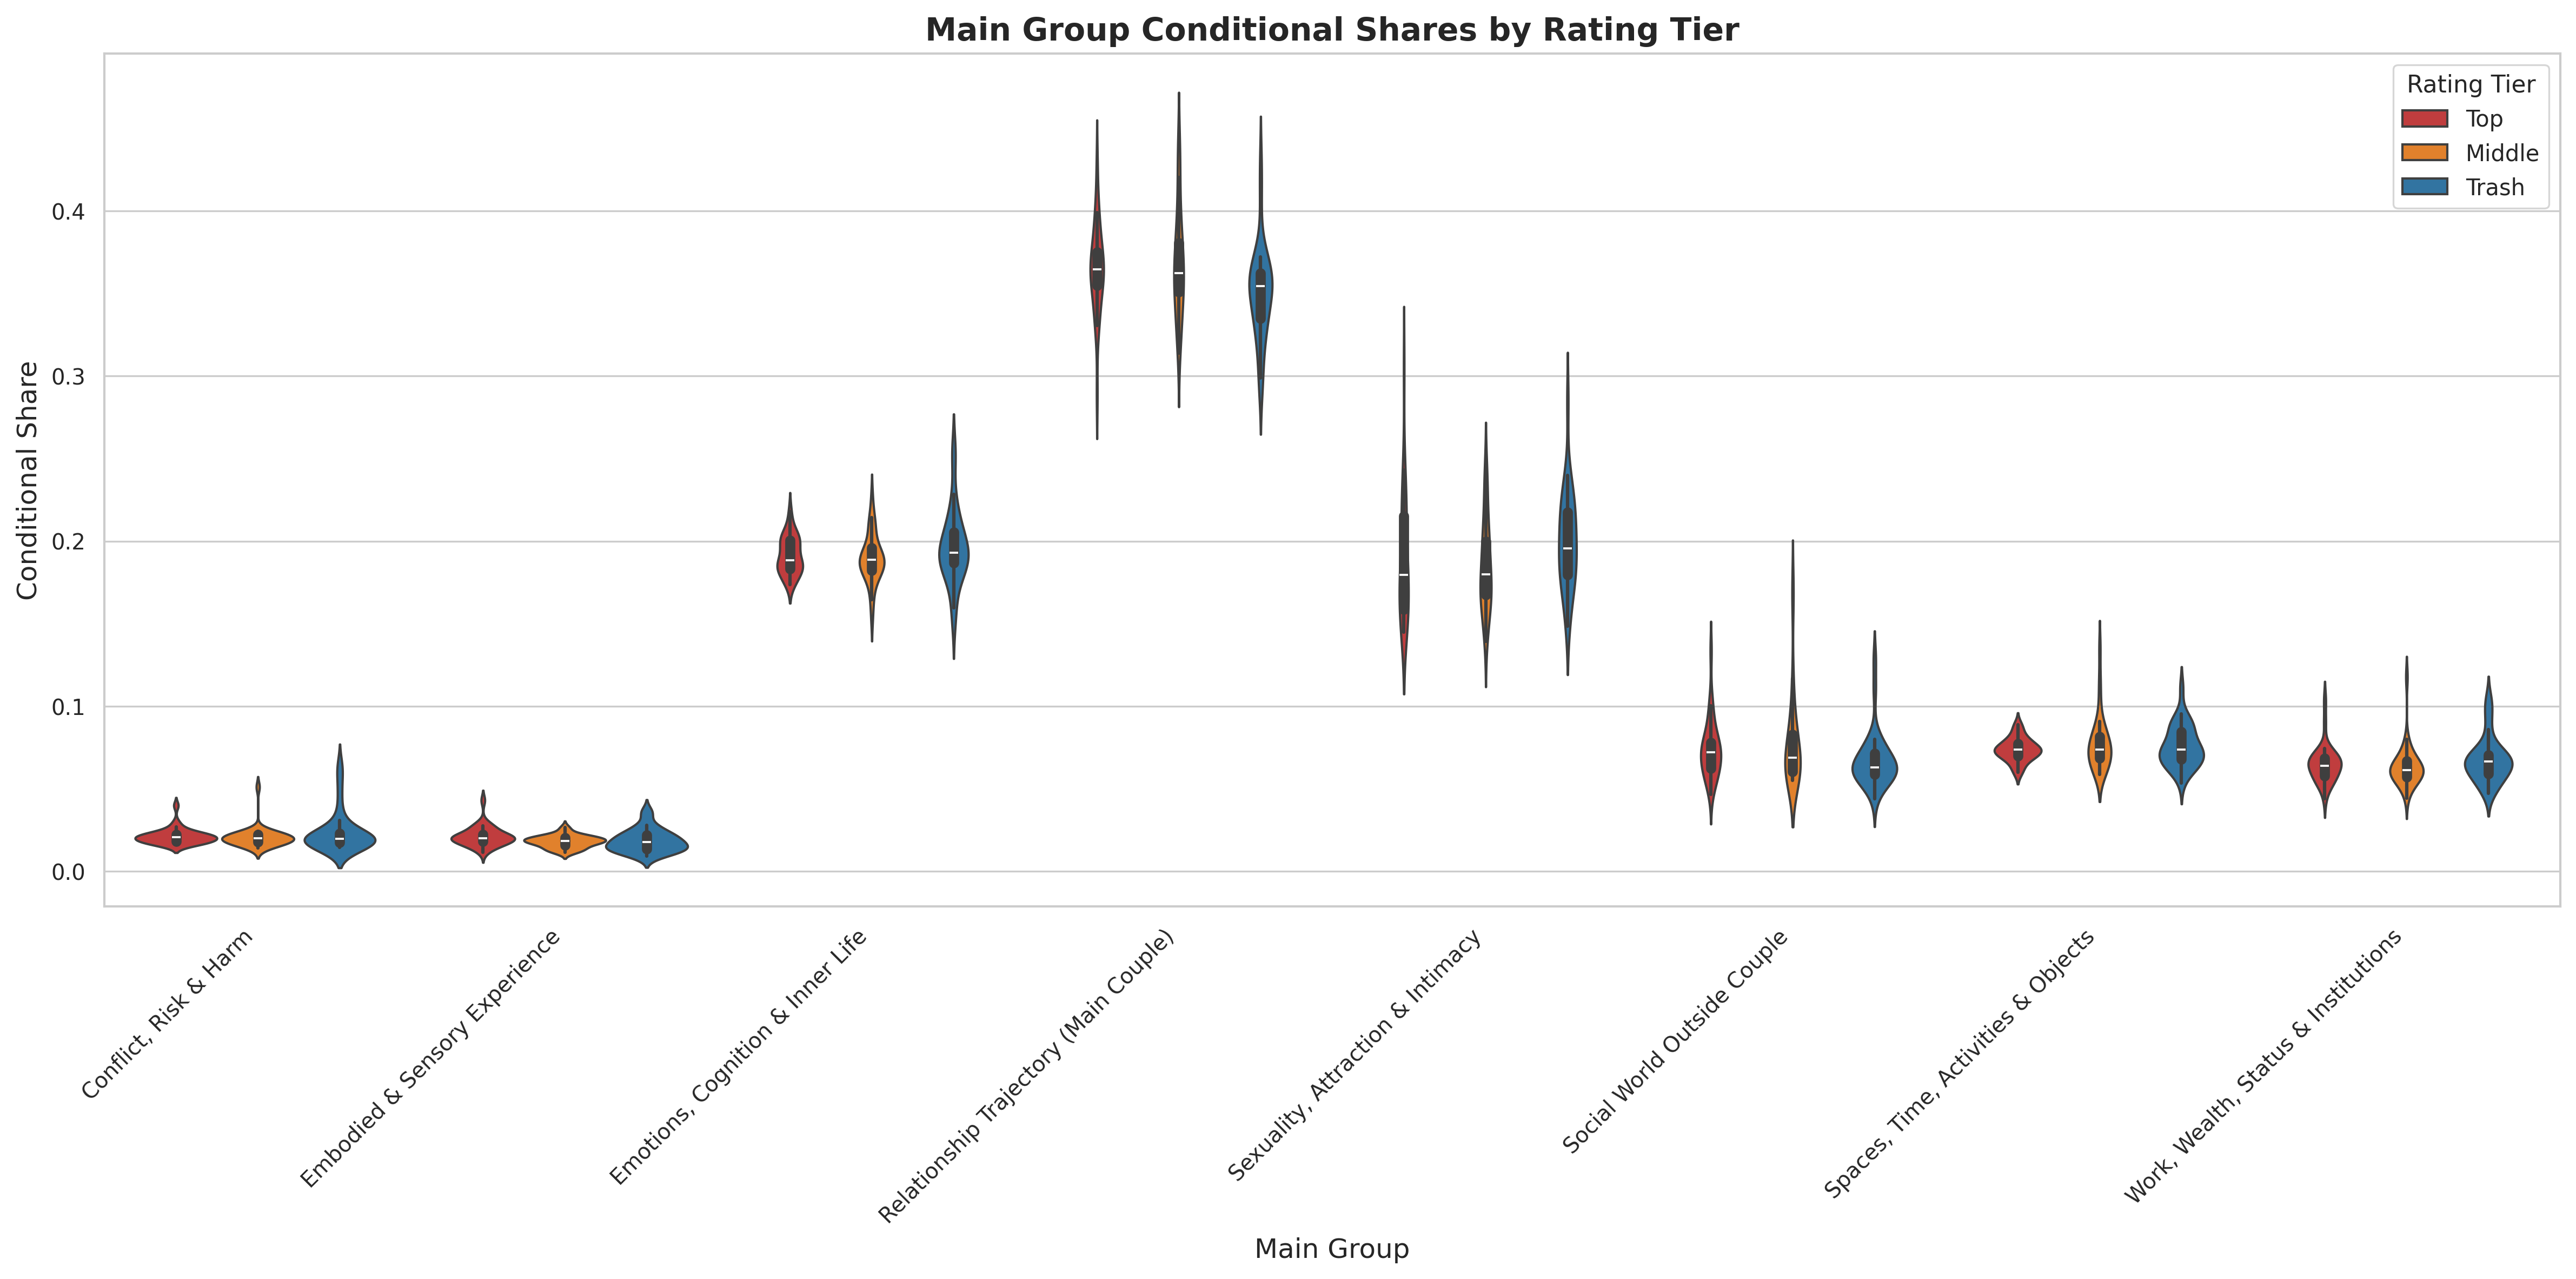

In [84]:
# Create a comprehensive overview plot
main_groups = sorted(book_main_group_shares['taxonomy_main_group'].dropna().unique())

# Prepare data for plotting
plot_data = []
tier_map = {'top': ['top', 'good'], 'middle': ['middle', 'mid'], 'trash': ['trash', 'bad']}
for main_group in main_groups:
    group_data = book_main_group_shares[book_main_group_shares['taxonomy_main_group'] == main_group]
    # Handle tier name variations: top/good, middle/mid, trash/bad
    for tier_key in ['top', 'middle', 'trash']:
        tier = tier_key
        tier_data = group_data[group_data['rating_tier'].isin(tier_map[tier_key])]['cond_share']
        for val in tier_data:
            plot_data.append({
                'Main Group': main_group,
                'Tier': tier_key.capitalize(),
                'Conditional Share': val
            })

plot_df = pd.DataFrame(plot_data)

# Create violin plot with seaborn
fig, ax = plt.subplots(figsize=(16, 8))
sns.violinplot(
    data=plot_df, 
    x='Main Group', 
    y='Conditional Share', 
    hue='Tier',
    hue_order=TIER_ORDER_DISPLAY,
    palette=TIER_COLORS_DISPLAY,
    ax=ax
)
ax.set_title('Main Group Conditional Shares by Rating Tier', fontsize=14, fontweight='bold')
ax.set_xlabel('Main Group', fontsize=12)
ax.set_ylabel('Conditional Share', fontsize=12)
ax.tick_params(axis='x', labelrotation=45)
for label in ax.get_xticklabels():
    label.set_ha('right')
plt.legend(title='Rating Tier', loc='upper right')
plt.tight_layout()
plt.show()

# Also create interactive plotly version (for appendix/interactive use)
fig_plotly = px.violin(
    plot_df,
    x="Main Group",
    y="Conditional Share",
    color="Tier",
    category_orders={
        "Tier": TIER_ORDER_DISPLAY,
        "Main Group": main_groups,  # keep your chosen order
    },
    color_discrete_map=TIER_COLORS_DISPLAY,
    box=True,
    points=False,  # publication: OFF (too busy). Turn on only for exploratory.
    title="Main-group conditional shares by popularity tier",
)
fig_plotly.update_layout(
    height=600,
    xaxis_tickangle=-45,
    legend_title_text="Tier",
)
fig_plotly.show()

# Save interactive version
fig_plotly.write_html(str(MAIN_GROUP_FIG_DIR / "main_groups_overview_violin.html"))

## 9. Main Group Statistical Comparisons

**Statistical Procedure**: 
- **Kruskal-Wallis test**: Tests for differences across all three tiers (Top/Middle/Trash) simultaneously. Non-parametric alternative to one-way ANOVA.
- **Mann-Whitney U test**: Pairwise comparisons between tiers (Top vs Trash, Top vs Middle, Middle vs Trash).
- **Holm correction**: Multiple comparison correction applied to pairwise p-values to control family-wise error rate.
- **Effect sizes**: Cliff's Delta for pairwise comparisons, Epsilon-squared for overall Kruskal-Wallis test.


## 9.5 Pairwise Comparisons Summary Visualization

Create visualizations showing all pairwise Cliff's Delta comparisons across main groups.


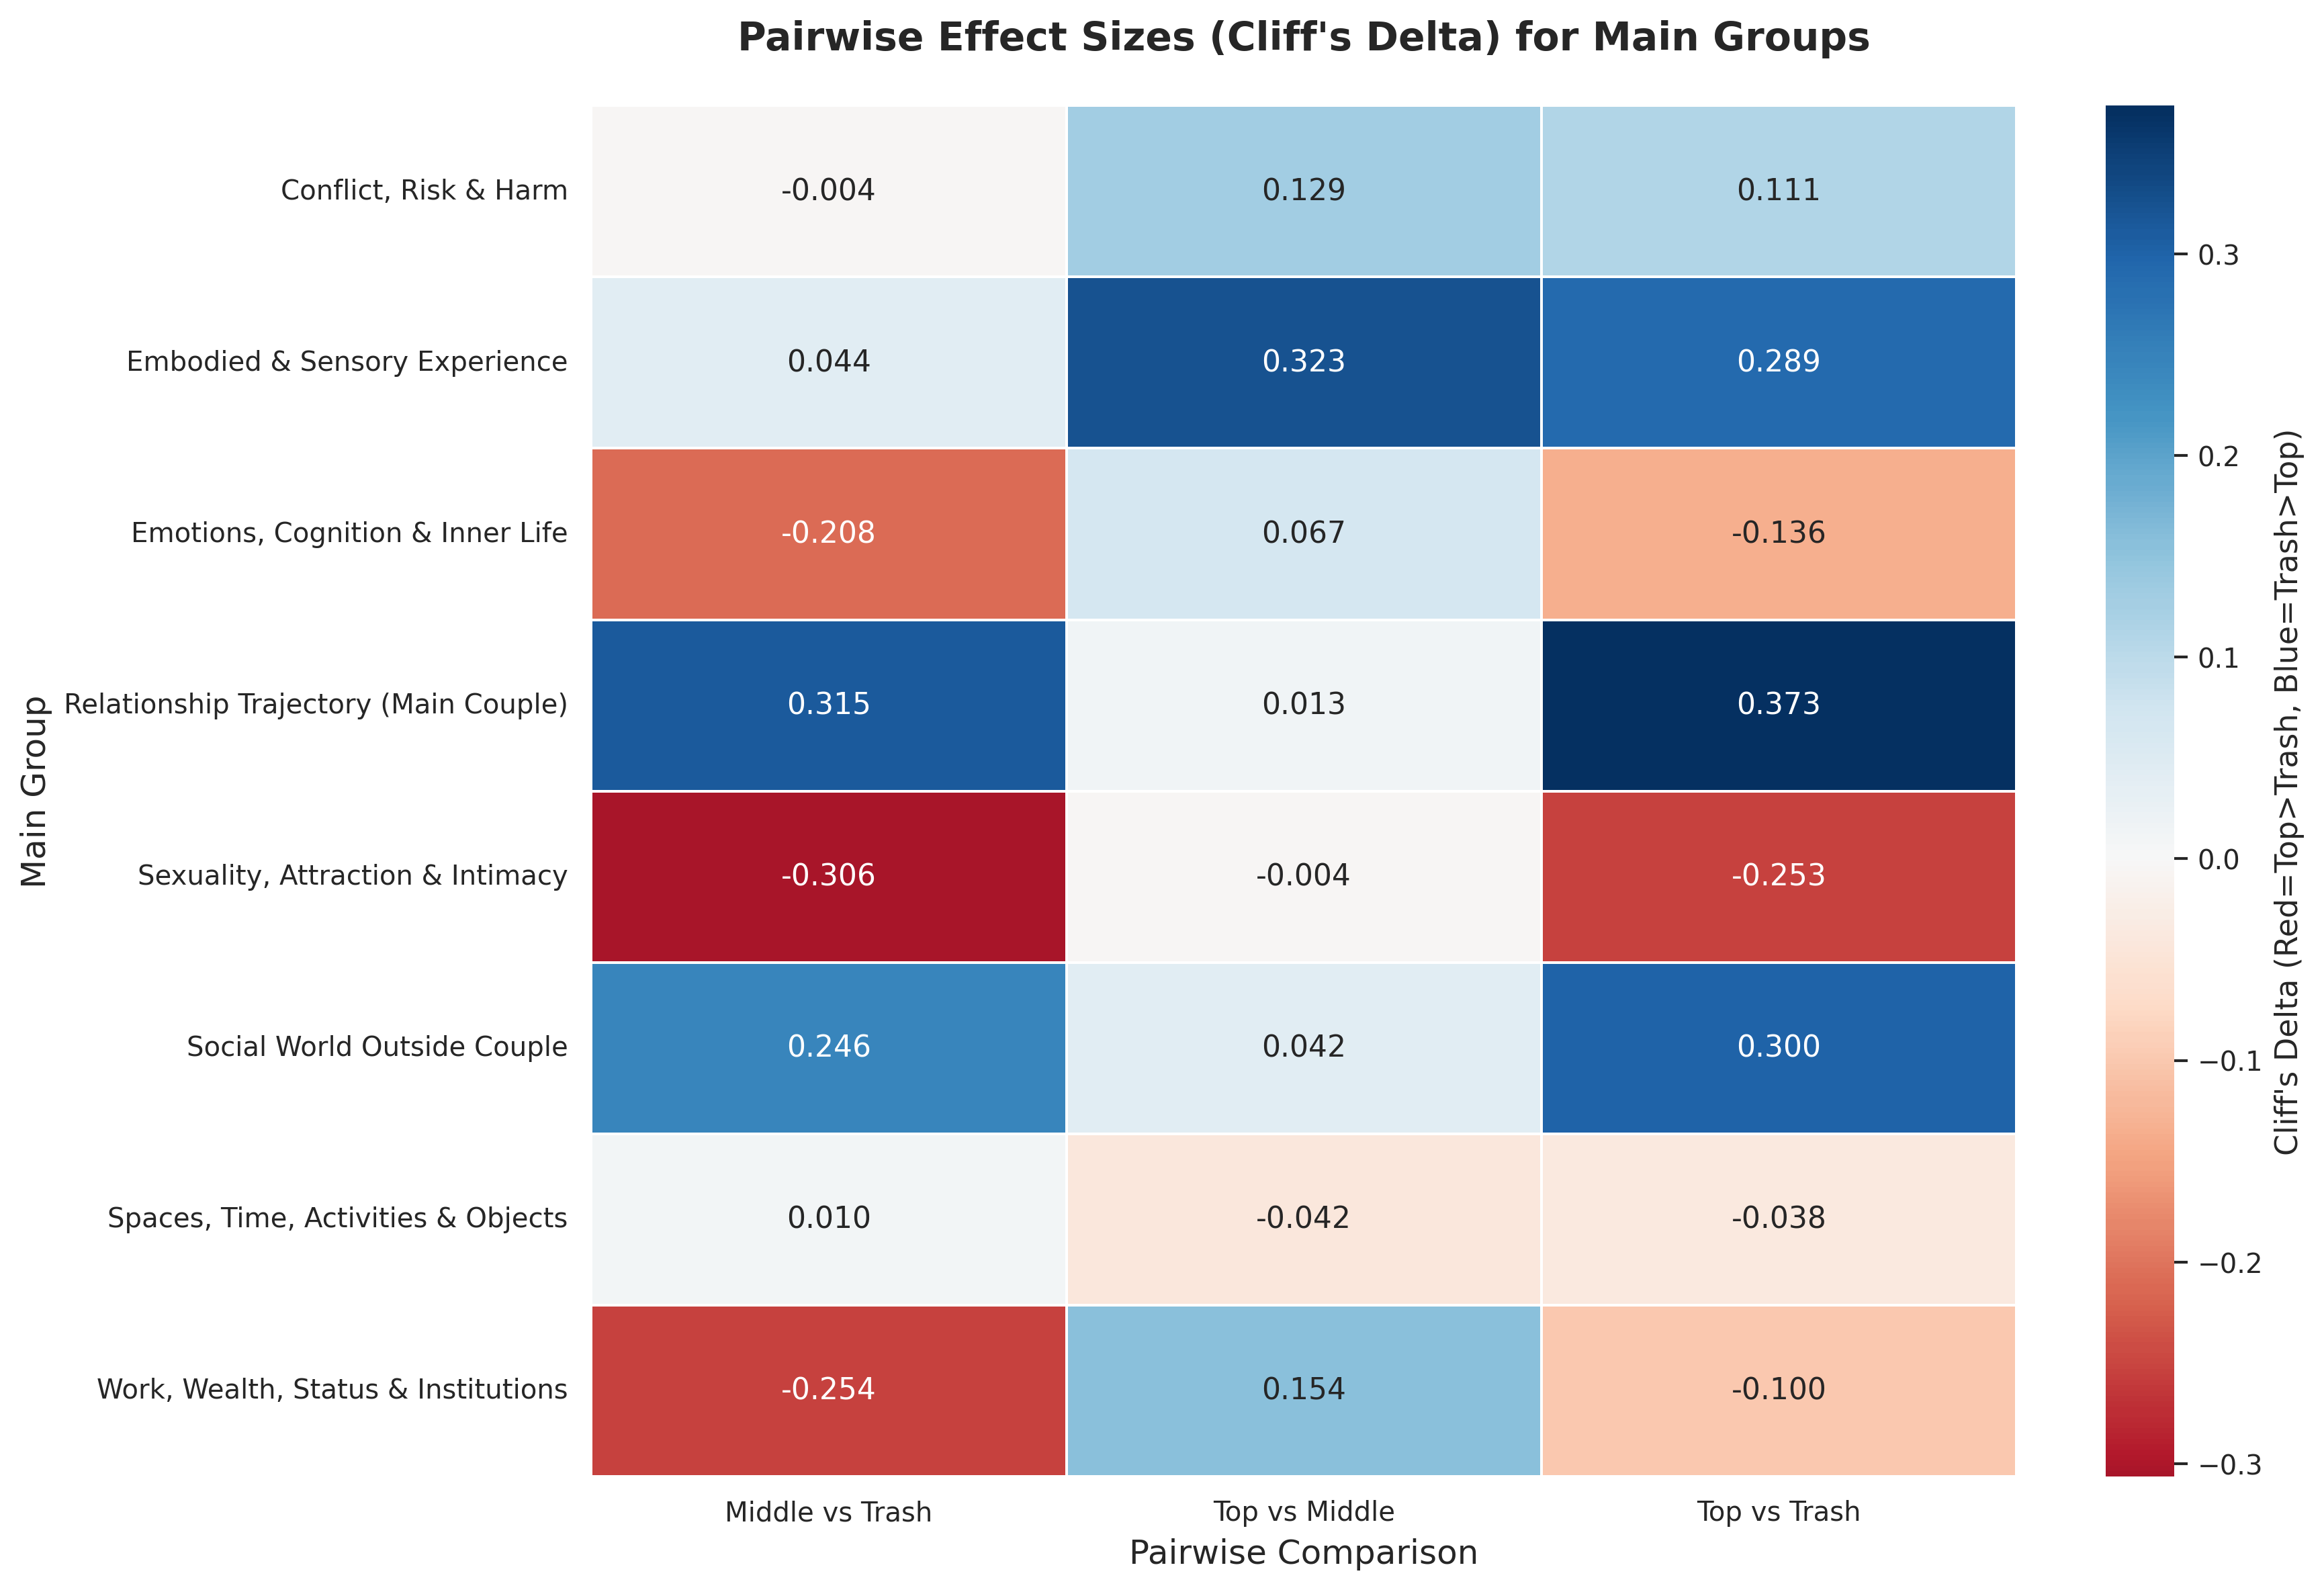


✓ Saved pairwise comparison visualizations to: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/02_taxonomy_group_analysis/figures/main_group_distributions


In [85]:
# Create pairwise comparisons visualization
# Try to load main_group_results from memory or from saved file
if 'main_group_results' in locals() and len(main_group_results) > 0:
    main_group_results_df = main_group_results
elif 'main_group_results' in globals() and len(main_group_results) > 0:
    main_group_results_df = main_group_results
else:
    # Load from saved file
    main_group_results_path = TABLE_DIR / "main_group_comparisons.parquet"
    if main_group_results_path.exists():
        main_group_results_df = pd.read_parquet(main_group_results_path)
        print(f"✓ Loaded main_group_results from {main_group_results_path}")
    else:
        main_group_results_df = None
        print("⚠️  main_group_results not available and file not found")

if main_group_results_df is not None and len(main_group_results_df) > 0:
    # Prepare data for pairwise comparisons heatmap
    pairwise_cols = ['top_vs_trash_delta', 'top_vs_middle_delta', 'middle_vs_trash_delta']
    pairwise_labels = ['Top vs Trash', 'Top vs Middle', 'Middle vs Trash']
    
    # Create heatmap data
    heatmap_data = []
    for _, row in main_group_results_df.iterrows():
        main_group = row['taxonomy_main_group']
        for col, label in zip(pairwise_cols, pairwise_labels):
            if col in row and not np.isnan(row[col]):
                heatmap_data.append({
                    'Main Group': main_group,
                    'Comparison': label,
                    "Cliff's Delta": row[col]
                })
    
    if len(heatmap_data) > 0:
        heatmap_df = pd.DataFrame(heatmap_data)
        
        # Create pivot table
        pivot_data = heatmap_df.pivot(index='Main Group', columns='Comparison', values="Cliff's Delta")
        
        # Matplotlib heatmap
        fig, ax = plt.subplots(figsize=(12, 8))
        sns.heatmap(pivot_data, annot=True, fmt='.3f', cmap='RdBu', center=0,
                   cbar_kws={'label': "Cliff's Delta (Red=Top>Trash, Blue=Trash>Top)"},
                   ax=ax, linewidths=0.5)
        ax.set_title("Pairwise Effect Sizes (Cliff's Delta) for Main Groups", 
                     fontsize=14, fontweight='bold', pad=20)
        ax.set_xlabel('Pairwise Comparison', fontsize=12)
        ax.set_ylabel('Main Group', fontsize=12)
        plt.tight_layout()
        plt.savefig(MAIN_GROUP_FIG_DIR / "pairwise_comparisons_heatmap.png", dpi=300, bbox_inches='tight')
        plt.show()
        
        # Interactive heatmap
        fig_heatmap = px.density_heatmap(
            heatmap_df,
            x='Comparison',
            y='Main Group',
            z="Cliff's Delta",
            color_continuous_scale='RdBu',
            title="Pairwise Effect Sizes (Cliff's Delta) for Main Groups",
            labels={"Cliff's Delta": "Cliff's Delta (Red=Top>Trash, Blue=Trash>Top)"}
        )
        fig_heatmap.update_layout(height=max(600, len(heatmap_df['Main Group'].unique()) * 40))
        fig_heatmap.show()
        fig_heatmap.write_html(str(MAIN_GROUP_FIG_DIR / "pairwise_comparisons_heatmap.html"))
        
        # Bar chart comparing pairwise deltas
        fig_bar = px.bar(
            heatmap_df,
            x='Main Group',
            y="Cliff's Delta",
            color='Comparison',
            barmode='group',
            title="Pairwise Effect Sizes (Cliff's Delta) by Main Group",
            labels={"Cliff's Delta": "Cliff's Delta", "Main Group": "Main Group"},
            color_discrete_map={
                'Top vs Trash': 'rgb(214, 39, 40)',
                'Top vs Middle': 'rgb(255, 127, 14)',
                'Middle vs Trash': 'rgb(31, 119, 180)'
            }
        )
        fig_bar.update_layout(height=600, xaxis_tickangle=-45)
        fig_bar.show()
        fig_bar.write_html(str(MAIN_GROUP_FIG_DIR / "pairwise_comparisons_bar.html"))
    
    print(f"\n✓ Saved pairwise comparison visualizations to: {MAIN_GROUP_FIG_DIR}")
else:
    print("⚠️  main_group_results not available for visualization")

In [86]:
print("=" * 80)
print("Main-Group Tier Comparisons:")
print("=" * 80)

def plot_main_group_distribution(main_group: str, df: pd.DataFrame, save_dir: Path, show_plot=True):
    """Create violin + box plot for a main group across tiers."""
    group_data = df[df['taxonomy_main_group'] == main_group].copy()

    if len(group_data) == 0:
        return None

    fig = go.Figure()

    tiers = ['top', 'middle', 'trash']
    colors = ['rgb(31, 119, 180)', 'rgb(255, 127, 14)', 'rgb(44, 160, 44)']

    for tier, color in zip(tiers, colors):
        tier_data = group_data[group_data['rating_tier'] == tier]['cond_share']
        if len(tier_data) > 0:
            fig.add_trace(go.Violin(
                y=tier_data,
                name=tier.capitalize(),
                box_visible=True,
                meanline_visible=True,
                fillcolor=f"rgba({color.replace('rgb(', '').replace(')', '')}, 0.6)",
                line_color=color,
                opacity=0.7
            ))

    fig.update_layout(
        title=f"Main Group Distribution: {main_group}",
        yaxis_title="Conditional Share",
        xaxis_title="Rating Tier",
        violinmode="group",
        height=500,
        showlegend=True
    )

    safe_name = "".join(c if c.isalnum() or c in (' ', '-', '_') else '_' for c in main_group)[:50]
    html_path = save_dir / f"main_group_{safe_name}_violin.html"
    fig.write_html(str(html_path))
    
    if show_plot:
        fig.show()

    return fig

# Get unique main groups
main_groups = sorted(book_main_group_shares['taxonomy_main_group'].dropna().unique())
print(f"\nAnalyzing {len(main_groups)} main groups:")

# Ensure rating_tier is set in book_main_group_shares
if 'rating_tier' not in book_main_group_shares.columns or book_main_group_shares['rating_tier'].isna().all():
    print("⚠️  rating_tier missing or all NaN in book_main_group_shares, attempting to fix...")
    # Try to get rating_tier from book_meta
    if 'book_meta' in locals() and 'book_meta' in globals() and book_meta is not None:
        if 'rating_class' in book_meta.columns:
            book_meta_with_tier = book_meta.copy()
            book_meta_with_tier['rating_tier'] = book_meta_with_tier['rating_class']
            book_main_group_shares = book_main_group_shares.merge(
                book_meta_with_tier[['book_id', 'rating_tier']].drop_duplicates(),
                on='book_id',
                how='left'
            )
            print("✓ Added rating_tier from book_meta['rating_class']")
        elif 'rating_mean' in book_meta.columns:
            def assign_tier(rating):
                if pd.isna(rating):
                    return None
                if rating >= 4.0:
                    return 'top'
                elif rating >= 3.8:
                    return 'middle'
                else:
                    return 'trash'
            book_meta_with_tier = book_meta.copy()
            book_meta_with_tier['rating_tier'] = book_meta_with_tier['rating_mean'].apply(assign_tier)
            book_main_group_shares = book_main_group_shares.merge(
                book_meta_with_tier[['book_id', 'rating_tier']].drop_duplicates(),
                on='book_id',
                how='left'
            )
            print("✓ Added rating_tier from book_meta['rating_mean']")
    else:
        print("⚠️  book_meta not available, cannot fix rating_tier")
else:
    # Check if rating_tier has valid values
    valid_tiers = book_main_group_shares['rating_tier'].dropna()
    if len(valid_tiers) == 0:
        print("⚠️  rating_tier column exists but all values are NaN")
    else:
        print(f"✓ rating_tier is set: {valid_tiers.value_counts().to_dict()}")

# Normalize tier names to standard format (good->top, bad->trash, mid->middle)
if 'rating_tier' in book_main_group_shares.columns:
    tier_normalization_map = {'good': 'top', 'bad': 'trash', 'mid': 'middle'}
    book_main_group_shares['rating_tier'] = book_main_group_shares['rating_tier'].map(
        lambda x: tier_normalization_map.get(x, x) if pd.notna(x) else x
    )

results_main = []

for main_group in main_groups:
    group_data = book_main_group_shares[
        book_main_group_shares['taxonomy_main_group'] == main_group
    ].copy()

    if len(group_data) == 0:
        continue

    # Extract data by tier (handle tier name variations: 'top'/'good', 'middle'/'mid', 'trash'/'bad')
    top_data = group_data[group_data['rating_tier'].isin(['top', 'good'])]['cond_share'].values
    middle_data = group_data[group_data['rating_tier'].isin(['middle', 'mid'])]['cond_share'].values
    trash_data = group_data[group_data['rating_tier'].isin(['trash', 'bad'])]['cond_share'].values

    # Kruskal-Wallis test
    kruskal_stat = np.nan
    kruskal_p = np.nan
    epsilon_sq = np.nan

    all_tiers = []
    for tier_data in [top_data, middle_data, trash_data]:
        if len(tier_data) > 0:
            all_tiers.append(tier_data)

    if len(all_tiers) >= 2:
        try:
            kruskal_stat, kruskal_p = kruskal(*all_tiers)
            n_total = len(top_data) + len(middle_data) + len(trash_data)
            epsilon_sq = compute_epsilon_squared(kruskal_stat, n_total, 3)
        except:
            pass

    # Pairwise comparisons with Holm correction
    pairwise_results = {}
    for pair_name, (data1, data2) in [
        ('top_vs_trash', (top_data, trash_data)),
        ('top_vs_middle', (top_data, middle_data)),
        ('middle_vs_trash', (middle_data, trash_data))
    ]:
        if len(data1) > 0 and len(data2) > 0:
            try:
                _, p_val = mannwhitneyu(data1, data2, alternative='two-sided')
                delta = cliffs_delta(data1, data2)
                pairwise_results[pair_name] = {'p': p_val, 'delta': delta}
            except:
                pairwise_results[pair_name] = {'p': np.nan, 'delta': np.nan}
        else:
            pairwise_results[pair_name] = {'p': np.nan, 'delta': np.nan}

    # Summary statistics
    result = {
        'taxonomy_main_group': main_group,
        'n_books': len(group_data),
        'top_median': np.median(top_data) if len(top_data) > 0 else np.nan,
        'top_mean': np.mean(top_data) if len(top_data) > 0 else np.nan,
        'top_q1': np.percentile(top_data, 25) if len(top_data) > 0 else np.nan,
        'top_q3': np.percentile(top_data, 75) if len(top_data) > 0 else np.nan,
        'middle_median': np.median(middle_data) if len(middle_data) > 0 else np.nan,
        'middle_mean': np.mean(middle_data) if len(middle_data) > 0 else np.nan,
        'middle_q1': np.percentile(middle_data, 25) if len(middle_data) > 0 else np.nan,
        'middle_q3': np.percentile(middle_data, 75) if len(middle_data) > 0 else np.nan,
        'trash_median': np.median(trash_data) if len(trash_data) > 0 else np.nan,
        'trash_mean': np.mean(trash_data) if len(trash_data) > 0 else np.nan,
        'trash_q1': np.percentile(trash_data, 25) if len(trash_data) > 0 else np.nan,
        'trash_q3': np.percentile(trash_data, 75) if len(trash_data) > 0 else np.nan,
        'kruskal_stat': kruskal_stat,
        'kruskal_p': kruskal_p,
        'epsilon_squared': epsilon_sq,
        'top_vs_trash_delta': pairwise_results['top_vs_trash']['delta'],
        'top_vs_trash_p': pairwise_results['top_vs_trash']['p'],
        'top_vs_middle_delta': pairwise_results['top_vs_middle']['delta'],
        'top_vs_middle_p': pairwise_results['top_vs_middle']['p'],
        'middle_vs_trash_delta': pairwise_results['middle_vs_trash']['delta'],
        'middle_vs_trash_p': pairwise_results['middle_vs_trash']['p'],
    }

    results_main.append(result)

    # Create plot
    plot_main_group_distribution(main_group, book_main_group_shares, MAIN_GROUP_FIG_DIR, show_plot=True)

    print(f"  ✓ {main_group}: n={len(group_data)}, KW p={kruskal_p:.4f}, ε²={epsilon_sq:.4f}")

# Apply Holm correction to pairwise p-values
all_pairwise_p = []
pairwise_indices = []
for i, r in enumerate(results_main):
    for col in ['top_vs_trash_p', 'top_vs_middle_p', 'middle_vs_trash_p']:
        if not np.isnan(r[col]):
            all_pairwise_p.append(r[col])
            pairwise_indices.append((i, col))

if len(all_pairwise_p) > 0:
    _, p_adj_holm, _, _ = multipletests(all_pairwise_p, method='holm', alpha=0.05)

    # Map back
    for idx, (result_idx, col) in enumerate(pairwise_indices):
        results_main[result_idx][f"{col}_adj"] = p_adj_holm[idx]
    # Fill NaN for missing values
    for r in results_main:
        for col in ['top_vs_trash_p', 'top_vs_middle_p', 'middle_vs_trash_p']:
            if f"{col}_adj" not in r:
                r[f"{col}_adj"] = np.nan

# Create results DataFrame
main_group_results = pd.DataFrame(results_main)

# Save results (both Parquet and CSV)
main_group_results.to_parquet(TABLE_DIR / "main_group_comparisons.parquet", index=False)
main_group_results.to_csv(TABLE_DIR / "main_group_comparisons.csv", index=False)

print(f"\n✓ Saved main group comparison results to: {TABLE_DIR / 'main_group_comparisons.parquet'}")
print(f"\nMain group results summary:")
display(main_group_results[['taxonomy_main_group', 'kruskal_p', 'epsilon_squared',
                             'top_median', 'middle_median', 'trash_median']])

Main-Group Tier Comparisons:

Analyzing 8 main groups:
✓ rating_tier is set: {'mid': 256, 'bad': 240, 'good': 240}


  ✓ Conflict, Risk & Harm: n=92, KW p=0.6461, ε²=-0.0127


  ✓ Embodied & Sensory Experience: n=92, KW p=0.0593, ε²=0.0410


  ✓ Emotions, Cognition & Inner Life: n=92, KW p=0.3652, ε²=0.0002


  ✓ Relationship Trajectory (Main Couple): n=92, KW p=0.0288, ε²=0.0572


  ✓ Sexuality, Attraction & Intimacy: n=92, KW p=0.0937, ε²=0.0307


  ✓ Social World Outside Couple: n=92, KW p=0.1035, ε²=0.0285


  ✓ Spaces, Time, Activities & Objects: n=92, KW p=0.9521, ε²=-0.0214


  ✓ Work, Wealth, Status & Institutions: n=92, KW p=0.2202, ε²=0.0115

✓ Saved main group comparison results to: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/02_taxonomy_group_analysis/tables_csv/main_group_comparisons.parquet

Main group results summary:


,taxonomy_main_group,kruskal_p,epsilon_squared,top_median,middle_median,trash_median
0,"Conflict, Risk & Harm",0.646075,-0.012655,0.020672,0.019981,0.019703
1,Embodied & Sensory Experience,0.059300,0.041015,0.020195,0.018357,0.017658
2,"Emotions, Cognition & Inner Life",0.365164,0.000167,0.188439,0.188741,0.193053
3,Relationship Trajectory (Main Couple),0.028806,0.057240,0.364503,0.362183,0.354476
4,"Sexuality, Attraction & Intimacy",0.093701,0.030734,0.179395,0.179780,0.195616
5,Social World Outside Couple,0.103488,0.028501,0.072099,0.068724,0.063068
6,"Spaces, Time, Activities & Objects",0.952121,-0.021369,0.073879,0.073732,0.073814
7,"Work, Wealth, Status & Institutions",0.220151,0.011538,0.063819,0.061378,0.066608


## 10. Main Group Bar Chart & Effect Size Visualization

Create summary visualizations showing mean conditional shares and effect sizes across main groups.


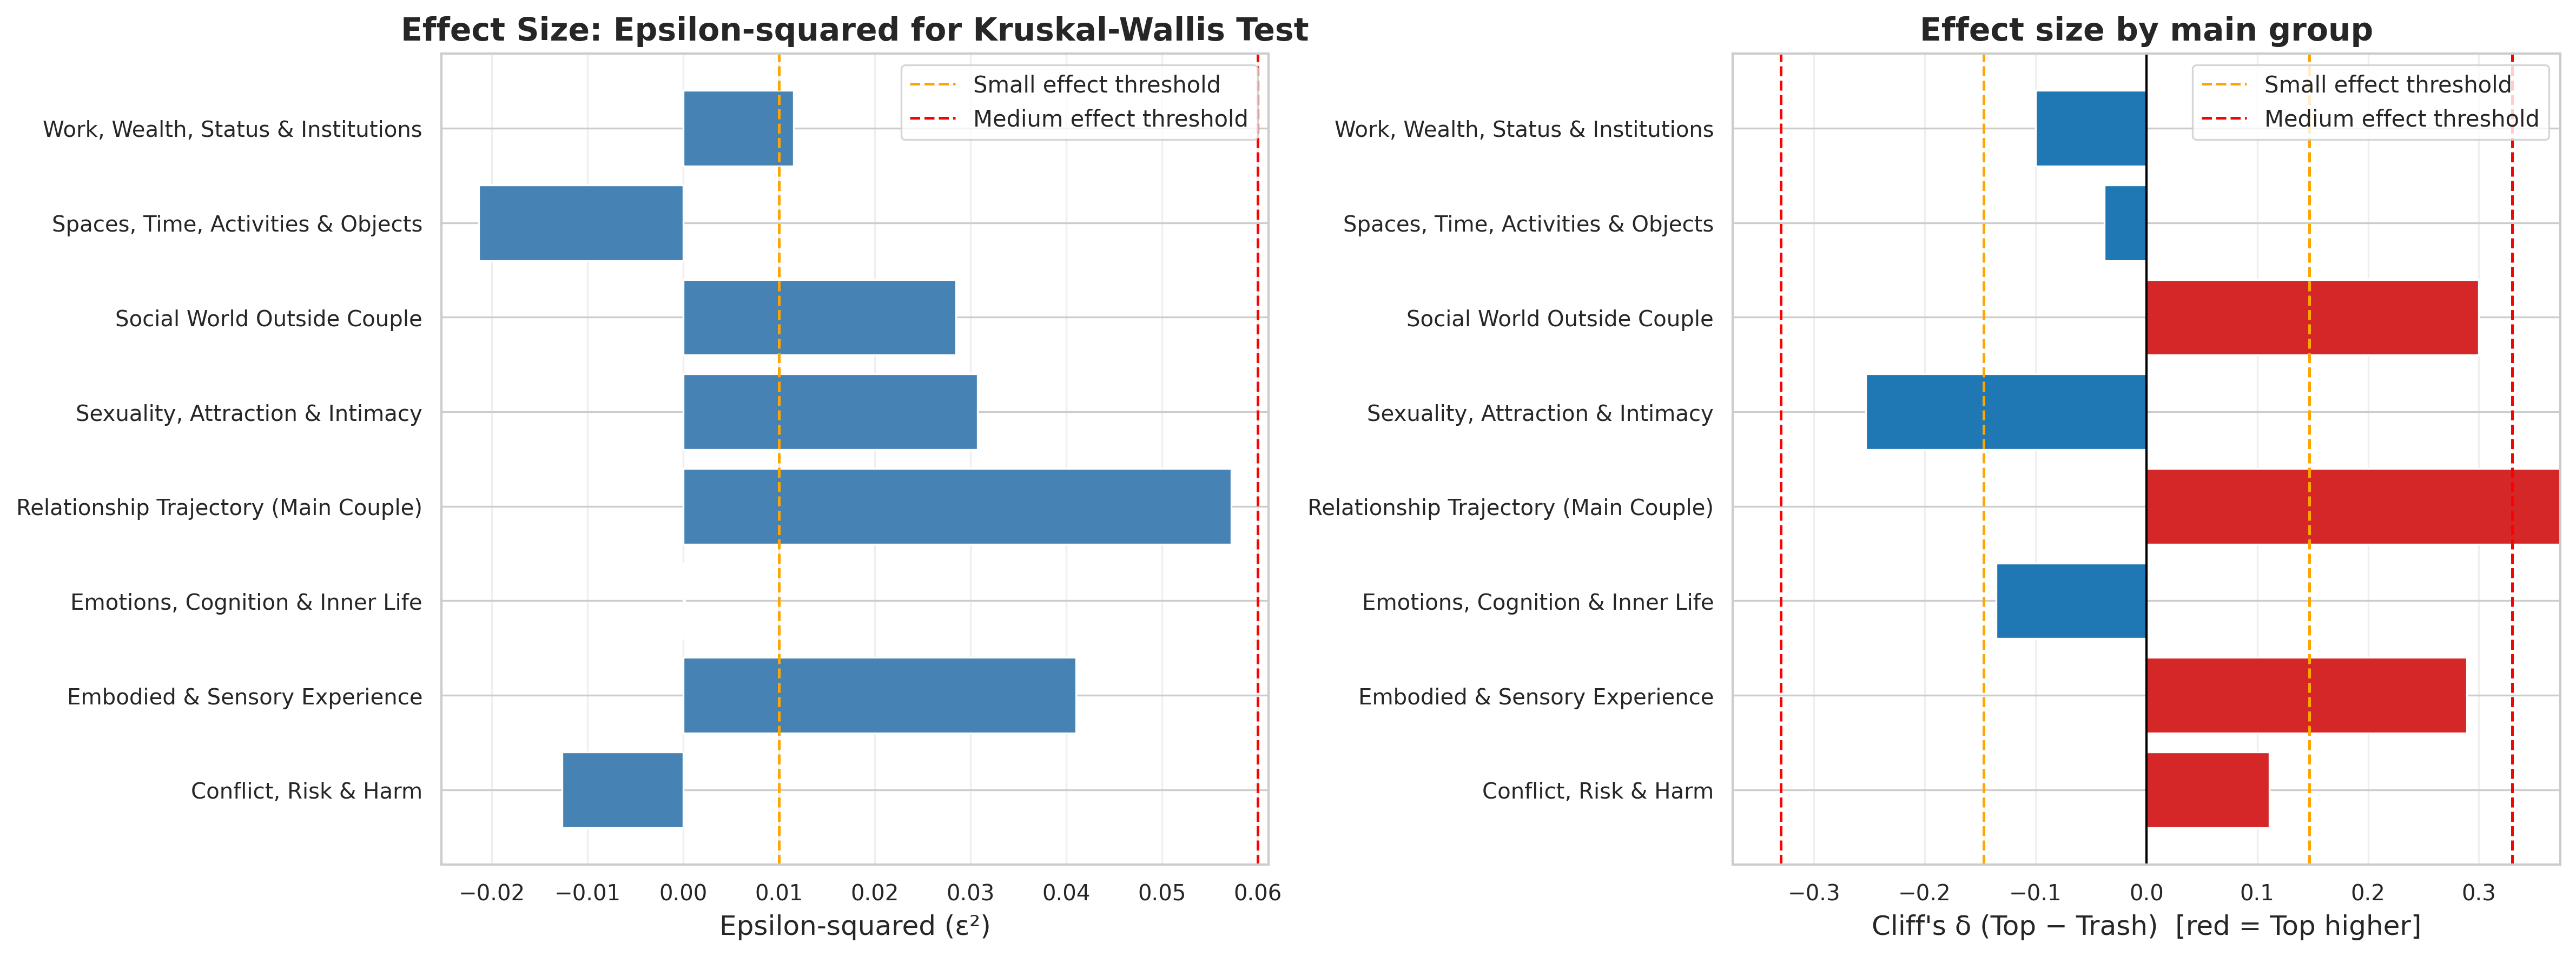

<Figure size 960x720 with 0 Axes>

In [87]:
# Prepare data for bar chart
bar_data = []
for _, row in main_group_results.iterrows():
    main_group = row['taxonomy_main_group']
    for tier in ['top', 'middle', 'trash']:
        bar_data.append({
            'main_group': main_group,
            'tier': tier.capitalize(),
            'mean_share': row[f'{tier}_mean'],
            'median_share': row[f'{tier}_median']
        })

bar_df = pd.DataFrame(bar_data)

# Create bar chart
fig_bar = px.bar(
    bar_df,
    x='main_group',
    y='mean_share',
    color='tier',
    barmode='group',
    title='Mean Conditional Shares by Main Group and Tier',
    labels={'mean_share': 'Mean Conditional Share', 'main_group': 'Main Group'},
    color_discrete_map={'Top': 'rgb(214, 39, 40)', 'Middle': 'rgb(255, 127, 14)', 'Trash': 'rgb(31, 119, 180)'}
)

fig_bar.update_layout(height=600, xaxis_tickangle=-45)
fig_bar.show()
fig_bar.write_html(str(MAIN_GROUP_FIG_DIR / "main_groups_bar_chart.html"))

# Create effect size visualization
effect_data = []
for _, row in main_group_results.iterrows():
    effect_data.append({
        'Main Group': row['taxonomy_main_group'],
        'Epsilon²': row['epsilon_squared'],
        'Kruskal-Wallis p': row['kruskal_p'],
        'Top vs Trash δ': row['top_vs_trash_delta'] if not np.isnan(row['top_vs_trash_delta']) else 0
    })

effect_df = pd.DataFrame(effect_data)

# Plot effect sizes
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Epsilon-squared
axes[0].barh(effect_df['Main Group'], effect_df['Epsilon²'], color='steelblue')
axes[0].axvline(x=0.01, color='orange', linestyle='--', label='Small effect threshold')
axes[0].axvline(x=0.06, color='red', linestyle='--', label='Medium effect threshold')
axes[0].set_xlabel('Epsilon-squared (ε²)', fontsize=12)
axes[0].set_title('Effect Size: Epsilon-squared for Kruskal-Wallis Test', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(axis='x', alpha=0.3)

# Cliff's Delta (Top vs Trash) - signed values with sign-consistent coloring
vals = effect_df["Top vs Trash δ"].values
lim = np.max(np.abs(vals)) if len(vals) else 0.35
lim = max(lim, 1e-6)

colors = np.where(vals >= 0, TIER_COLORS["top"], TIER_COLORS["trash"])  # red if Top>Trash, else blue

axes[1].barh(effect_df["Main Group"], vals, color=colors)
axes[1].axvline(0, color="black", linewidth=1)
axes[1].axvline(x=0.147, color='orange', linestyle='--', label="Small effect threshold")    # Cliff's delta |d| = .147 small
axes[1].axvline(x=-0.147, color='orange', linestyle='--')
axes[1].axvline(x=0.33, color='red', linestyle='--', label="Medium effect threshold")      # |d| = .33 medium
axes[1].axvline(x=-0.33, color='red', linestyle='--')
axes[1].set_xlim(-lim, lim)
axes[1].set_xlabel("Cliff's δ (Top − Trash)  [red = Top higher]", fontsize=12)
axes[1].set_title("Effect size by main group", fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Save
plt.savefig(MAIN_GROUP_FIG_DIR / "effect_sizes.png", dpi=300, bbox_inches='tight')
plt.savefig(MAIN_GROUP_FIG_DIR / "effect_sizes.pdf", bbox_inches='tight')

## 11. Compute Subgroup Shares (Within-Group Normalization)

Compute subgroup shares normalized within each main group. This allows us to compare the relative importance of subgroups within each main group category, independent of the main group's overall size.


In [88]:
import warnings

with warnings.catch_warnings():
    warnings.simplefilter('ignore', category=FutureWarning)

    print("=" * 80)
    print("Computing book_subgroup_shares:")
    print("=" * 80)

    # Merge taxonomy info - only select columns that exist in mapping_export
    merge_cols = ['topic_id', 'taxonomy_main_group', 'taxonomy_main_name',
                  'author_dominance_flag', 'label_is_noise', 'taxonomy_is_noise',
                  'is_paratext', 'taxonomy_confidence']
    available_cols = [c for c in merge_cols if c in mapping_export.columns]
    
    df_sub = book_topic_probs.merge(
        mapping_export[available_cols],
        on='topic_id',
        how='left'
    )

    # Apply filters (match main-group thematic definition)
    df_sub = df_sub[df_sub['topic_id'] != -1]  # exclude OTHER always
    
    # Filter by author_dominance_flag only if it exists
    if 'author_dominance_flag' in df_sub.columns:
        df_sub = df_sub[df_sub['author_dominance_flag'] != 'high']
    
    if 'label_is_noise' in df_sub.columns:
        df_sub = df_sub[~df_sub['label_is_noise'].fillna(False).infer_objects(copy=False)]
    
    if 'taxonomy_is_noise' in df_sub.columns:
        df_sub = df_sub[~df_sub['taxonomy_is_noise'].fillna(False).infer_objects(copy=False)]

    # Exclude paratext if present in mapping_export
    if 'is_paratext' in df_sub.columns:
        df_sub = df_sub[~df_sub['is_paratext'].fillna(False).infer_objects(copy=False)]

    # IMPORTANT: do NOT filter gate3_pass for subgroup composition (keep long-tail topics)
    # df_sub = df_sub[df_sub['gate3_pass'].fillna(False).infer_objects(copy=False)]

    # Compute subgroup sums per (book, main_group, subgroup)
    # Note: taxonomy_confidence is categorical ('high', 'medium', 'low'), so we use 'first' instead of mean
    subgroup_sums = df_sub.groupby(['book_id', 'taxonomy_main_group', 'taxonomy_main_name']).agg({
        'prob': 'sum',
        'taxonomy_confidence': 'first'  # Use 'first' for categorical data (representative value)
    }).reset_index()
    subgroup_sums.columns = ['book_id', 'taxonomy_main_group', 'taxonomy_main_name',
                             'subgroup_sum', 'mapping_confidence']

    # Compute group sums per (book, main_group)
    group_sums = df_sub.groupby(['book_id', 'taxonomy_main_group'])['prob'].sum().reset_index()
    group_sums.columns = ['book_id', 'taxonomy_main_group', 'group_sum']

    # Merge to compute within-group shares
    book_subgroup_shares = subgroup_sums.merge(group_sums, on=['book_id', 'taxonomy_main_group'], how='left')
    book_subgroup_shares['within_group_share'] = (
        book_subgroup_shares['subgroup_sum'] / book_subgroup_shares['group_sum'].replace(0, np.nan)
    )

    # Merge rating_tier
    if 'rating_tier' in df_sub.columns:
        book_subgroup_shares = book_subgroup_shares.merge(
            df_sub[['book_id', 'rating_tier']].drop_duplicates(),
            on='book_id',
            how='left'
        )
    elif 'rating_tier' in book_topic_probs.columns:
        book_subgroup_shares = book_subgroup_shares.merge(
            book_topic_probs[['book_id', 'rating_tier']].drop_duplicates(),
            on='book_id',
            how='left'
        )
    elif 'rating_tier' in book_main_group_shares.columns:
        # Fallback: get rating_tier from book_main_group_shares (computed earlier)
        book_subgroup_shares = book_subgroup_shares.merge(
            book_main_group_shares[['book_id', 'rating_tier']].drop_duplicates(),
            on='book_id',
            how='left'
        )
    else:
        book_subgroup_shares['rating_tier'] = None

    # Compute absolute share (for reference)
    book_subgroup_shares = book_subgroup_shares.merge(
        book_main_group_shares[['book_id', 'taxonomy_main_group', 'modeled_mass']],
        on=['book_id', 'taxonomy_main_group'],
        how='left'
    )
    book_subgroup_shares['abs_share_subgroup'] = (
        book_subgroup_shares['subgroup_sum'] / book_subgroup_shares['modeled_mass'].replace(0, np.nan)
    )

    # Reorder columns
    book_subgroup_shares = book_subgroup_shares[[
        'book_id', 'rating_tier', 'taxonomy_main_group', 'taxonomy_main_name',
        'abs_share_subgroup', 'within_group_share', 'group_sum',
        'mapping_confidence'
    ]].copy()

    print(f"\n✓ Computed book_subgroup_shares: {book_subgroup_shares.shape}")
    print(f"  Unique books: {book_subgroup_shares['book_id'].nunique()}")
    print(f"  Unique subgroups: {book_subgroup_shares['taxonomy_main_name'].nunique()}")

    # Show subgroups per main group
    print(f"\nSubgroups per main group:")
    for main_group in sorted(book_subgroup_shares['taxonomy_main_group'].dropna().unique()):
        n_subgroups = book_subgroup_shares[book_subgroup_shares['taxonomy_main_group'] == main_group]['taxonomy_main_name'].nunique()
        print(f"  {main_group}: {n_subgroups} subgroups")

    # Attach per-book coverage columns
    coverage_cols = ['book_id', 'modeled_mass', 'other_share', 'paratext_share', 'noise_share', 'unmapped_share']
    book_cov = book_main_group_shares[coverage_cols].drop_duplicates()
    book_subgroup_shares = book_subgroup_shares.merge(book_cov, on='book_id', how='left')

    # Sanity check: totals ≈ 1 per book
    print("\nSanity checks (subgroups):")
    cov_sub = book_subgroup_shares.groupby('book_id')[['modeled_mass','other_share','paratext_share','noise_share','unmapped_share']].first()
    cov_sub['total'] = cov_sub.sum(axis=1)
    print("  modeled+other+paratext+noise+unmapped total: min/max:", cov_sub['total'].min(), cov_sub['total'].max())
    print("  Books with total ≈ 1 (within 0.01):", (cov_sub['total'].between(0.99, 1.01)).sum(), "/", len(cov_sub))
    print("  Books with total ≈ 1 (within 0.05):", (cov_sub['total'].between(0.95, 1.05)).sum(), "/", len(cov_sub))

    # Save

    # Normalize rating_tier values before saving: good->top, bad->trash, mid->middle
    tier_normalization_map = {'good': 'top', 'bad': 'trash', 'mid': 'middle'}
    if 'rating_tier' in book_subgroup_shares.columns:
        book_subgroup_shares['rating_tier'] = book_subgroup_shares['rating_tier'].map(
            lambda x: tier_normalization_map.get(x, x) if pd.notna(x) else x
        )
    book_subgroup_shares.to_csv(TABLE_DIR / "book_subgroup_shares.csv", index=False)
    book_subgroup_shares.to_csv(TABLE_DIR / "book_subgroup_shares.csv", index=False)
    print(f"\n✓ Saved to: {TABLE_DIR / 'book_subgroup_shares.parquet'}")

Computing book_subgroup_shares:

✓ Computed book_subgroup_shares: (2484, 8)
  Unique books: 92
  Unique subgroups: 27

Subgroups per main group:
  Conflict, Risk & Harm: 2 subgroups
  Embodied & Sensory Experience: 2 subgroups
  Emotions, Cognition & Inner Life: 4 subgroups
  Relationship Trajectory (Main Couple): 5 subgroups
  Sexuality, Attraction & Intimacy: 3 subgroups
  Social World Outside Couple: 3 subgroups
  Spaces, Time, Activities & Objects: 3 subgroups
  Work, Wealth, Status & Institutions: 5 subgroups

Sanity checks (subgroups):
  modeled+other+paratext+noise+unmapped total: min/max: 1.0008234369621483 1.0202031269645226
  Books with total ≈ 1 (within 0.01): 89 / 92
  Books with total ≈ 1 (within 0.05): 92 / 92

✓ Saved to: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/02_taxonomy_group_analysis/tables_csv/book_subgroup_shares.parquet


## 14.5 Topic Drivers Visualization

Create visualizations showing top topic drivers for each significant subgroup.


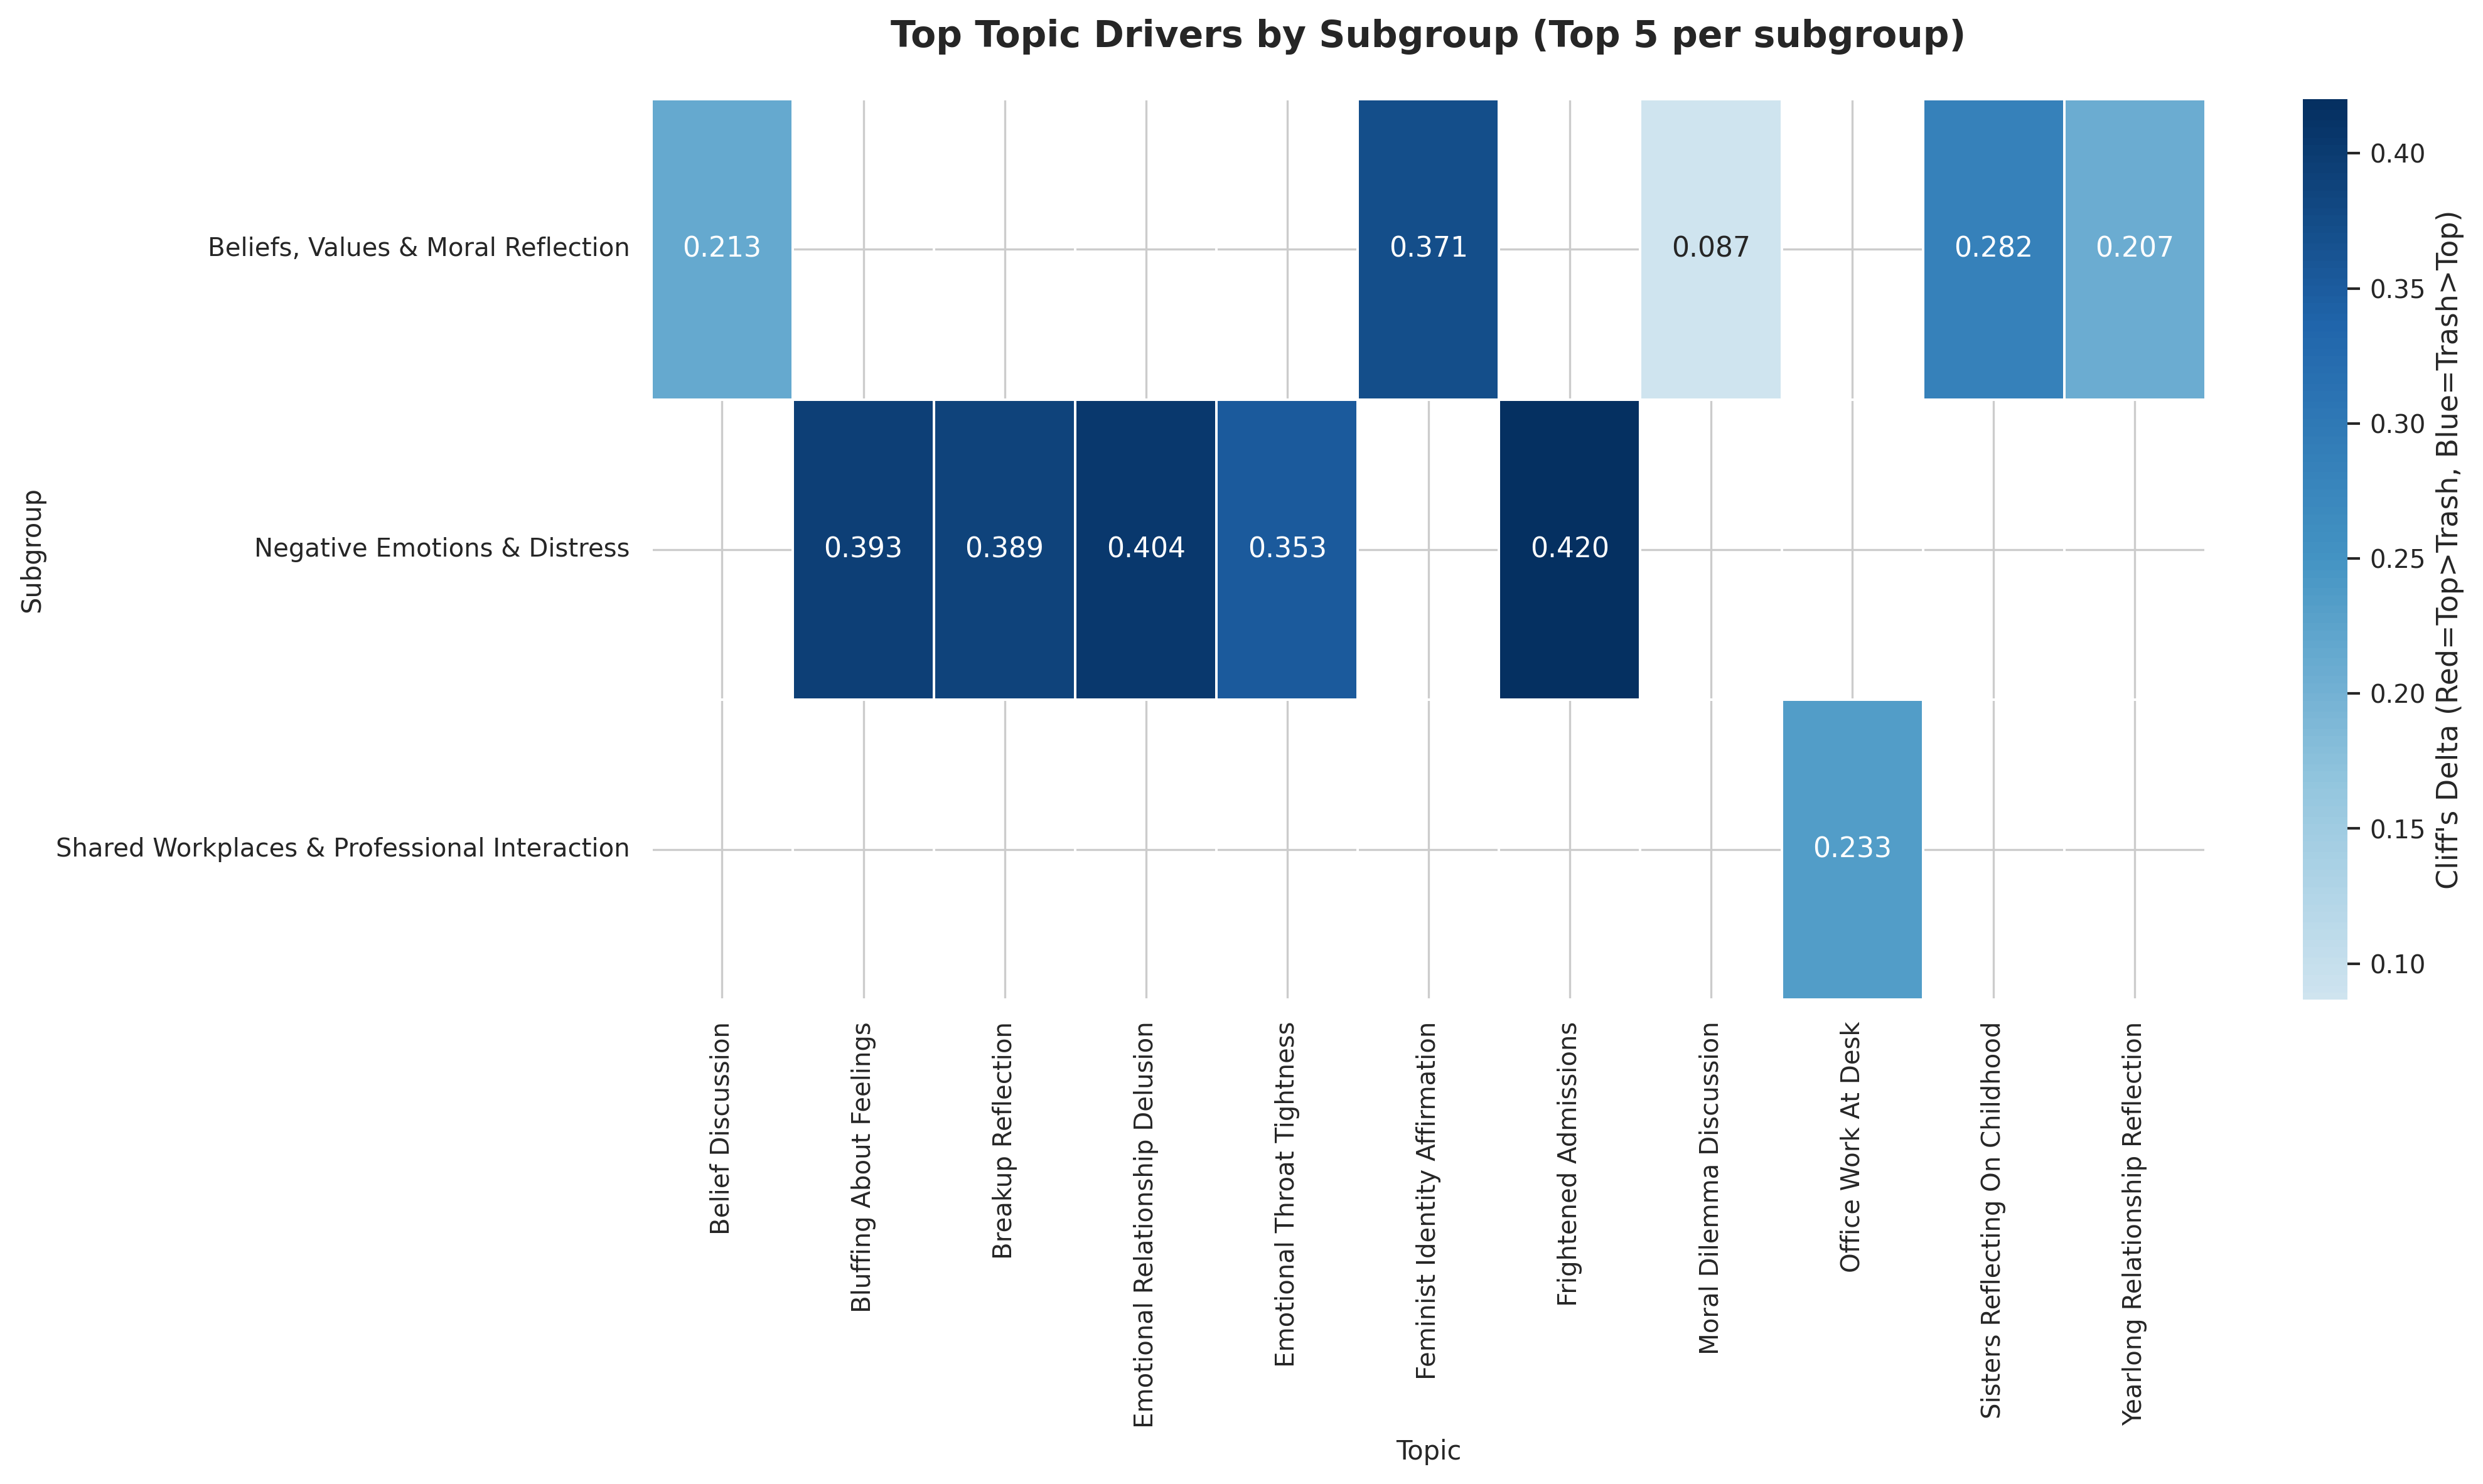


✓ Saved topic driver visualizations to: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/02_taxonomy_group_analysis/figures/topic_drivers


In [89]:
# Create topic drivers visualizations
# Try to load topic_drivers_df from memory or from saved file
if 'topic_drivers_df' in locals() and len(topic_drivers_df) > 0:
    topic_drivers_df_vis = topic_drivers_df
elif 'topic_drivers_df' in globals() and len(topic_drivers_df) > 0:
    topic_drivers_df_vis = topic_drivers_df
else:
    # Load from saved file
    topic_drivers_path = TABLE_DIR / "subgroup_topic_drivers.parquet"
    if topic_drivers_path.exists():
        topic_drivers_df_vis = pd.read_parquet(topic_drivers_path)
        print(f"✓ Loaded topic_drivers_df from {topic_drivers_path}")
    else:
        topic_drivers_df_vis = None
        print("⚠️  topic_drivers_df not available and file not found")

if topic_drivers_df_vis is not None and len(topic_drivers_df_vis) > 0:
    # Create figure directory for topic driver plots
    TOPIC_DRIVERS_FIG_DIR = FIG_DIR / "topic_drivers"
    TOPIC_DRIVERS_FIG_DIR.mkdir(parents=True, exist_ok=True)
    
    # 1. Bar chart showing top 10 topic drivers by subgroup
    for subgroup_name in topic_drivers_df_vis['taxonomy_main_name'].unique():
        subgroup_data = topic_drivers_df_vis[topic_drivers_df_vis['taxonomy_main_name'] == subgroup_name].head(10)
        
        if len(subgroup_data) > 0:
            main_group = subgroup_data['taxonomy_main_group'].iloc[0]
            
            # Create horizontal bar chart
            fig = px.bar(
                subgroup_data.sort_values('abs_cliffs_top_trash', ascending=True),
                x='abs_cliffs_top_trash',
                y='label',
                orientation='h',
                title=f'Top Topic Drivers: {subgroup_name}<br><sub>{main_group}</sub>',
                labels={'abs_cliffs_top_trash': "|Cliff's Delta| (Top vs Trash)", 'label': 'Topic'},
                color='cliffs_top_trash',
                color_continuous_scale='RdBu',
                color_continuous_midpoint=0
            )
            fig.update_layout(height=max(400, len(subgroup_data) * 40), showlegend=False)
            fig.show()
            
            # Save
            safe_name = "".join(c if c.isalnum() or c in (' ', '-', '_') else '_' for c in subgroup_name)[:50]
            fig.write_html(str(TOPIC_DRIVERS_FIG_DIR / f"topic_drivers_{safe_name}.html"))
    
    # 2. Summary heatmap: top 5 drivers per subgroup
    summary_data = []
    for subgroup_name in topic_drivers_df_vis['taxonomy_main_name'].unique():
        subgroup_data = topic_drivers_df_vis[topic_drivers_df_vis['taxonomy_main_name'] == subgroup_name].head(5)
        main_group = subgroup_data['taxonomy_main_group'].iloc[0]
        
        for _, row in subgroup_data.iterrows():
            summary_data.append({
                'Main Group': main_group,
                'Subgroup': subgroup_name,
                'Topic': row.get('label', 'N/A'),
                "Cliff's Delta": row.get('cliffs_top_trash', np.nan)
            })
    
    if len(summary_data) > 0:
        summary_df = pd.DataFrame(summary_data)
        
        # Create pivot for heatmap (subgroup x topic)
        pivot_summary = summary_df.pivot_table(
            index='Subgroup',
            columns='Topic',
            values="Cliff's Delta",
            aggfunc='first'
        )
        
        if len(pivot_summary) > 0 and len(pivot_summary.columns) > 0:
            # Matplotlib heatmap
            fig, ax = plt.subplots(figsize=(max(14, len(pivot_summary.columns) * 0.5), 
                                            max(8, len(pivot_summary) * 0.5)))
            sns.heatmap(pivot_summary, annot=True, fmt='.3f', cmap='RdBu', center=0,
                       cbar_kws={'label': "Cliff's Delta (Red=Top>Trash, Blue=Trash>Top)"},
                       ax=ax, linewidths=0.5)
            ax.set_title("Top Topic Drivers by Subgroup (Top 5 per subgroup)", 
                        fontsize=14, fontweight='bold', pad=20)
            ax.set_xlabel('Topic', fontsize=10)
            ax.set_ylabel('Subgroup', fontsize=10)
            plt.tight_layout()
            plt.savefig(TOPIC_DRIVERS_FIG_DIR / "topic_drivers_summary_heatmap.png", 
                       dpi=300, bbox_inches='tight')
            plt.show()
    
    # 3. Scatter plot: Cliff's Delta vs Prevalence
    if 'prevalence' in topic_drivers_df_vis.columns:
        fig_scatter = px.scatter(
            topic_drivers_df_vis,
            x='prevalence',
            y='cliffs_top_trash',
            color='taxonomy_main_name',
            size='abs_cliffs_top_trash',
            hover_data=['label', 'taxonomy_main_group'],
            title="Topic Drivers: Cliff's Delta vs Prevalence",
            labels={
                'prevalence': 'Prevalence',
                'cliffs_top_trash': "Cliff's Delta (Top vs Trash)",
                'taxonomy_main_name': 'Subgroup'
            }
        )
        fig_scatter.update_layout(height=600)
        fig_scatter.show()
        fig_scatter.write_html(str(TOPIC_DRIVERS_FIG_DIR / "topic_drivers_scatter.html"))
    
    print(f"\n✓ Saved topic driver visualizations to: {TOPIC_DRIVERS_FIG_DIR}")
else:
    print("⚠️  topic_drivers_df not available for visualization")

## 12. Subgroup Statistical Comparisons

**Statistical Procedure**: Same as main groups, but applied to subgroups within each main group. Within-group normalization allows us to identify which specific subgroups drive differences within each main category.


In [90]:
import warnings

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    print("=" * 80)
    print("Subgroup-within-Group Comparisons:")
    print("=" * 80)

    def plot_subgroup_panel(main_group: str, df: pd.DataFrame, save_dir: Path, show_plot=True):
        """Create small multiples panel of subgroup distributions."""
        group_data = df[df['taxonomy_main_group'] == main_group].copy()

        if len(group_data) == 0:
            return None

        subgroups = sorted(group_data['taxonomy_main_name'].dropna().unique())
        n_subgroups = len(subgroups)

        if n_subgroups == 0:
            return None

        # Create subplots
        n_cols = min(3, n_subgroups)
        n_rows = int(np.ceil(n_subgroups / n_cols))

        fig = make_subplots(
            rows=n_rows,
            cols=n_cols,
            subplot_titles=subgroups,
            vertical_spacing=0.15,
            horizontal_spacing=0.1
        )

        tiers = ['top', 'middle', 'trash']
        colors = ['rgb(31, 119, 180)', 'rgb(255, 127, 14)', 'rgb(44, 160, 44)']

        for idx, subgroup in enumerate(subgroups):
            row = (idx // n_cols) + 1
            col = (idx % n_cols) + 1

            subgroup_data = group_data[group_data['taxonomy_main_name'] == subgroup]

            for tier, color in zip(tiers, colors):
                tier_data = subgroup_data[subgroup_data['rating_tier'] == tier]['within_group_share']
                if len(tier_data) > 0:
                    fig.add_trace(
                        go.Violin(
                            y=tier_data,
                            name=tier,
                            box_visible=True,
                            meanline_visible=True,
                            showlegend=(idx == 0),
                            fillcolor=f"rgba({color.replace('rgb(', '').replace(')', '')}, 0.6)",
                            line_color=color,
                            opacity=0.7
                        ),
                        row=row,
                        col=col
                    )

        fig.update_layout(
            title=f"Subgroup Distributions: {main_group}",
            height=300 * n_rows,
            showlegend=True
        )

        safe_name = "".join(c if c.isalnum() or c in (' ', '-', '_') else '_' for c in main_group)[:50]
        html_path = save_dir / f"subgroup_panel_{safe_name}.html"
        fig.write_html(str(html_path))
        
        if show_plot:
            fig.show()

        return fig

    results_subgroup = []

    for main_group in main_groups:
        group_data = book_subgroup_shares[
            book_subgroup_shares['taxonomy_main_group'] == main_group
        ].copy()

        if len(group_data) == 0:
            continue

        subgroups = sorted(group_data['taxonomy_main_name'].dropna().unique())
        print(f"\n{main_group}: {len(subgroups)} subgroups")

        # Create panel plot
        plot_subgroup_panel(main_group, book_subgroup_shares, SUBGROUP_FIG_DIR, show_plot=True)

        # Analyze each subgroup
        for subgroup in subgroups:
            sub_data = group_data[group_data['taxonomy_main_name'] == subgroup]

            # Extract data by tier (handle both 'top'/'good', 'middle'/'mid', 'trash'/'bad')
            top_data = sub_data[sub_data['rating_tier'].isin(['top', 'good'])]['within_group_share'].values
            middle_data = sub_data[sub_data['rating_tier'].isin(['middle', 'mid'])]['within_group_share'].values
            trash_data = sub_data[sub_data['rating_tier'].isin(['trash', 'bad'])]['within_group_share'].values
            middle_data = sub_data[sub_data['rating_tier'] == 'middle']['within_group_share'].values
            trash_data = sub_data[sub_data['rating_tier'] == 'trash']['within_group_share'].values

            # Kruskal-Wallis
            kruskal_stat = np.nan
            kruskal_p = np.nan
            epsilon_sq = np.nan

            all_tiers = []
            for tier_data in [top_data, middle_data, trash_data]:
                if len(tier_data) > 0:
                    all_tiers.append(tier_data)

            if len(all_tiers) >= 2:
                try:
                    kruskal_stat, kruskal_p = kruskal(*all_tiers)
                    n_total = len(top_data) + len(middle_data) + len(trash_data)
                    epsilon_sq = compute_epsilon_squared(kruskal_stat, n_total, 3)
                except:
                    pass

            # Pairwise comparisons
            top_trash_delta = np.nan
            top_trash_p = np.nan
            if len(top_data) > 0 and len(trash_data) > 0:
                try:
                    _, top_trash_p = mannwhitneyu(top_data, trash_data, alternative='two-sided')
                    top_trash_delta = cliffs_delta(top_data, trash_data)
                except:
                    pass

            result = {
                'taxonomy_main_group': main_group,
                'taxonomy_main_name': subgroup,
                'n_books': len(sub_data),
                'top_median': np.median(top_data) if len(top_data) > 0 else np.nan,
                'top_mean': np.mean(top_data) if len(top_data) > 0 else np.nan,
                'middle_median': np.median(middle_data) if len(middle_data) > 0 else np.nan,
                'middle_mean': np.mean(middle_data) if len(middle_data) > 0 else np.nan,
                'trash_median': np.median(trash_data) if len(trash_data) > 0 else np.nan,
                'trash_mean': np.mean(trash_data) if len(trash_data) > 0 else np.nan,
                'kruskal_stat': kruskal_stat,
                'kruskal_p': kruskal_p,
                'epsilon_squared': epsilon_sq,
                'top_vs_trash_delta': top_trash_delta,
                'top_vs_trash_p': top_trash_p,
            }

            results_subgroup.append(result)

            if not np.isnan(kruskal_p) and kruskal_p < 0.05:
                print(f"  ✓ {subgroup}: KW p={kruskal_p:.4f}, δ={top_trash_delta:.3f}")

    # Family-wise Holm correction: adjust within each taxonomy_main_group
    subgroup_results = pd.DataFrame(results_subgroup)

    def holm_within_group(df, pcol, outcol):
        """Apply Holm correction within a group (family-wise)."""
        p = df[pcol].values
        ok = ~np.isnan(p)
        df[outcol] = np.nan
        if ok.sum() > 0:
            df.loc[ok, outcol] = multipletests(p[ok], method='holm', alpha=0.05)[1]
        return df

    # Apply family-wise adjustment for Kruskal-Wallis p-values
    subgroup_results = subgroup_results.groupby('taxonomy_main_group', group_keys=False).apply(
        lambda g: holm_within_group(g, 'kruskal_p', 'kruskal_p_adj_family')
    )

    # Also adjust pairwise MW p-values within family
    for pcol in ['top_vs_trash_p', 'top_vs_middle_p', 'middle_vs_trash_p']:
        if pcol in subgroup_results.columns:
            subgroup_results = subgroup_results.groupby('taxonomy_main_group', group_keys=False).apply(
                lambda g: holm_within_group(g, pcol, f"{pcol}_adj_family")
            )

    # Save results (both CSV and Parquet)
    subgroup_results.to_parquet(TABLE_DIR / "subgroup_comparisons.parquet", index=False)
    subgroup_results.to_csv(TABLE_DIR / "subgroup_comparisons.csv", index=False)

    print(f"\n✓ Saved subgroup comparison results to: {TABLE_DIR / 'subgroup_comparisons.parquet'}")
    print(f"\nSignificant subgroups (family-wise adjusted p < 0.05):")
    sig_subgroups = subgroup_results[subgroup_results['kruskal_p_adj_family'] < 0.05].sort_values('kruskal_p_adj_family')
    if len(sig_subgroups) > 0:
        display(sig_subgroups[['taxonomy_main_group', 'taxonomy_main_name', 'kruskal_p', 'kruskal_p_adj_family',
                                 'top_vs_trash_delta', 'top_median', 'trash_median']])
    else:
        print("  (None found with family-wise adjusted p < 0.05)")
        
    print(f"\nSignificant subgroups (raw p < 0.05, for reference):")
    sig_subgroups_raw = subgroup_results[subgroup_results['kruskal_p'] < 0.05].sort_values('kruskal_p')
    if len(sig_subgroups_raw) > 0:
        display(sig_subgroups_raw[['taxonomy_main_group', 'taxonomy_main_name', 'kruskal_p', 'kruskal_p_adj_family',
                                     'top_vs_trash_delta', 'top_median', 'trash_median']])
    else:
        print("  (None found)")

Subgroup-within-Group Comparisons:

Conflict, Risk & Harm: 2 subgroups



Embodied & Sensory Experience: 2 subgroups



Emotions, Cognition & Inner Life: 4 subgroups


  ✓ Beliefs, Values & Moral Reflection: KW p=0.0048, δ=0.464
  ✓ Negative Emotions & Distress: KW p=0.0432, δ=-0.369

Relationship Trajectory (Main Couple): 5 subgroups



Sexuality, Attraction & Intimacy: 3 subgroups


...


Work, Wealth, Status & Institutions: 5 subgroups


  ✓ Shared Workplaces & Professional Interaction: KW p=0.0451, δ=0.349

✓ Saved subgroup comparison results to: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/02_taxonomy_group_analysis/tables_csv/subgroup_comparisons.parquet

Significant subgroups (family-wise adjusted p < 0.05):


,taxonomy_main_group,taxonomy_main_name,kruskal_p,kruskal_p_adj_family,top_vs_trash_delta,top_median,trash_median
5,"Emotions, Cognition & Inner Life","Beliefs, Values & Moral Reflection",0.004809,0.019236,0.464444,0.132924,0.119401



Significant subgroups (raw p < 0.05, for reference):


,taxonomy_main_group,taxonomy_main_name,kruskal_p,kruskal_p_adj_family,top_vs_trash_delta,top_median,trash_median
5,"Emotions, Cognition & Inner Life","Beliefs, Values & Moral Reflection",0.004809,0.019236,0.464444,0.132924,0.119401
6,"Emotions, Cognition & Inner Life",Negative Emotions & Distress,0.043238,0.129714,-0.368889,0.558267,0.583233
26,"Work, Wealth, Status & Institutions",Shared Workplaces & Professional Interaction,0.045106,0.225532,0.348889,0.058119,0.047205


## 13. Subgroup Effect Size Heatmap

Create a heatmap visualization showing effect sizes (Cliff's Delta) for all subgroup comparisons, making it easy to identify which subgroups show the strongest differences between Top and Trash tiers.


subgroup_results shape: (27, 16)
Columns in subgroup_results: ['taxonomy_main_group', 'taxonomy_main_name', 'n_books', 'top_median', 'top_mean', 'middle_median', 'middle_mean', 'trash_median', 'trash_mean', 'kruskal_stat', 'kruskal_p', 'epsilon_squared', 'top_vs_trash_delta', 'top_vs_trash_p', 'kruskal_p_adj_family', 'top_vs_trash_p_adj_family']
Non-NaN top_vs_trash_delta values: 27 out of 27


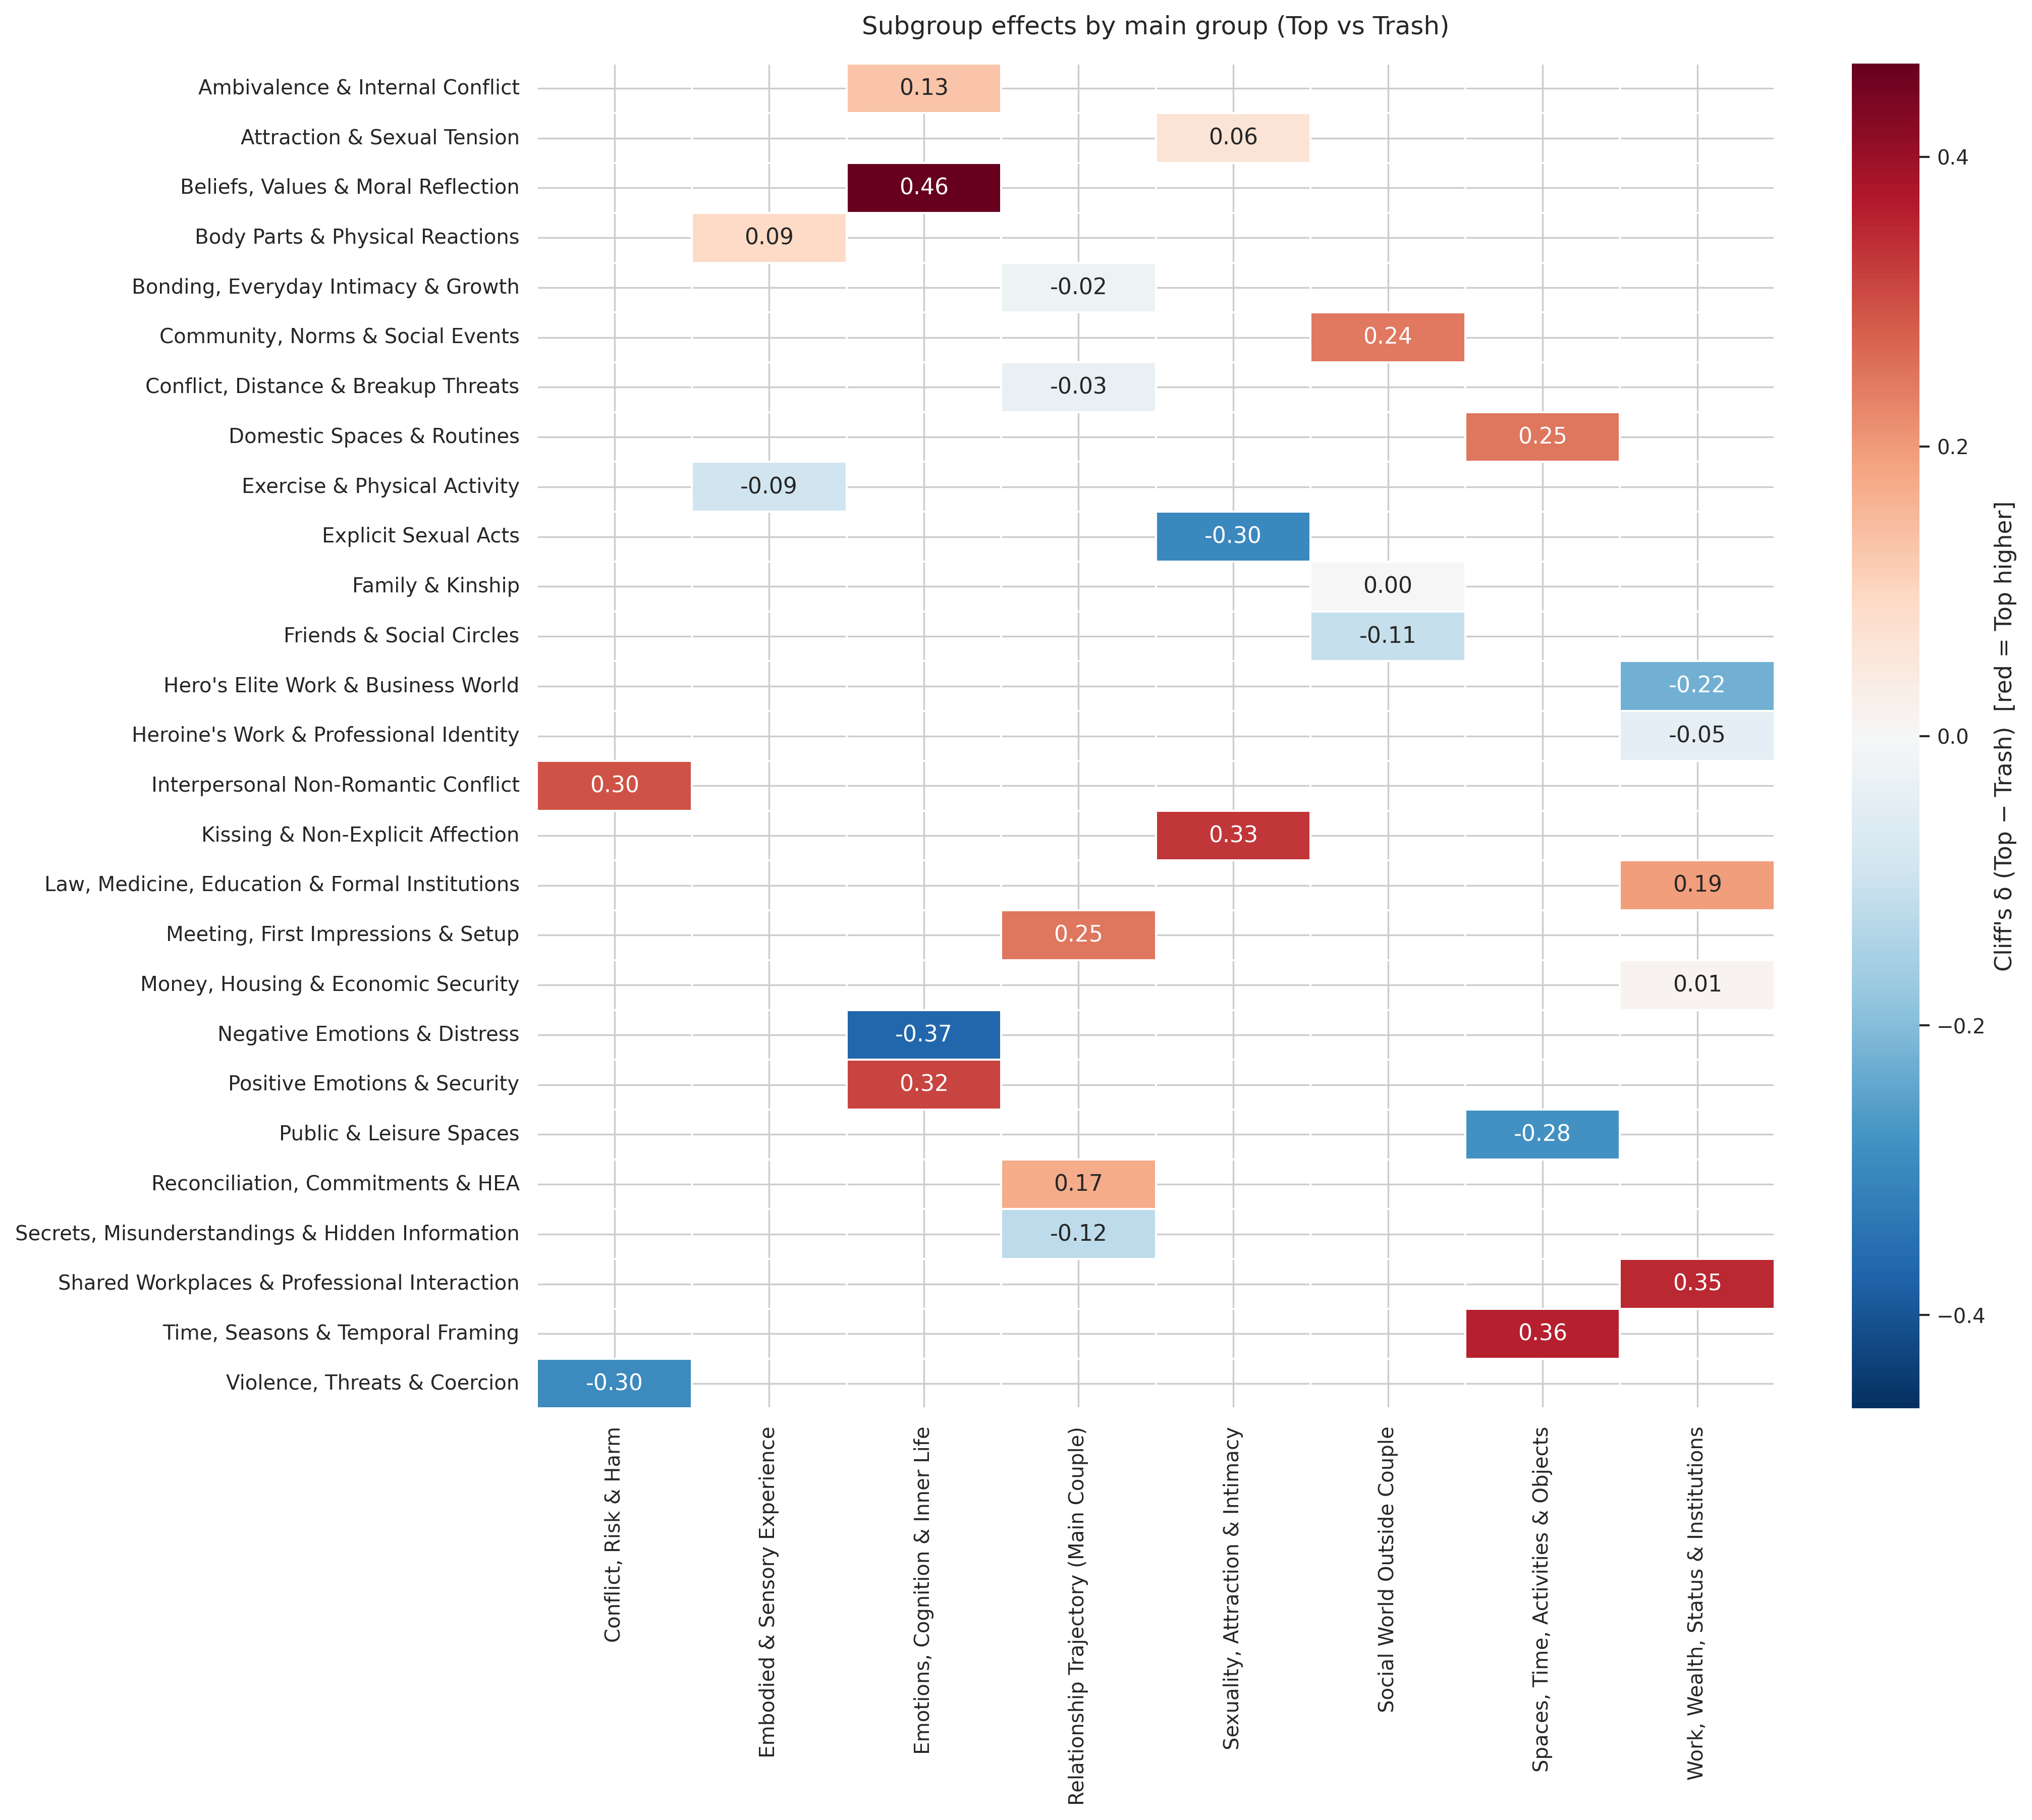

<Figure size 960x720 with 0 Axes>

In [91]:
# Diagnostic: Check subgroup_results structure
try:
    print(f"subgroup_results shape: {subgroup_results.shape}")
    print(f"Columns in subgroup_results: {list(subgroup_results.columns)}")
    if 'top_vs_trash_delta' in subgroup_results.columns:
        non_nan_count = subgroup_results['top_vs_trash_delta'].notna().sum()
        print(f"Non-NaN top_vs_trash_delta values: {non_nan_count} out of {len(subgroup_results)}")
        if non_nan_count == 0:
            print("\nSample of subgroup_results (first 5 rows):")
            print(subgroup_results[['taxonomy_main_group', 'taxonomy_main_name', 'top_vs_trash_delta', 'kruskal_p']].head())
    else:
        print("ERROR: 'top_vs_trash_delta' column not found in subgroup_results")
        print("Available columns:", list(subgroup_results.columns))
except NameError:
    print("ERROR: subgroup_results is not defined. Make sure you've run the previous cell that creates it.")
except Exception as e:
    print(f"Error checking subgroup_results: {e}")

# Prepare data for heatmap
heatmap_data = []
try:
    for _, row in subgroup_results.iterrows():
        if 'top_vs_trash_delta' in row and not np.isnan(row['top_vs_trash_delta']):
            heatmap_data.append({
                'Main Group': row['taxonomy_main_group'],
                'Subgroup': row['taxonomy_main_name'],
                "Cliff's Delta": row['top_vs_trash_delta'],
                'p-value': row['kruskal_p']
            })
except NameError:
    print("ERROR: subgroup_results is not defined. Cannot create heatmap.")
except Exception as e:
    print(f"Error processing subgroup_results: {e}")

heatmap_df = pd.DataFrame(heatmap_data)

# Check if we have data before pivoting
if len(heatmap_data) == 0:
    print("\nWarning: No data available for heatmap (all top_vs_trash_delta values are NaN)")
    print("Skipping heatmap creation.")
else:
    # Create pivot table for heatmap
    pivot_data = heatmap_df.pivot(index="Subgroup", columns="Main Group", values="Cliff's Delta")

    # Symmetric normalization (critical for consistent color semantics)
    norm, lim = symmetric_norm(pivot_data.values.flatten(), fallback=0.35)

    # Create heatmap
    fig, ax = plt.subplots(figsize=(14, max(8, len(pivot_data) * 0.45)))
    sns.heatmap(
        pivot_data,
        cmap=EFFECT_CMAP_MPL,
        norm=norm,
        annot=True,
        fmt=".2f",
        linewidths=0.5,
        cbar_kws={"label": "Cliff's δ (Top − Trash)  [red = Top higher]"},
        ax=ax,
    )
    ax.set_title("Subgroup effects by main group (Top vs Trash)", pad=14)
    ax.set_xlabel("")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()

    # Save
    plt.savefig(SUBGROUP_FIG_DIR / "subgroup_effect_sizes_heatmap.png", bbox_inches="tight")
    plt.savefig(SUBGROUP_FIG_DIR / "subgroup_effect_sizes_heatmap.pdf", bbox_inches="tight")

    # Also create interactive version (for appendix/interactive use)
    # Use imshow for correct color semantics (no aggregation)
    fig_heatmap = px.imshow(
        pivot_data,
        color_continuous_scale=EFFECT_CMAP_PLOTLY,
        zmin=-lim,
        zmax=lim,
        title="Subgroup effects by main group (Top vs Trash)",
        labels={"color": "Cliff's δ (Top − Trash)"},
    )
    fig_heatmap.update_layout(coloraxis_colorbar=dict(title="Cliff's δ (Top − Trash)"))
    fig_heatmap.update_layout(height=max(600, len(pivot_data) * 30))
    fig_heatmap.show()
    fig_heatmap.write_html(str(SUBGROUP_FIG_DIR / "subgroup_effect_sizes_heatmap.html"))

## 14. Topic Driver Ranking for Significant Subgroups

For subgroups showing significant tier differences, identify the specific topics driving those differences by ranking topics by their Top-Trash Cliff's Delta within each significant subgroup.


In [92]:
print("=" * 80)
print("Topic Driver Ranking for Significant Subgroups:")
print("=" * 80)

# Define TOPIC_TABLES_DIR to point to 01_topic_analysis tables
TOPIC_TABLES_DIR = RESULTS_DIR / "stage10_correlation_analysis" / "01_topic_analysis" / "tables_csv"

# Load topic-level statistics for Cliff's delta
topic_stats_path = TOPIC_TABLES_DIR / "topic_leaderboard_all.parquet"
if topic_stats_path.exists():
    topic_stats = pd.read_parquet(topic_stats_path)
    print(f"✓ Loaded topic statistics: {topic_stats.shape}")
    print(f"  Columns in topic_stats: {list(topic_stats.columns)[:10]}...")  # Show first 10 columns
else:
    print(f"⚠️  topic_leaderboard_all.parquet not found. Skipping topic driver analysis.")
    topic_stats = None

if topic_stats is not None:
    # Check if topic_stats already has taxonomy columns (it should from topic_leaderboard_all)
    has_taxonomy_in_stats = 'taxonomy_main_group' in topic_stats.columns and 'taxonomy_main_name' in topic_stats.columns
    
    if has_taxonomy_in_stats:
        print("✓ Taxonomy columns found in topic_stats, using them directly")
        topic_drivers_all = topic_stats.copy()
        
        # Still need to check if author_dominance_flag and gate3_pass are present
        # These might not be in topic_leaderboard_all
        if 'author_dominance_flag' not in topic_drivers_all.columns or 'gate3_pass' not in topic_drivers_all.columns:
            additional_cols = []
            if 'author_dominance_flag' not in topic_drivers_all.columns and 'author_dominance_flag' in mapping_export.columns:
                additional_cols.append('author_dominance_flag')
            if 'gate3_pass' not in topic_drivers_all.columns and 'gate3_pass' in mapping_export.columns:
                additional_cols.append('gate3_pass')
            
            if additional_cols:
                print(f"  Merging additional columns from mapping_export: {additional_cols}")
                topic_drivers_all = topic_drivers_all.merge(
                    mapping_export[['topic_id'] + additional_cols],
                    on='topic_id',
                    how='left'
                )
    else:
        print("⚠️  Taxonomy columns not in topic_stats, merging from mapping_export")
        # Merge topic stats with mapping to get taxonomy info
        taxonomy_cols = []
        for col in ['taxonomy_main_group', 'taxonomy_main_name']:
            if col in mapping_export.columns:
                taxonomy_cols.append(col)
            else:
                print(f"⚠️  Expected taxonomy column '{col}' not found in mapping_export.")
        
        export_cols = ['topic_id', 'author_dominance_flag', 'label', 'keywords', 'scene_summary', 'gate3_pass']
        export_cols = [col for col in export_cols if col in mapping_export.columns]
        merge_cols = ['topic_id'] + taxonomy_cols + [c for c in export_cols if c != 'topic_id']
        
        topic_drivers_all = topic_stats.merge(
            mapping_export[merge_cols],
            on='topic_id',
            how='left'
        )
        print(f"  After merge: taxonomy_main_group in columns = {'taxonomy_main_group' in topic_drivers_all.columns}")
        print(f"  After merge: taxonomy_main_name in columns = {'taxonomy_main_name' in topic_drivers_all.columns}")
    
    # If taxonomy columns weren't in topic_stats, we might need to merge author_dominance_flag and gate3_pass
    if not has_taxonomy_in_stats:
        # Check if we need to merge author_dominance_flag and gate3_pass
        if 'author_dominance_flag' not in topic_drivers_all.columns or 'gate3_pass' not in topic_drivers_all.columns:
            additional_cols = []
            if 'author_dominance_flag' not in topic_drivers_all.columns and 'author_dominance_flag' in mapping_export.columns:
                additional_cols.append('author_dominance_flag')
            if 'gate3_pass' not in topic_drivers_all.columns and 'gate3_pass' in mapping_export.columns:
                additional_cols.append('gate3_pass')
            
            if additional_cols:
                topic_drivers_all = topic_drivers_all.merge(
                    mapping_export[['topic_id'] + additional_cols],
                    on='topic_id',
                    how='left'
                )
    
    # Filter to Gate 3 passing topics (strict criteria for inference: prevalence >= 0.10 AND NOT author-dominant)
    # NOTE: This is separate from composition analysis (which keeps long-tail topics)
    if 'gate3_pass' in topic_drivers_all.columns and 'author_dominance_flag' in topic_drivers_all.columns:
        topic_drivers_all = topic_drivers_all[
            (topic_drivers_all['author_dominance_flag'] != 'high') &
            (topic_drivers_all['gate3_pass'].fillna(False))
        ]
    elif 'author_dominance_flag' in topic_drivers_all.columns:
        # If gate3_pass not available, just filter author-dominant
        topic_drivers_all = topic_drivers_all[
            (topic_drivers_all['author_dominance_flag'] != 'high')
        ]
    # If neither is available, keep all topics (but warn)
    else:
        print("⚠️  Warning: author_dominance_flag not found, keeping all topics")
    
    print(f"  After filtering: {len(topic_drivers_all)} topics")
    print(f"  Taxonomy columns present: taxonomy_main_group={'taxonomy_main_group' in topic_drivers_all.columns}, "
          f"taxonomy_main_name={'taxonomy_main_name' in topic_drivers_all.columns}")
    
    # Get significant subgroups
    sig_subgroups = subgroup_results[
        (subgroup_results['kruskal_p'] < 0.05) &
        (subgroup_results['kruskal_p'].notna())
    ].copy()
    
    if not all(col in sig_subgroups.columns for col in ['taxonomy_main_group', 'taxonomy_main_name']):
        print("⚠️  'taxonomy_main_group' and/or 'taxonomy_main_name' missing in subgroup_results. Skipping topic driver analysis.")
    else:
        print(f"\nAnalyzing {len(sig_subgroups)} significant subgroups:")
        
        topic_driver_results = []
        
        for _, sub_row in sig_subgroups.iterrows():
            main_group = sub_row.get('taxonomy_main_group', None)
            subgroup = sub_row.get('taxonomy_main_name', None)
            
            if main_group is None or subgroup is None:
                continue
            
            has_main_group = 'taxonomy_main_group' in topic_drivers_all.columns
            has_main_name = 'taxonomy_main_name' in topic_drivers_all.columns
            
            if not has_main_group or not has_main_name:
                print(f"⚠️  taxonomy columns not found in topic_drivers_all; skipping subgroup ({main_group}, {subgroup})")
                continue
            
            subgroup_topics = topic_drivers_all[
                (topic_drivers_all['taxonomy_main_group'] == main_group) &
                (topic_drivers_all['taxonomy_main_name'] == subgroup)
            ].copy()
            
            if len(subgroup_topics) == 0:
                continue
            
            # Rank by absolute Cliff's delta (Top vs Trash)
            if 'cliffs_top_trash' in subgroup_topics.columns:
                subgroup_topics['abs_cliffs_top_trash'] = subgroup_topics['cliffs_top_trash'].abs()
                subgroup_topics = subgroup_topics.sort_values('abs_cliffs_top_trash', ascending=False)
                
                # Keep top 15 drivers
                top_drivers = subgroup_topics.head(15)
                
                print(f"\n{subgroup} ({main_group}):")
                print(f"  Total topics: {len(subgroup_topics)}")
                print(f"  Top 5 drivers:")
                for idx, (_, topic_row) in enumerate(top_drivers.head(5).iterrows(), 1):
                    delta_val = topic_row.get('cliffs_top_trash', np.nan)
                    mass_val = topic_row.get('mass', np.nan)
                    print(f"    {idx}. {topic_row.get('label', 'N/A')}: δ={delta_val:.3f}, "
                          f"mass={mass_val:.4f}, "
                          f"author_dom={topic_row.get('author_dominance_flag', 'N/A')}")
                
                # Store results
                for _, topic_row in top_drivers.iterrows():
                    topic_driver_results.append({
                        'taxonomy_main_group': main_group,
                        'taxonomy_main_name': subgroup,
                        'topic_id': topic_row.get('topic_id', np.nan),
                        'label': topic_row.get('label', ''),
                        'cliffs_top_trash': topic_row.get('cliffs_top_trash', np.nan),
                        'abs_cliffs_top_trash': topic_row.get('abs_cliffs_top_trash', np.nan),
                        'top_median': topic_row.get('top_median', np.nan),
                        'trash_median': topic_row.get('trash_median', np.nan),
                        'prevalence': topic_row.get('prevalence', np.nan),
                        'mass': topic_row.get('mass', np.nan),
                        'author_dominance_flag': topic_row.get('author_dominance_flag', ''),
                        'keywords': topic_row.get('keywords', ''),
                        'scene_summary': topic_row.get('scene_summary', ''),
                    })
        
        # Create DataFrame
        topic_drivers_df = pd.DataFrame(topic_driver_results)
        
        # Save
        if len(topic_drivers_df) > 0:
            topic_drivers_df.to_csv(TABLE_DIR / "subgroup_topic_drivers.csv", index=False)
            topic_drivers_df.to_csv(TABLE_DIR / "subgroup_topic_drivers.csv", index=False)
            print(f"\n✓ Saved topic drivers to: {TABLE_DIR / 'subgroup_topic_drivers.parquet'}")
            
            # Display top drivers
            print("\nTop topic drivers by subgroup:")
            display(topic_drivers_df.head(20))
        else:
            print("\n⚠️  No topic drivers found")
else:
    print("\n⚠️  Skipping topic driver analysis (topic_stats not available)")

Topic Driver Ranking for Significant Subgroups:
✓ Loaded topic statistics: (342, 56)
  Columns in topic_stats: ['topic_id', 'label', 'top_n', 'top_mean', 'top_median', 'top_q1', 'top_q3', 'top_std', 'middle_n', 'middle_mean']...
✓ Taxonomy columns found in topic_stats, using them directly
  Merging additional columns from mapping_export: ['gate3_pass']
⚠️  Warning: author_dominance_flag not found, keeping all topics
  After filtering: 342 topics
  Taxonomy columns present: taxonomy_main_group=True, taxonomy_main_name=True

Analyzing 3 significant subgroups:

Beliefs, Values & Moral Reflection (Emotions, Cognition & Inner Life):
  Total topics: 6
  Top 5 drivers:
    1. Feminist Identity Affirmation: δ=0.371, mass=0.0026, author_dom=N/A
    2. Sisters Reflecting On Childhood: δ=0.282, mass=0.0056, author_dom=N/A
    3. Belief Discussion: δ=0.213, mass=0.0059, author_dom=N/A
    4. Yearlong Relationship Reflection: δ=0.207, mass=0.0046, author_dom=N/A
    5. Moral Dilemma Discussion: δ=0

,taxonomy_main_group,taxonomy_main_name,topic_id,label,cliffs_top_trash,abs_cliffs_top_trash,top_median,trash_median,prevalence,mass,author_dominance_flag,keywords,scene_summary
0,"Emotions, Cognition & Inner Life","Beliefs, Values & Moral Reflection",310,Feminist Identity Affirmation,0.371111,0.371111,0.002584,0.002217,1.000000,0.002550,,"foremost, tend, feminine, ama, ladies, feminis...",She asserts her identity and purpose as a woman.
1,"Emotions, Cognition & Inner Life","Beliefs, Values & Moral Reflection",350,Sisters Reflecting On Childhood,0.282222,0.282222,0.005952,0.004934,1.000000,0.005644,,"didn, wasn, won, sell, childhood, months, guar...","The sisters sit together, reflecting on their ..."
2,"Emotions, Cognition & Inner Life","Beliefs, Values & Moral Reflection",249,Belief Discussion,0.213333,0.213333,0.005969,0.005718,1.000000,0.005903,,"believe, admit, cana, expect, macka, validity,...",The couple discusses their beliefs in the garage.
3,"Emotions, Cognition & Inner Life","Beliefs, Values & Moral Reflection",311,Yearlong Relationship Reflection,0.206667,0.206667,0.004880,0.004257,1.000000,0.004630,,"wea, shared, downs, cycle, yearlong, created, ...","The couple, sitting at a table, reflects on th..."
4,"Emotions, Cognition & Inner Life","Beliefs, Values & Moral Reflection",314,Moral Dilemma Discussion,0.086667,0.086667,0.004020,0.004098,1.000000,0.003837,,"thing, proves, exactly, thinga, telegraphing, ...","The couple sits around the table, discussing a..."
5,"Emotions, Cognition & Inner Life","Beliefs, Values & Moral Reflection",219,Human Nature Reflection,-0.073333,0.073333,0.001140,0.001232,0.673913,0.001279,,"assignment, humans, course, actuality, picture...",She contemplates the complexities of human nat...
6,"Emotions, Cognition & Inner Life",Negative Emotions & Distress,82,Frightened Admissions,0.420000,0.420000,0.002294,0.001786,1.000000,0.002220,,"scared, afraid, sad, terrifying, scary, scare,...",She admits her fears and insecurities to him i...
7,"Emotions, Cognition & Inner Life",Negative Emotions & Distress,321,Emotional Relationship Delusion,0.404444,0.404444,0.002533,0.002061,0.978261,0.002775,,"cilliana, antidote, maine, evon, unlike, enter...",She struggles to understand her confusing feel...
8,"Emotions, Cognition & Inner Life",Negative Emotions & Distress,66,Bluffing About Feelings,0.393333,0.393333,0.000947,0.000804,0.206522,0.001682,,"didn, couldn, swallowed, glanced, nodded, hadn...",Abbey struggles to understand and express her ...
9,"Emotions, Cognition & Inner Life",Negative Emotions & Distress,197,Breakup Reflection,0.388889,0.388889,0.000351,0.000324,0.032609,0.000639,,"breakera, asks, closure, margaritas, refer, ru...","She sits alone, margarita in hand, reflecting ..."


## 15. Report-Ready Figures and Tables

Generate all figures and tables needed for Sections 2-3 of the report with proper naming conventions (C1, C2, T1, T2, S1a-S1h, Dk).

**Section 2 - Taxonomy-level structure:**
- Table C1: Coverage audit by tier
- Figure C1: Coverage distribution (other_share by tier)
- Figure C2: Diversity vs OTHER scatter
- Figure T1: Main group composition by tier
- Figure T2: Main group heatmap
- Figure S1a-S1h: Subgroup panels (one per main group)

**Section 3 - Within-subgroup drivers:**
- Table Dk: Driver topics per subgroup
- Figure Dk: Dot plots of driver topics


In [93]:
# Create report-ready outputs directory
REPORT_DIR = OUTPUT_DIR / "report_figures_tables"
REPORT_FIG_DIR = REPORT_DIR / "figures"
REPORT_TABLE_DIR = REPORT_DIR / "tables"
for d in [REPORT_DIR, REPORT_FIG_DIR, REPORT_TABLE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("=" * 80)
print("Generating Report-Ready Figures and Tables")
print("=" * 80)

# Load data if not in memory
if 'coverage_summary' not in locals():
    coverage_summary_path = TABLE_DIR / "coverage_audit_by_tier.parquet"
    if coverage_summary_path.exists():
        coverage_summary = pd.read_parquet(coverage_summary_path)
        print(f"✓ Loaded coverage_summary from {coverage_summary_path}")
    else:
        # Reconstruct from book_main_group_shares
        book_shares_path = TABLE_DIR / "book_main_group_shares.parquet"
        if book_shares_path.exists():
            book_shares = pd.read_parquet(book_shares_path)
            audit = book_shares[['book_id', 'rating_tier', 'other_share', 
                                 'paratext_share', 'noise_share', 'modeled_mass']].drop_duplicates()
            coverage_summary = audit.groupby('rating_tier')[['other_share', 'paratext_share', 
                                                             'noise_share', 'modeled_mass']].agg(['mean', 'median']).round(4)

if 'main_group_results' not in locals():
    main_group_results_path = TABLE_DIR / "main_group_comparisons.parquet"
    if main_group_results_path.exists():
        main_group_results = pd.read_parquet(main_group_results_path)
        print(f"✓ Loaded main_group_results from {main_group_results_path}")

if 'subgroup_results' not in locals():
    subgroup_results_path = TABLE_DIR / "subgroup_comparisons.parquet"
    if subgroup_results_path.exists():
        subgroup_results = pd.read_parquet(subgroup_results_path)
        print(f"✓ Loaded subgroup_results from {subgroup_results_path}")

if 'book_main_group_shares' not in locals():
    book_main_group_shares_path = TABLE_DIR / "book_main_group_shares.parquet"
    if book_main_group_shares_path.exists():
        book_main_group_shares = pd.read_parquet(book_main_group_shares_path)
        print(f"✓ Loaded book_main_group_shares from {book_main_group_shares_path}")

if 'book_subgroup_shares' not in locals():
    book_subgroup_shares_path = TABLE_DIR / "book_subgroup_shares.parquet"
    if book_subgroup_shares_path.exists():
        book_subgroup_shares = pd.read_parquet(book_subgroup_shares_path)
        print(f"✓ Loaded book_subgroup_shares from {book_subgroup_shares_path}")

    # Normalize rating_tier values: good->top, bad->trash, mid->middle
    tier_normalization_map = {'good': 'top', 'bad': 'trash', 'mid': 'middle'}
    if 'rating_tier' in book_subgroup_shares.columns:
        original_values = set(book_subgroup_shares['rating_tier'].dropna().unique())
        book_subgroup_shares['rating_tier'] = book_subgroup_shares['rating_tier'].map(
            lambda x: tier_normalization_map.get(x, x) if pd.notna(x) else x
        )
        normalized_values = set(book_subgroup_shares['rating_tier'].dropna().unique())
        if original_values != normalized_values:
            print(f"  ✓ Normalized rating_tier: {original_values} -> {normalized_values}")

    # Normalize rating_tier values: good->top, bad->trash, mid->middle
    tier_normalization_map = {'good': 'top', 'bad': 'trash', 'mid': 'middle'}
    if 'rating_tier' in book_subgroup_shares.columns:
        original_values = book_subgroup_shares['rating_tier'].unique()
        book_subgroup_shares['rating_tier'] = book_subgroup_shares['rating_tier'].map(
            lambda x: tier_normalization_map.get(x, x) if pd.notna(x) else x
        )
        normalized_values = book_subgroup_shares['rating_tier'].unique()
        if not all(v in ['top', 'middle', 'trash'] for v in normalized_values if pd.notna(v)):
            print(f"  ⚠️  Warning: Some rating_tier values not normalized: {normalized_values}")
        else:
            print(f"  ✓ Normalized rating_tier: {set(original_values)} -> {set(normalized_values)}")

if 'div_df' not in locals():
    div_df_path = TABLE_DIR / "diversity_metrics_by_book.parquet"
    if div_df_path.exists():
        div_df = pd.read_parquet(div_df_path)
        print(f"✓ Loaded div_df from {div_df_path}")

if 'topic_drivers_df' not in locals():
    topic_drivers_path = TABLE_DIR / "subgroup_topic_drivers.parquet"
    if topic_drivers_path.exists():
        topic_drivers_df = pd.read_parquet(topic_drivers_path)
        print(f"✓ Loaded topic_drivers_df from {topic_drivers_path}")

print("\n✓ All data loaded")

Generating Report-Ready Figures and Tables

✓ All data loaded


### Table C1: Coverage Audit by Tier

Export coverage summary table with mean/median for all coverage components.


In [94]:
# Table C1: Coverage Audit by Tier
if 'coverage_summary' in locals() and len(coverage_summary) > 0:
    # Ensure it has the right structure
    table_c1 = coverage_summary.copy()
    
    # Save as both CSV and Parquet
    table_c1.to_csv(REPORT_TABLE_DIR / "Table_C1_coverage_audit_by_tier.csv")
    table_c1.to_csv(REPORT_TABLE_DIR / "Table_C1_coverage_audit_by_tier.csv", index=False)
    
    print("✓ Table C1 saved: Coverage audit by tier")
    print(f"  Shape: {table_c1.shape}")
    display(table_c1)
else:
    print("⚠️  coverage_summary not available")

✓ Table C1 saved: Coverage audit by tier
  Shape: (3, 10)


other_share         paratext_share         noise_share          \
                   mean  median           mean  median        mean  median   
rating_tier                                                                  
trash            0.0015  0.0009         0.0019  0.0018      0.0010  0.0007   
top              0.0018  0.0010         0.0024  0.0016      0.0010  0.0008   
middle           0.0011  0.0009         0.0016  0.0015      0.0009  0.0007   

            unmapped_share         modeled_mass          
                      mean  median         mean  median  
rating_tier                                              
trash               0.0005  0.0001       0.9981  0.9982  
top                 0.0008  0.0001       0.9976  0.9984  
middle              0.0002  0.0001       0.9984  0.9985

### Figure C1: Coverage Distribution (other_share by tier)

Violin/box plot of other_share by tier with KW p-value and effect size annotation.


/tmp/ipykernel_117784/3104659899.py:28: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




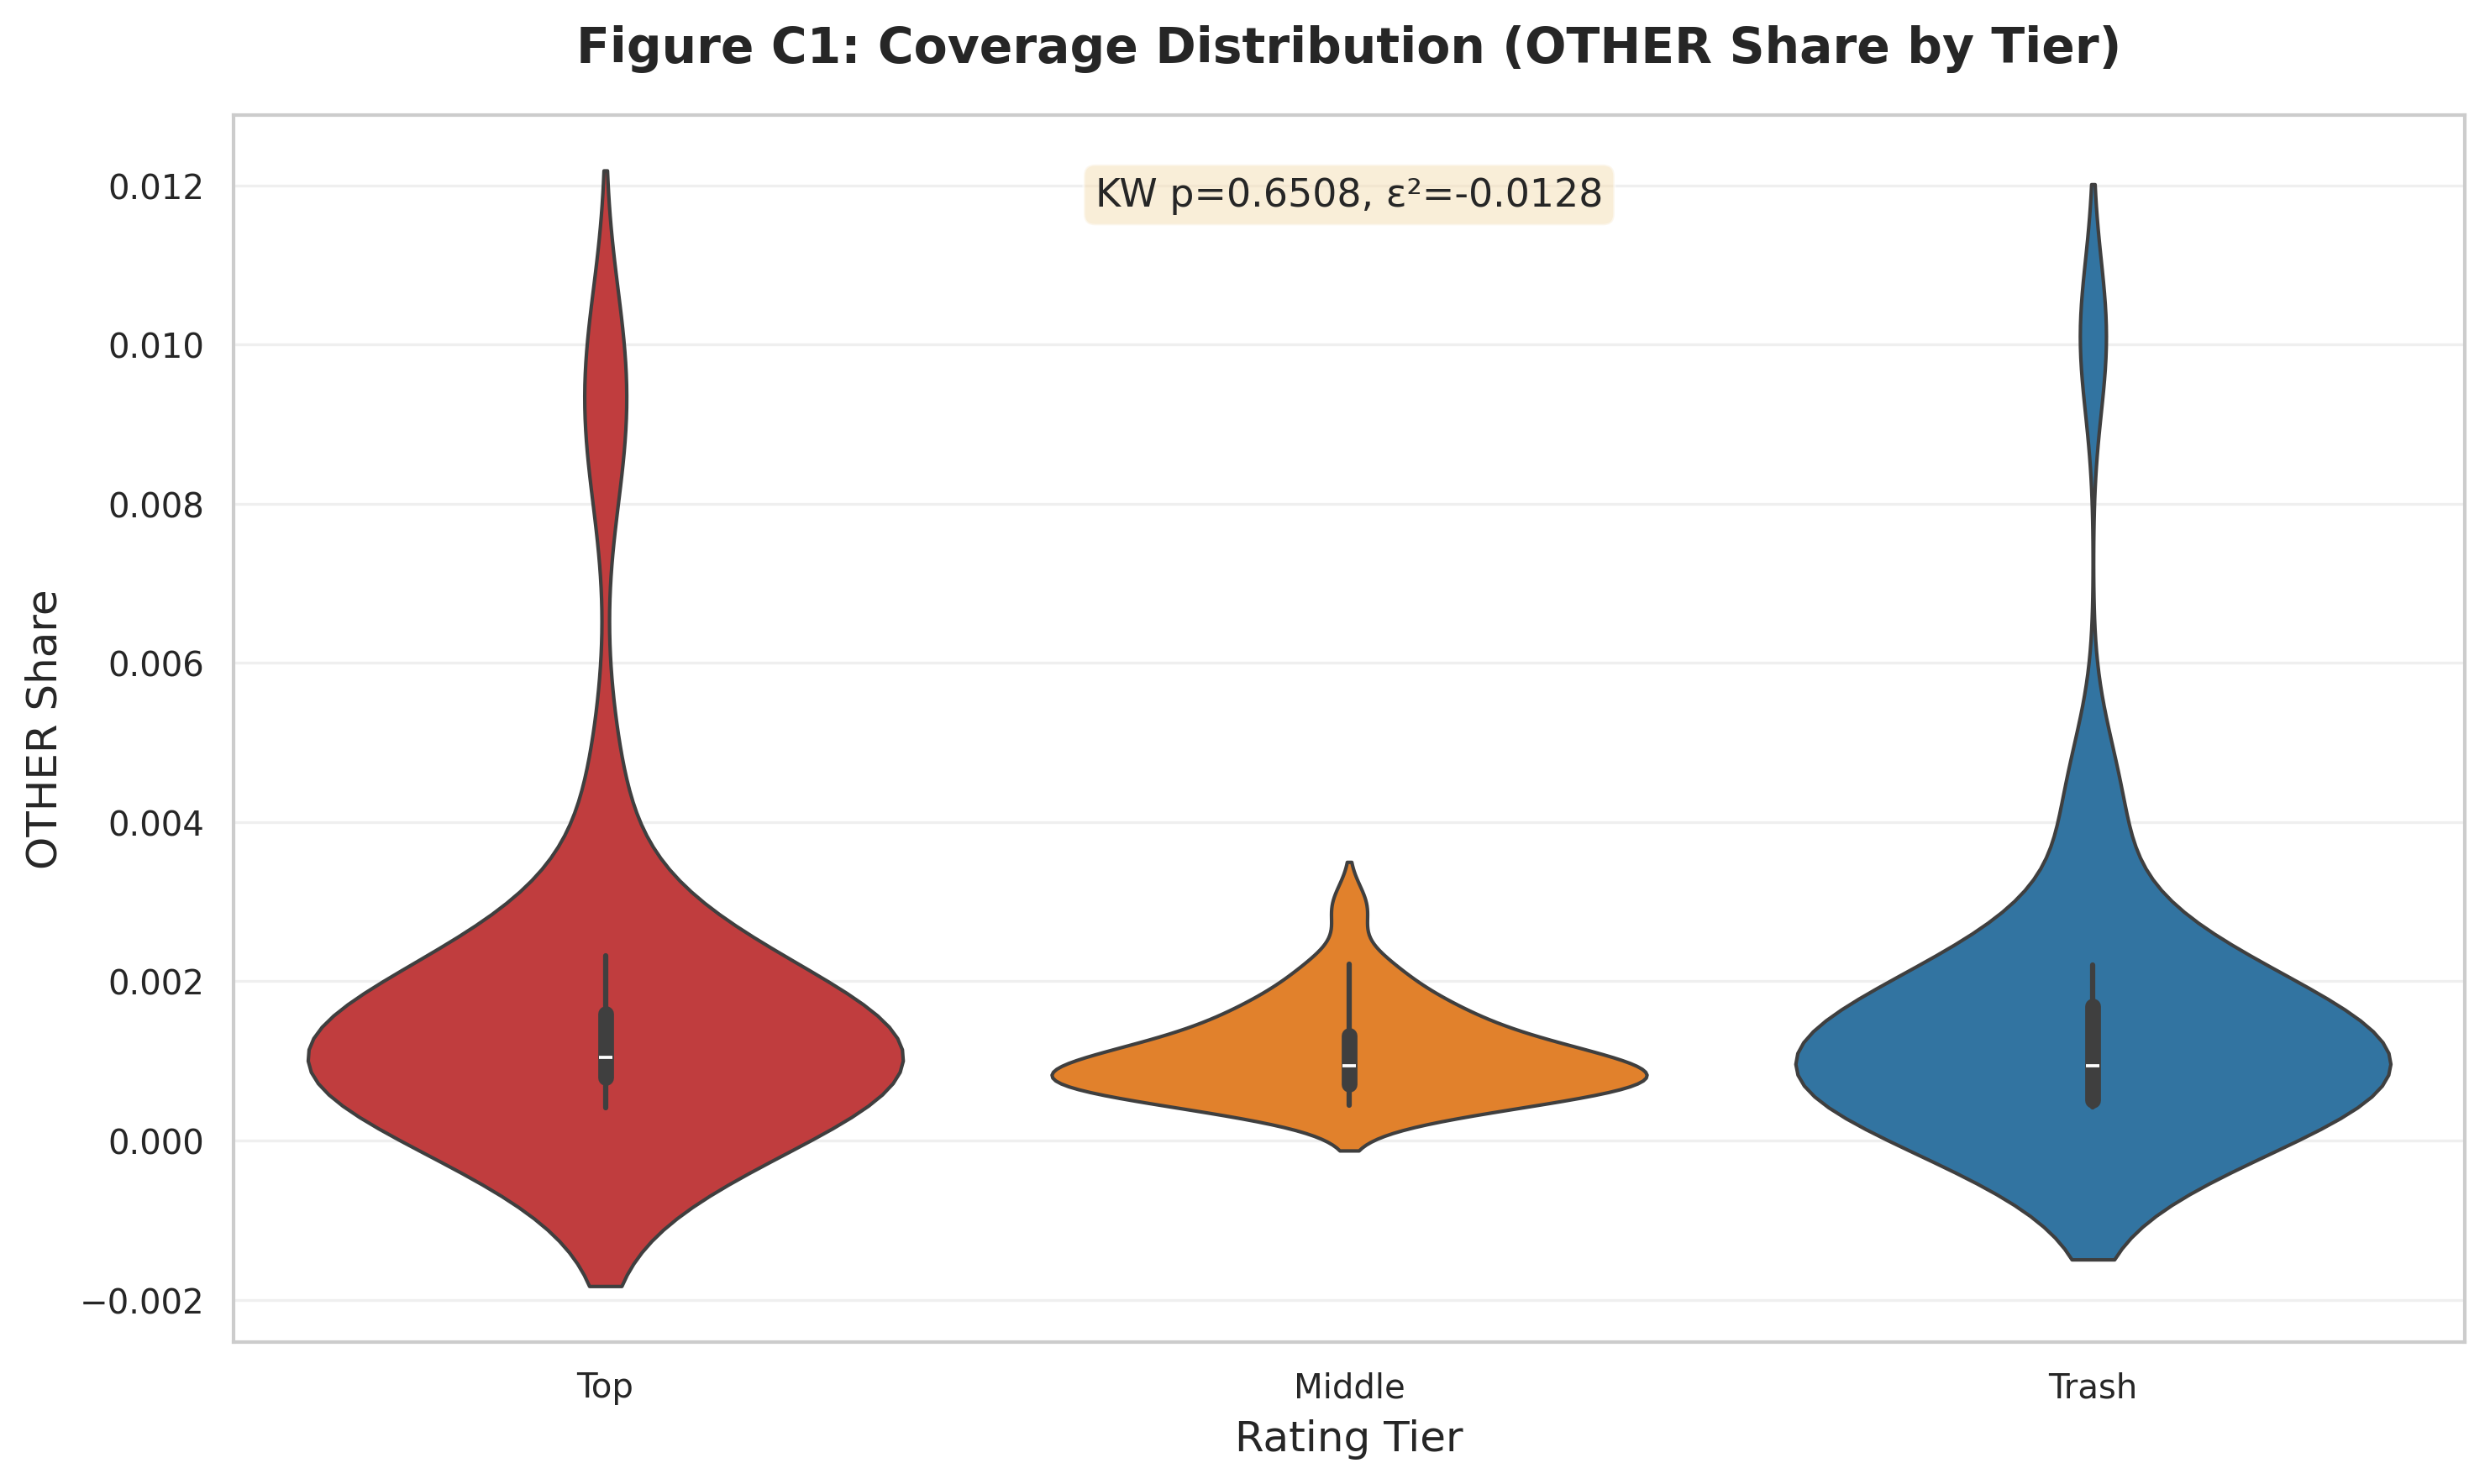

✓ Figure C1 saved: Coverage distribution


In [95]:
# Figure C1: Coverage Distribution (other_share by tier)
if 'book_main_group_shares' in locals() and len(book_main_group_shares) > 0:
    audit = book_main_group_shares[['book_id', 'rating_tier', 'other_share']].drop_duplicates()
    
    # Prepare data (handle tier name variations: top/good, middle/mid, trash/bad)
    plot_data = []
    tier_map = {'top': ['top', 'good'], 'middle': ['middle', 'mid'], 'trash': ['trash', 'bad']}
    tier_display = {'top': 'Top', 'middle': 'Middle', 'trash': 'Trash'}
    
    for tier_key, tier_values in tier_map.items():
        tier_data = audit[audit['rating_tier'].isin(tier_values)]['other_share'].dropna()
        for val in tier_data:
            plot_data.append({'Tier': tier_display[tier_key], 'OTHER Share': val})
    
    plot_df = pd.DataFrame(plot_data)
    
    # Kruskal-Wallis test (handle tier name variations)
    top_data = audit[audit['rating_tier'].isin(['top', 'good'])]['other_share'].dropna()
    mid_data = audit[audit['rating_tier'].isin(['middle', 'mid'])]['other_share'].dropna()
    trash_data = audit[audit['rating_tier'].isin(['trash', 'bad'])]['other_share'].dropna()
    
    kw_stat, kw_p = kruskal(top_data, mid_data, trash_data)
    n_total = len(top_data) + len(mid_data) + len(trash_data)
    epsilon_sq = compute_epsilon_squared(kw_stat, n_total, 3)
    
    # Create figure
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.violinplot(data=plot_df, x='Tier', y='OTHER Share', 
                   palette={'Top': '#d62728', 'Middle': '#ff7f0e', 'Trash': '#1f77b4'},
                   ax=ax, inner='box')
    
    # Add annotation
    ax.text(0.5, 0.95, f"KW p={kw_p:.4f}, ε²={epsilon_sq:.4f}", 
            transform=ax.transAxes, ha='center', va='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
            fontsize=11)
    
    ax.set_title('Figure C1: Coverage Distribution (OTHER Share by Tier)', 
                fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Rating Tier', fontsize=12)
    ax.set_ylabel('OTHER Share', fontsize=12)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    
    # Save
    plt.savefig(REPORT_FIG_DIR / "Figure_C1_coverage_distribution.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    # Also save interactive version
    fig_plotly = px.violin(plot_df, x='Tier', y='OTHER Share', 
                          color='Tier',
                          color_discrete_map={'Top': 'rgb(214, 39, 40)', 
                                            'Middle': 'rgb(255, 127, 14)', 
                                            'Trash': 'rgb(31, 119, 180)'},
                          title=f'Figure C1: Coverage Distribution (KW p={kw_p:.4f}, ε²={epsilon_sq:.4f})',
                          box=True, points='all')
    fig_plotly.update_layout(height=500)
    fig_plotly.write_html(str(REPORT_FIG_DIR / "Figure_C1_coverage_distribution.html"))
    
    print("✓ Figure C1 saved: Coverage distribution")
else:
    print("⚠️  book_main_group_shares not available")

### Figure C2: Diversity vs OTHER

Scatter plot of other_share vs effective_topics colored by tier, with Spearman rho within each tier.


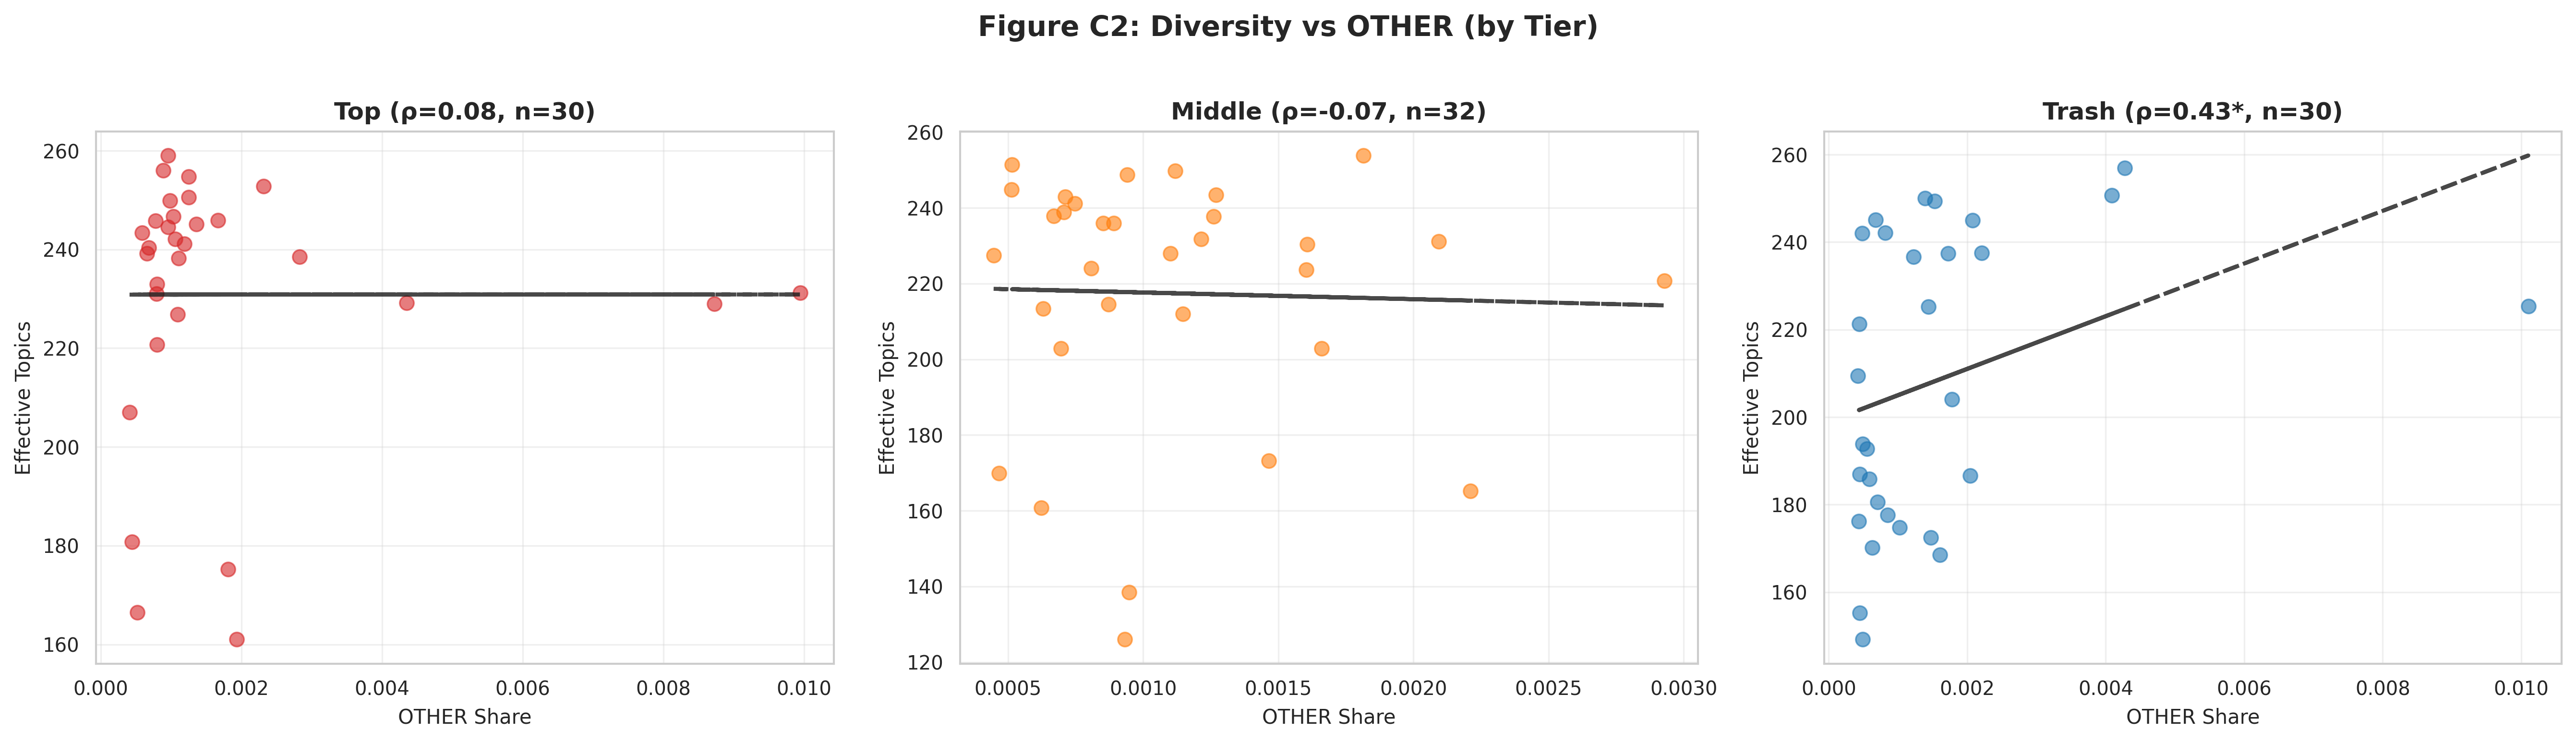

✓ Figure C2 saved: Diversity vs OTHER


In [96]:
# Figure C2: Diversity vs OTHER
if 'div_df' in locals() and 'other_share' in div_df.columns and 'effective_topics' in div_df.columns:
    from scipy.stats import spearmanr

    def stars(p):
        return "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else ""))

    # Create scatter plot
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Handle tier name variations
    tier_map = {'top': ['top', 'good'], 'middle': ['middle', 'mid'], 'trash': ['trash', 'bad']}
    tiers = list(tier_map.keys())
    tier_labels = ['Top', 'Middle', 'Trash']

    for idx, (tier, label) in enumerate(zip(tiers, tier_labels)):
        tier_data = div_df[div_df['rating_tier'] == tier].dropna(subset=['other_share', 'effective_topics'])

        if len(tier_data) >= 3:
            axes[idx].scatter(
                tier_data['other_share'],
                tier_data['effective_topics'],
                alpha=0.6, s=50, color=TIER_COLORS_DISPLAY[label]
            )

            # Add trend line
            z = np.polyfit(tier_data['other_share'], tier_data['effective_topics'], 1)
            p = np.poly1d(z)
            axes[idx].plot(
                tier_data['other_share'],
                p(tier_data['other_share']),
                "k--", alpha=0.8, linewidth=2
            )

            # Calculate correlation
            rho, p_val = spearmanr(tier_data['other_share'], tier_data['effective_topics'])
            n = len(tier_data)
            axes[idx].set_title(
                f'{label} (ρ={rho:.2f}{stars(p_val)}, n={n})',
                fontsize=12, fontweight='bold'
            )
            axes[idx].set_xlabel('OTHER Share', fontsize=10)
            axes[idx].set_ylabel('Effective Topics', fontsize=10)
            axes[idx].grid(alpha=0.3)

    fig.suptitle('Figure C2: Diversity vs OTHER (by Tier)', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(REPORT_FIG_DIR / "Figure_C2_diversity_vs_other.png", dpi=300, bbox_inches='tight')
    plt.show()

    # Interactive version
    fig_plotly = px.scatter(
        div_df.dropna(subset=['other_share', 'effective_topics']),
        x='other_share', y='effective_topics', color='rating_tier',
        color_discrete_map={
            'top': 'rgb(214, 39, 40)',
            'middle': 'rgb(255, 127, 14)',
            'trash': 'rgb(31, 119, 180)'
        },
        title='Figure C2: Diversity vs OTHER',
        labels={'other_share': 'OTHER Share', 'effective_topics': 'Effective Topics'},
        trendline='ols'
    )
    fig_plotly.update_layout(height=500)
    fig_plotly.write_html(str(REPORT_FIG_DIR / "Figure_C2_diversity_vs_other.html"))

    print("✓ Figure C2 saved: Diversity vs OTHER")
else:
    print("⚠️  div_df not available or missing columns")

### Figure T1: Main Group Composition by Tier

Grouped bars showing conditional shares with bootstrapped 95% CI or median + IQR.


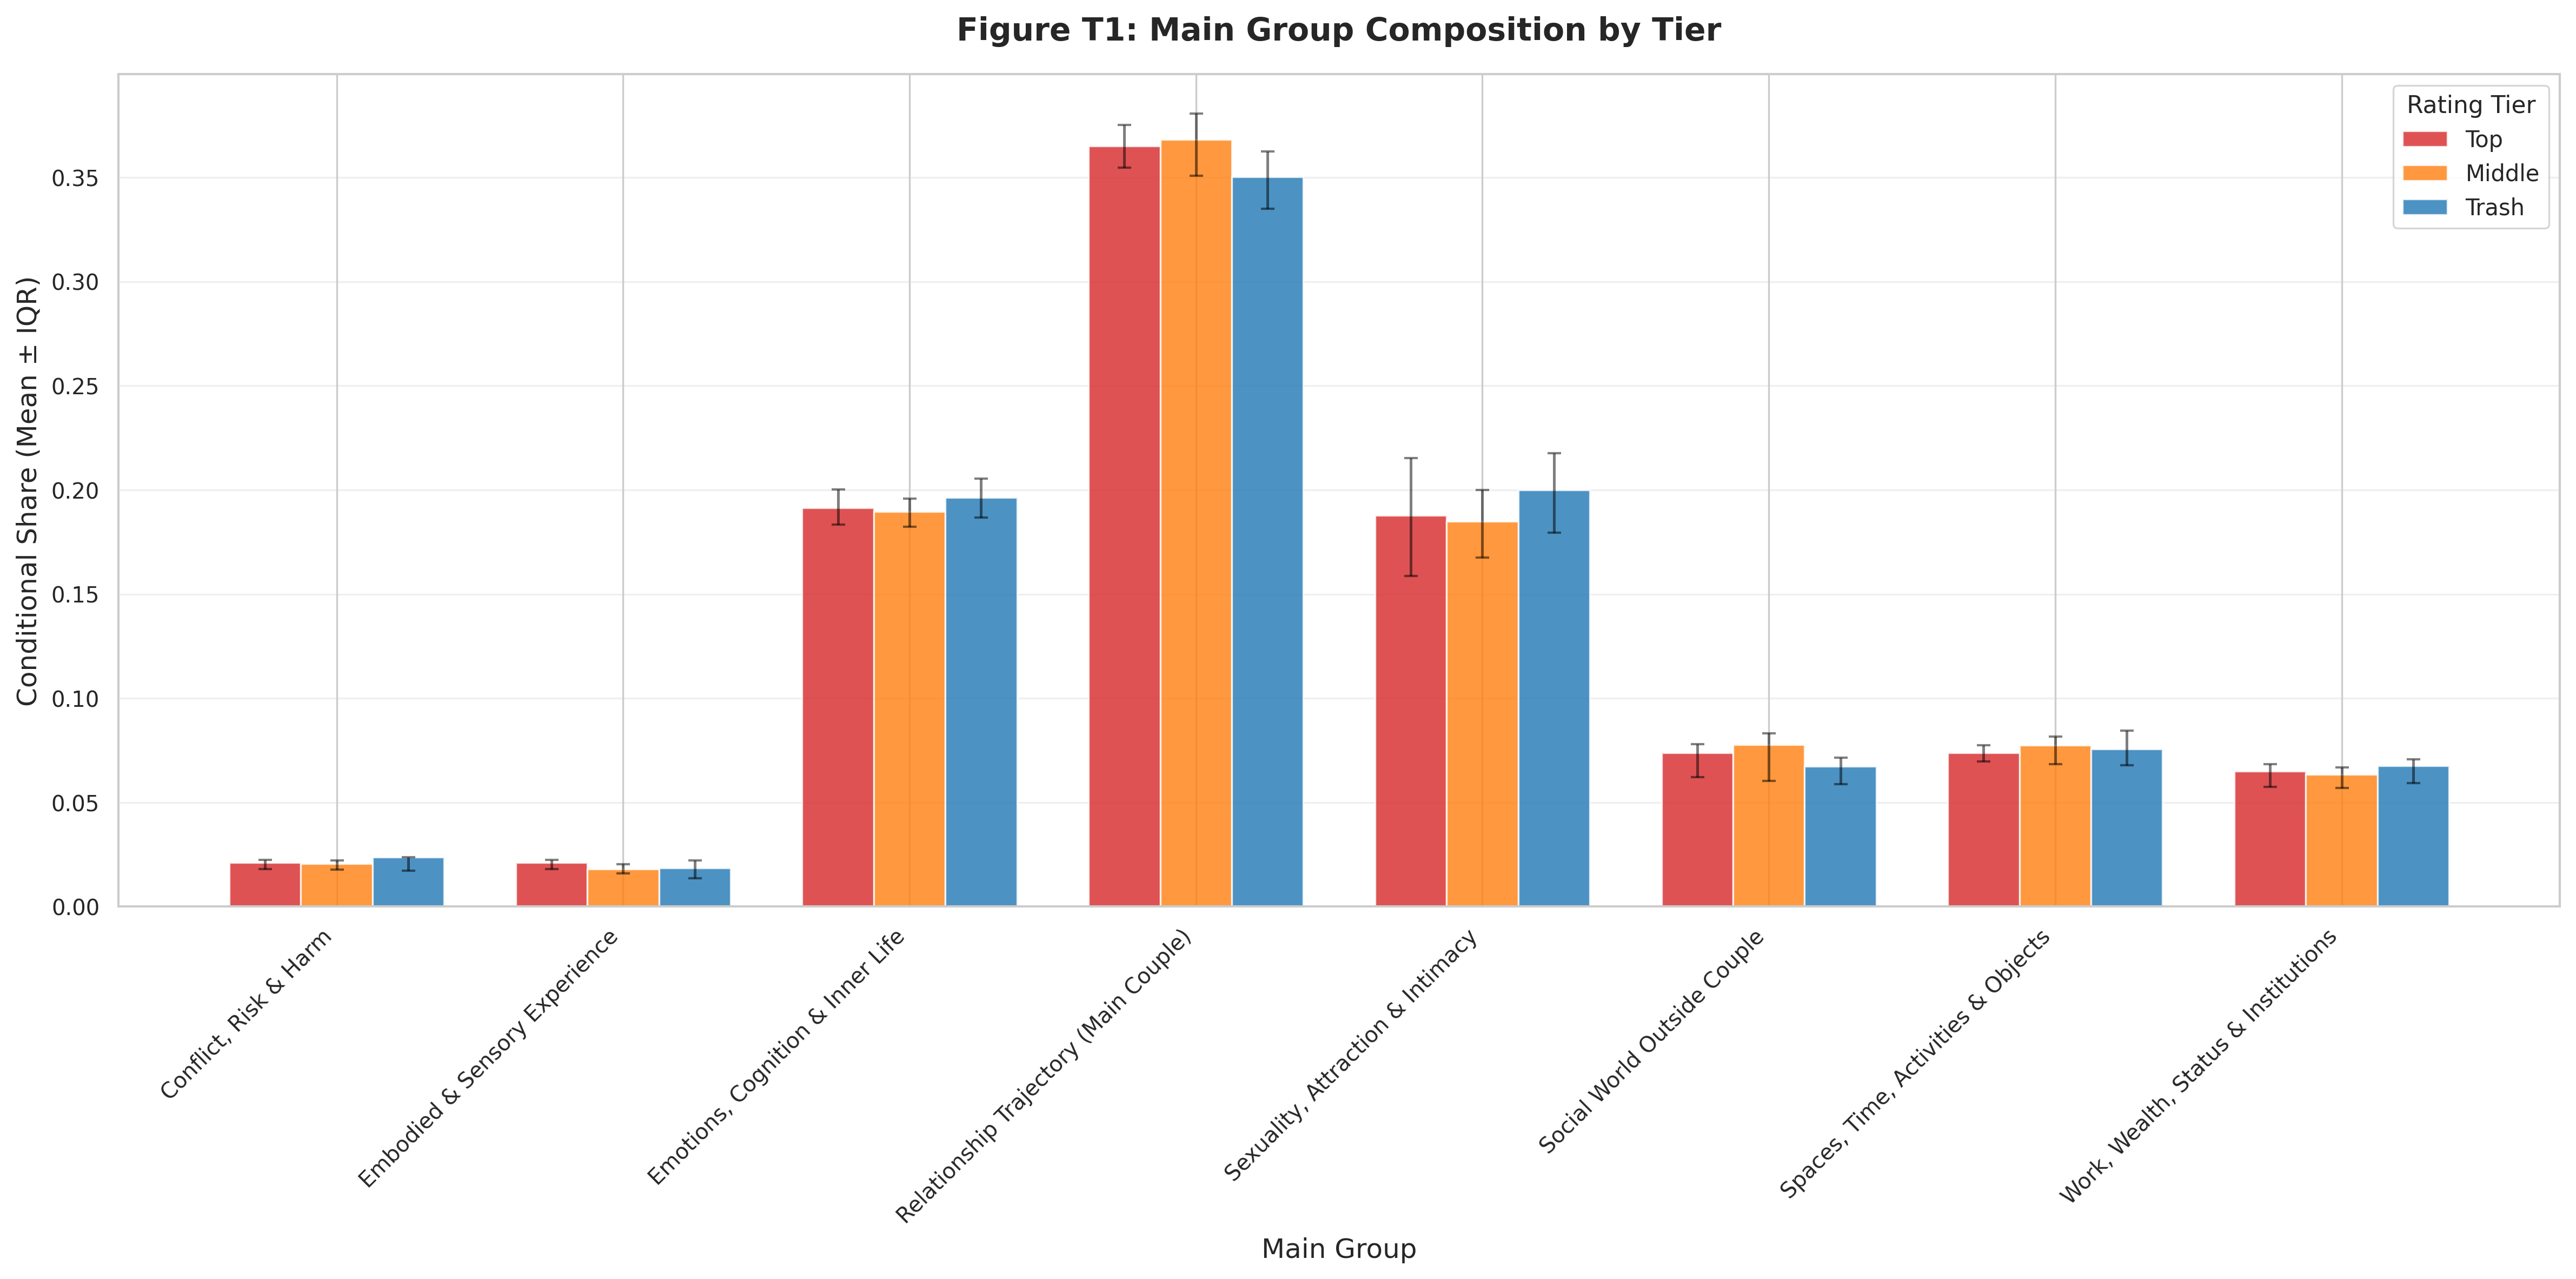

✓ Figure T1 saved: Main group composition


In [97]:
# Figure T1: Main Group Composition by Tier
if 'book_main_group_shares' in locals() and len(book_main_group_shares) > 0:
    # Prepare data with confidence intervals
    main_groups = sorted(book_main_group_shares['taxonomy_main_group'].dropna().unique())
    
    plot_data = []
    tier_map = {'top': ['top', 'good'], 'middle': ['middle', 'mid'], 'trash': ['trash', 'bad']}
    for main_group in main_groups:
        group_data = book_main_group_shares[book_main_group_shares['taxonomy_main_group'] == main_group]
        # Handle tier name variations: top/good, middle/mid, trash/bad
        for tier_key in ['top', 'middle', 'trash']:
            tier = tier_key
            tier_data = group_data[group_data['rating_tier'].isin(tier_map[tier_key])]['cond_share'].dropna()
            if len(tier_data) > 0:
                plot_data.append({
                    'Main Group': main_group,
                    'Tier': tier_key.capitalize(),
                    'Mean': tier_data.mean(),
                    'Median': tier_data.median(),
                    'Q1': tier_data.quantile(0.25),
                    'Q3': tier_data.quantile(0.75),
                    'Std': tier_data.std(),
                    'N': len(tier_data)
                })
    
    plot_df = pd.DataFrame(plot_data)
    
    # Create grouped bar chart with error bars (IQR)
    fig, ax = plt.subplots(figsize=(16, 8))
    x = np.arange(len(main_groups))
    width = 0.25
    
    for i, tier in enumerate(['Top', 'Middle', 'Trash']):
        tier_data = plot_df[plot_df['Tier'] == tier]
        means = [tier_data[tier_data['Main Group'] == mg]['Mean'].values[0] 
                if len(tier_data[tier_data['Main Group'] == mg]) > 0 else 0 
                for mg in main_groups]
        q1s = [tier_data[tier_data['Main Group'] == mg]['Q1'].values[0] 
              if len(tier_data[tier_data['Main Group'] == mg]) > 0 else 0 
              for mg in main_groups]
        q3s = [tier_data[tier_data['Main Group'] == mg]['Q3'].values[0] 
              if len(tier_data[tier_data['Main Group'] == mg]) > 0 else 0 
              for mg in main_groups]
        
        bars = ax.bar(x + i*width, means, width, label=tier,
                     color=['#d62728', '#ff7f0e', '#1f77b4'][i], alpha=0.8)
        
        # Add error bars (IQR)
        # Ensure non-negative error values (can be negative if mean is outside IQR range)
        errors_lower = [max(0, m - q1) for m, q1 in zip(means, q1s)]
        errors_upper = [max(0, q3 - m) for m, q3 in zip(means, q3s)]
        ax.errorbar(x + i*width, means, yerr=[errors_lower, errors_upper], 
                   fmt='none', color='black', alpha=0.5, capsize=3)
    
    ax.set_xlabel('Main Group', fontsize=12)
    ax.set_ylabel('Conditional Share (Mean ± IQR)', fontsize=12)
    ax.set_title('Figure T1: Main Group Composition by Tier', fontsize=14, fontweight='bold', pad=15)
    ax.set_xticks(x + width)
    ax.set_xticklabels(main_groups, rotation=45, ha='right')
    ax.legend(title='Rating Tier')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    
    plt.savefig(REPORT_FIG_DIR / "Figure_T1_main_group_composition.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    # Interactive version
    fig_plotly = px.bar(plot_df, x='Main Group', y='Mean', color='Tier',
                       barmode='group', error_y='Std',
                       color_discrete_map={'Top': 'rgb(214, 39, 40)', 
                                         'Middle': 'rgb(255, 127, 14)', 
                                         'Trash': 'rgb(31, 119, 180)'},
                       title='Figure T1: Main Group Composition by Tier',
                       labels={'Mean': 'Mean Conditional Share', 'Main Group': 'Main Group'})
    fig_plotly.update_layout(height=600, xaxis_tickangle=-45)
    fig_plotly.write_html(str(REPORT_FIG_DIR / "Figure_T1_main_group_composition.html"))
    
    print("✓ Figure T1 saved: Main group composition")
else:
    print("⚠️  book_main_group_shares not available")

### Figure T2: Main Group Heatmap

Heatmap showing Top-Trash effect sizes (Cliff's Delta) for each main group.


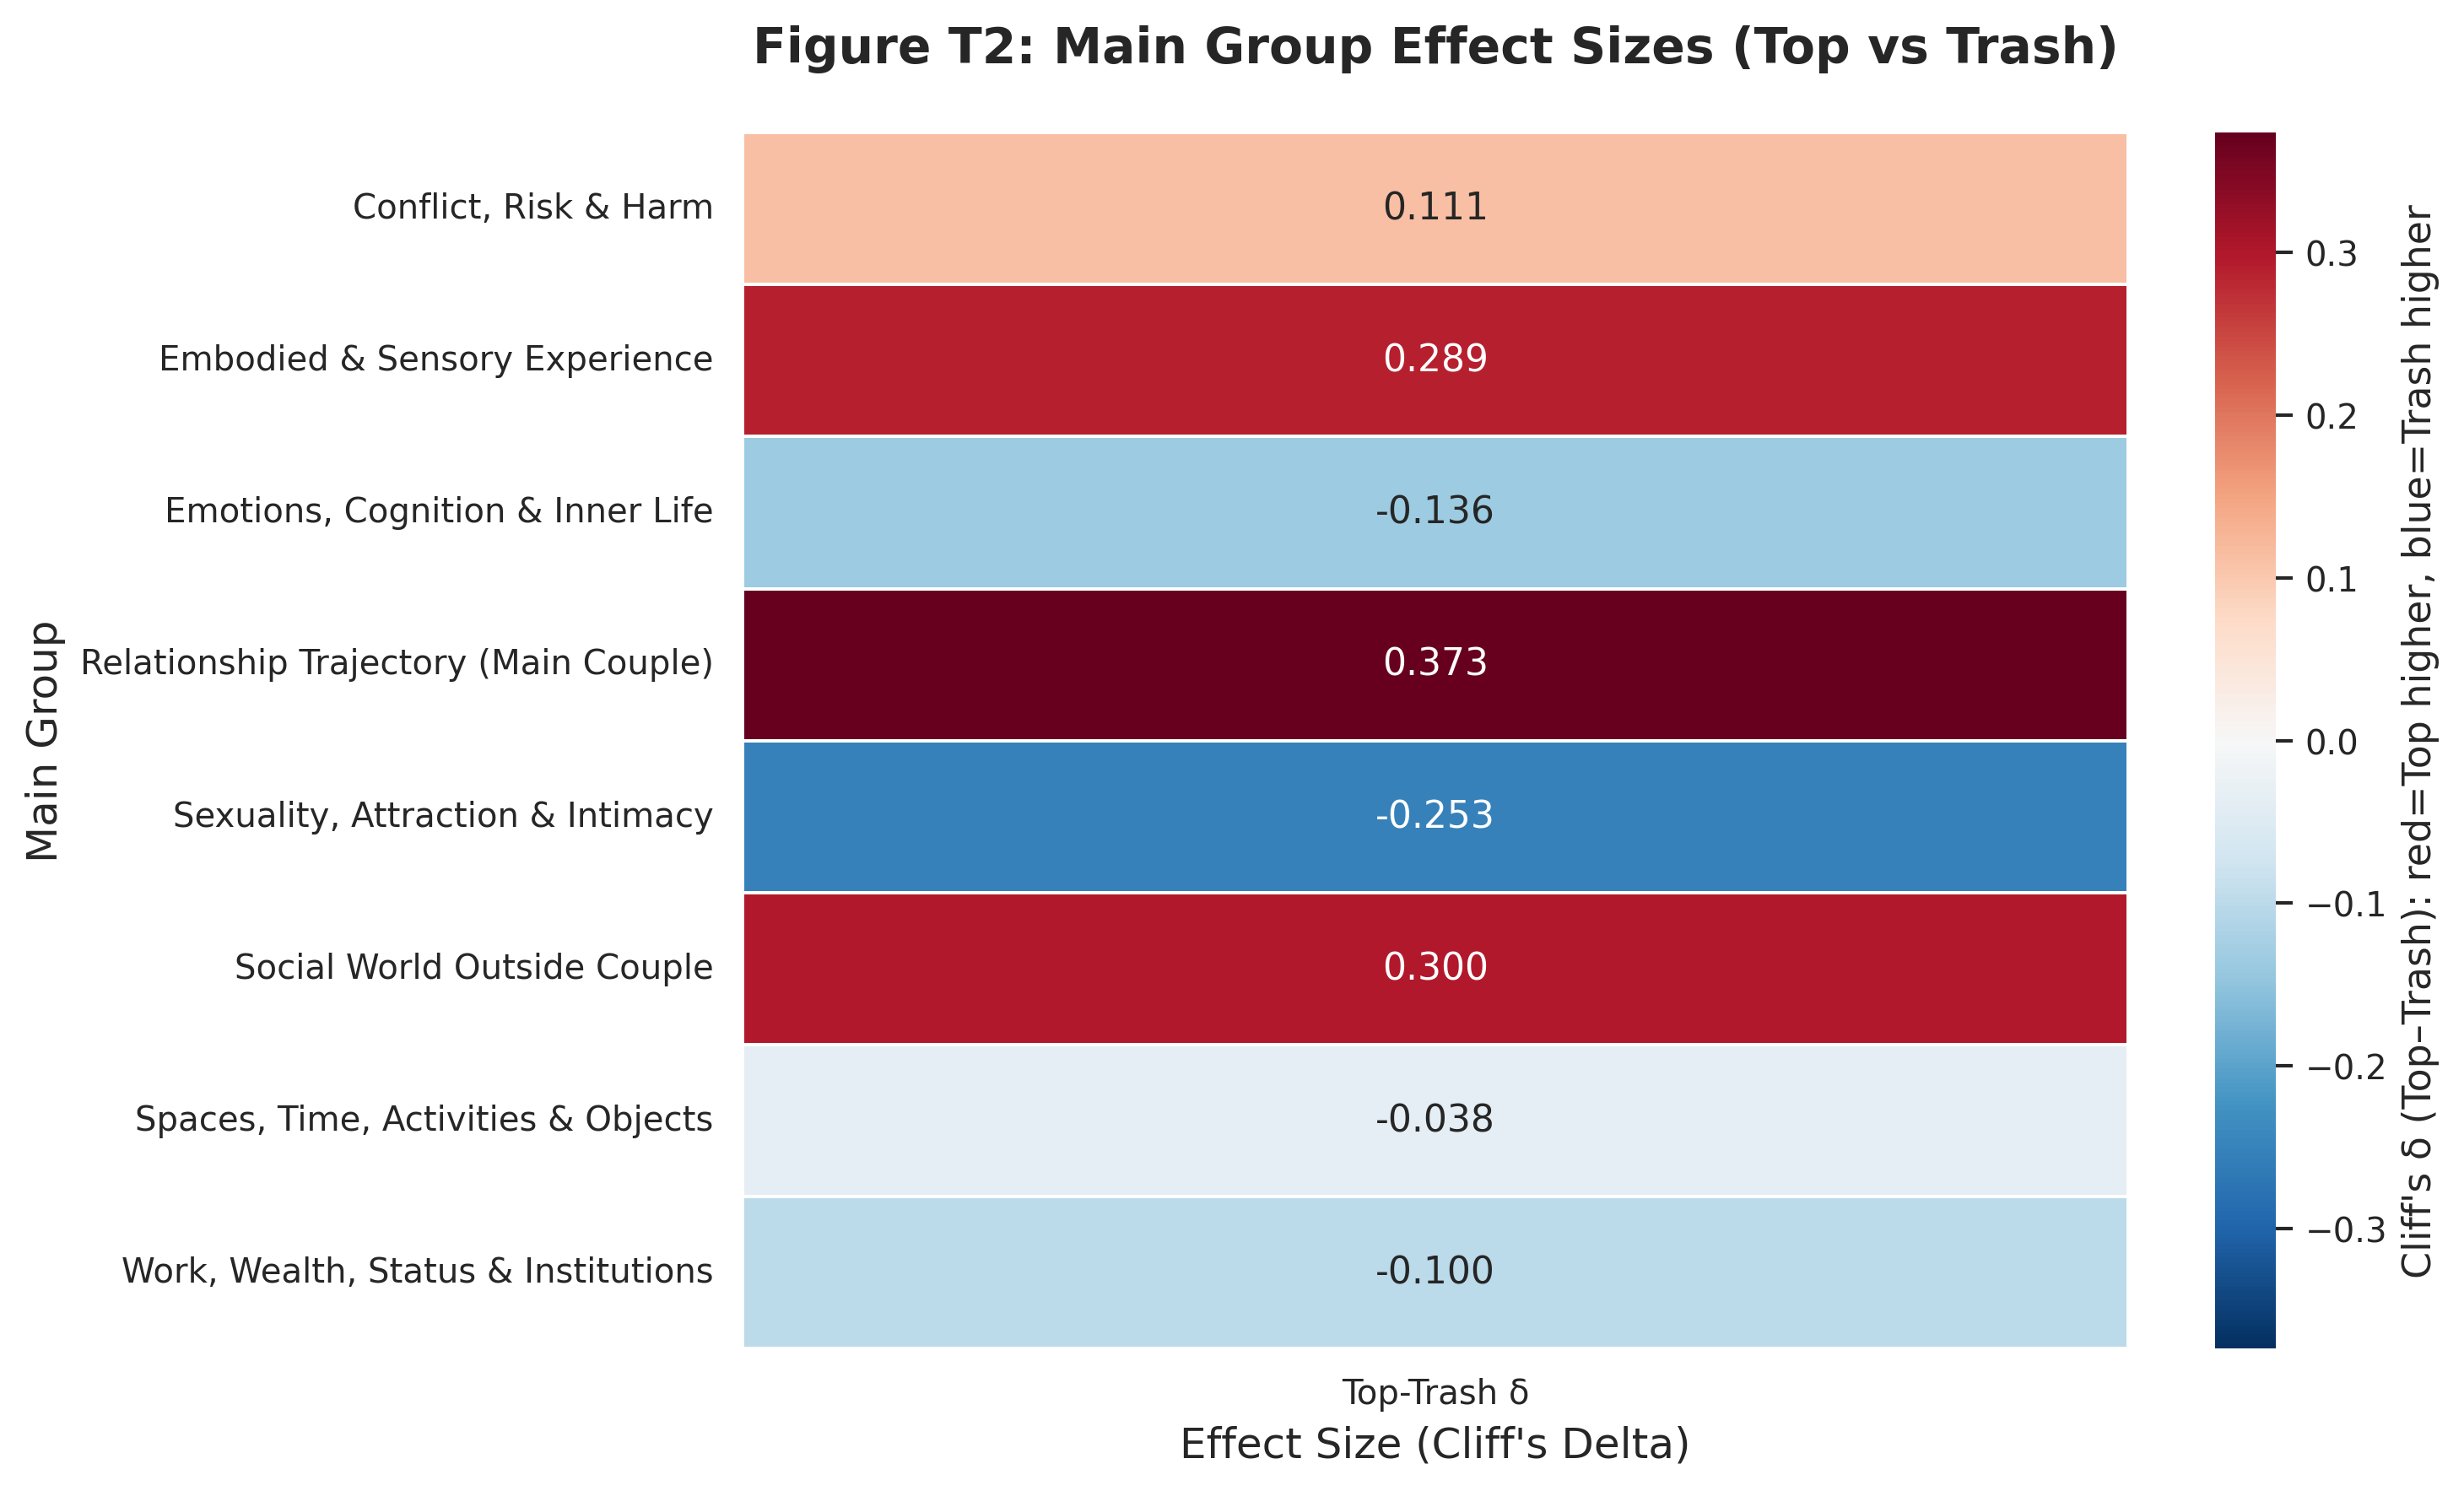

✓ Figure T2 saved: Main group heatmap


In [98]:
# Figure T2: Main Group Heatmap
if 'main_group_results' in locals() and len(main_group_results) > 0:
    # Prepare data: rows = main groups, column = Top-Trash effect size
    heatmap_data = []
    for _, row in main_group_results.iterrows():
        if not np.isnan(row.get('top_vs_trash_delta', np.nan)):
            heatmap_data.append({
                'Main Group': row['taxonomy_main_group'],
                "Top-Trash δ": row['top_vs_trash_delta']
            })
    
    if len(heatmap_data) > 0:
        heatmap_df = pd.DataFrame(heatmap_data)
        
        # Create pivot (single column heatmap)
        pivot_data = heatmap_df.set_index('Main Group')["Top-Trash δ"].to_frame()
        
        # Create heatmap
        fig, ax = plt.subplots(figsize=(10, max(6, len(pivot_data) * 0.6)))
        vals = pivot_data.values.flatten()
        norm, lim = symmetric_effect_norm(vals, default=0.5)
        sns.heatmap(
            pivot_data, annot=True, fmt='.3f',
            cmap=EFFECT_CMAP_MPL, norm=norm,
            cbar_kws={'label': "Cliff's δ (Top–Trash): red=Top higher, blue=Trash higher"},
            ax=ax, linewidths=0.5
        )
        ax.set_title("Figure T2: Main Group Effect Sizes (Top vs Trash)", 
                    fontsize=14, fontweight='bold', pad=20)
        ax.set_xlabel('Effect Size (Cliff\'s Delta)', fontsize=12)
        ax.set_ylabel('Main Group', fontsize=12)
        plt.tight_layout()
        plt.savefig(REPORT_FIG_DIR / "Figure_T2_main_group_heatmap.png", dpi=300, bbox_inches='tight')
        plt.show()
        
        # Interactive version
        lim = float(np.nanmax(np.abs(heatmap_df["Top-Trash δ"].values))) if len(heatmap_df) > 0 else 0.5
        lim = max(lim, 1e-6)
        fig_plotly = px.bar(
            heatmap_df.sort_values("Top-Trash δ", ascending=True),
            x="Top-Trash δ", y='Main Group', orientation='h',
            color="Top-Trash δ",
            color_continuous_scale=EFFECT_CMAP_PLOTLY,
            range_color=[-lim, lim],
            color_continuous_midpoint=0.0,
            title="Figure T2: Main Group Effect Sizes (Top vs Trash)",
            labels={"Top-Trash δ": "Cliff's δ (Top–Trash): red=Top higher, blue=Trash higher"}
        )
        fig_plotly.update_layout(height=max(500, len(heatmap_df) * 50))
        fig_plotly.write_html(str(REPORT_FIG_DIR / "Figure_T2_main_group_heatmap.html"))
        
        print("✓ Figure T2 saved: Main group heatmap")
    else:
        print("⚠️  No effect size data available")
else:
    print("⚠️  main_group_results not available")

### Figure S1a-S1h: Subgroup Panels (One per Main Group)

For each main group, create a panel showing subgroups with within-group shares by tier, annotated with Top-Trash deltas.


In [99]:
# Figure S1a-S1h: Subgroup Panels (publication-ready, compact, no annotation overlap)
if 'book_subgroup_shares' in locals() and 'subgroup_results' in locals():
    main_groups = sorted(book_subgroup_shares['taxonomy_main_group'].dropna().unique())
    main_group_labels = {mg: f"S1{chr(97+i)}" for i, mg in enumerate(main_groups)}  # 97 = 'a'

    for main_group in main_groups:
        group_data = book_subgroup_shares[
            book_subgroup_shares['taxonomy_main_group'] == main_group
        ].copy()
        if len(group_data) == 0:
            continue
        subgroups = sorted(group_data['taxonomy_main_name'].dropna().unique())

        # Get effect sizes for annotation
        subgroup_deltas = {}
        for subgroup in subgroups:
            sub_result = subgroup_results[
                (subgroup_results['taxonomy_main_group'] == main_group) &
                (subgroup_results['taxonomy_main_name'] == subgroup)
            ]
            if len(sub_result) > 0 and not np.isnan(sub_result.iloc[0].get('top_vs_trash_delta', np.nan)):
                subgroup_deltas[subgroup] = sub_result.iloc[0]['top_vs_trash_delta']

        # --- Figure Size Tuning for Publication ---
        max_label_len = max([len(str(sg)) for sg in subgroups]) if subgroups else 10
        bar_width = 0.22
        spacing = 0.14
        base_width = 1.2 + max(7, len(subgroups)) * (bar_width + spacing)
        height = 4 + 0.08*max_label_len
        height = min(height, 8)
        fig, ax = plt.subplots(figsize=(base_width, height))

        x = np.arange(len(subgroups))
        width = bar_width

        # Plot bars for each tier
        tier_colors = {'Top':'#d62728','Middle':'#ff7f0e','Trash':'#1f77b4'}
        tier_map = {'top': ['top', 'good'], 'middle': ['middle', 'mid'], 'trash': ['trash', 'bad']}
        for i, tier in enumerate(['Top', 'Middle', 'Trash']):
            tier_key = tier.lower()
            means = []
            for subgroup in subgroups:
                sub_data = group_data[
                    (group_data['taxonomy_main_name'] == subgroup) &
                    (group_data['rating_tier'].isin(tier_map[tier_key]))
                ]['within_group_share'].dropna()
                means.append(sub_data.mean() if len(sub_data) > 0 else 0)

            bars = ax.bar(x + i*width - width, means, width, label=tier, color=tier_colors[tier], alpha=0.85)

        # Add delta annotations ABOVE BARS, staggered to avoid overlap
        ylims = ax.get_ylim()
        ytop = ylims[1]
        delta_space = (ytop - ylims[0]) * 0.035
        for i, subgroup in enumerate(subgroups):
            if subgroup in subgroup_deltas:
                delta = subgroup_deltas[subgroup]
                # Find tallest bar at this subgroup for vertical placement
                tops = [
                    group_data[
                        (group_data['taxonomy_main_name'] == subgroup) &
                        (group_data['rating_tier'] == t.lower())
                    ]['within_group_share'].dropna().mean() if
                        len(group_data[
                            (group_data['taxonomy_main_name'] == subgroup) &
                            (group_data['rating_tier'] == t.lower())
                        ]) > 0 else 0
                    for t in ['Top', 'Middle', 'Trash']
                ]
                base_y = max(tops)
                # Stagger labels: alternate sides to minimize overlap
                if i % 2 == 0:
                    ypos = base_y + delta_space
                    va = 'bottom'
                else:
                    ypos = base_y + delta_space*2.1
                    va = 'bottom'
                ax.text(i, ypos, f'δ={delta:.2f}', ha='center', va=va, fontsize=9.5,
                        bbox=dict(boxstyle='round,pad=0.24', facecolor='white', alpha=0.72),
                        clip_on=True)

        ax.set_xlabel('Subgroup', fontsize=12)
        ax.set_ylabel('Within-Group Share', fontsize=12)
        ax.set_title(
            f"Figure {main_group_labels[main_group]}: {main_group}",
            fontsize=13.5, fontweight='bold', pad=10)
        ax.set_xticks(x)
        ax.set_xticklabels(subgroups, rotation=35, ha='right', fontsize=10, wrap=True)
        ax.legend(title='Rating Tier', fontsize=10, title_fontsize=11)
        ax.grid(axis='y', alpha=0.25)
        ax.set_ylim(bottom=0, top=ytop*1.09)
        plt.tight_layout(pad=1.7)

        # Save (compact png)
        safe_name = "".join(c if c.isalnum() or c in (' ', '-', '_') else '_' for c in main_group)[:45]
        plt.savefig(REPORT_FIG_DIR / f"Figure_{main_group_labels[main_group]}_subgroup_panel_{safe_name}.png",
                    dpi=300, bbox_inches='tight')
        plt.close(fig)

        # --- Interactive version (compact, non-overlapping) ---
        plot_data = []
        for subgroup in subgroups:
            for tier_key in ['top', 'middle', 'trash']:
                tier = tier_key
                sub_data = group_data[
                    (group_data['taxonomy_main_name'] == subgroup) &
                    (group_data['rating_tier'].isin(tier_map[tier_key]))
                ]['within_group_share'].dropna()
                for val in sub_data:
                    plot_data.append({
                        'Subgroup': subgroup,
                        'Tier': tier_key.capitalize(),
                        'Within-Group Share': val
                    })
        if plot_data:
            plot_df = pd.DataFrame(plot_data)
            figure_height_px = min(max(260 + len(subgroups)*32, 370), 800)
            fig_plotly = px.bar(
                plot_df, x='Subgroup', y='Within-Group Share', color='Tier',
                barmode='group',
                color_discrete_map={'Top': 'rgb(214, 39, 40)',
                                   'Middle': 'rgb(255, 127, 14)',
                                   'Trash': 'rgb(31, 119, 180)'},
                title=f"Figure {main_group_labels[main_group]}: {main_group}"
            )
            fig_plotly.update_layout(
                height=figure_height_px,
                xaxis_tickangle=-37,
                margin=dict(t=60, b=110, l=40, r=30)
            )
            # Add delta annotation to hover data
            if subgroup_deltas:
                delta_by_subgroup = {sg: f"{subgroup_deltas[sg]:.2f}" for sg in subgroup_deltas}
                custom_data = plot_df["Subgroup"].map(delta_by_subgroup).fillna("")
                fig_plotly.update_traces(
                    customdata=custom_data,
                    hovertemplate="<b>%{x}</b><br>Tier: %{marker.color}<br>" +
                                  "Within-Group Share: %{y:.3f}<br>Δ (Top-Trash): %{customdata}"
                )
            html_path = REPORT_FIG_DIR / f"Figure_{main_group_labels[main_group]}_subgroup_panel_{safe_name}.html"
            fig_plotly.write_html(str(html_path))
    print(f"✓ Figure S1a-S1h saved: Subgroup panels for {len(main_groups)} main groups")
else:
    print("⚠️  book_subgroup_shares or subgroup_results not available")

✓ Figure S1a-S1h saved: Subgroup panels for 8 main groups


### Table Dk & Figure Dk: Driver Topics per Subgroup

For each significant subgroup (|δ| ≥ 0.20 OR p < 0.10), create a formatted table and dot plot of driver topics.


Found 14 significant subgroups for driver analysis


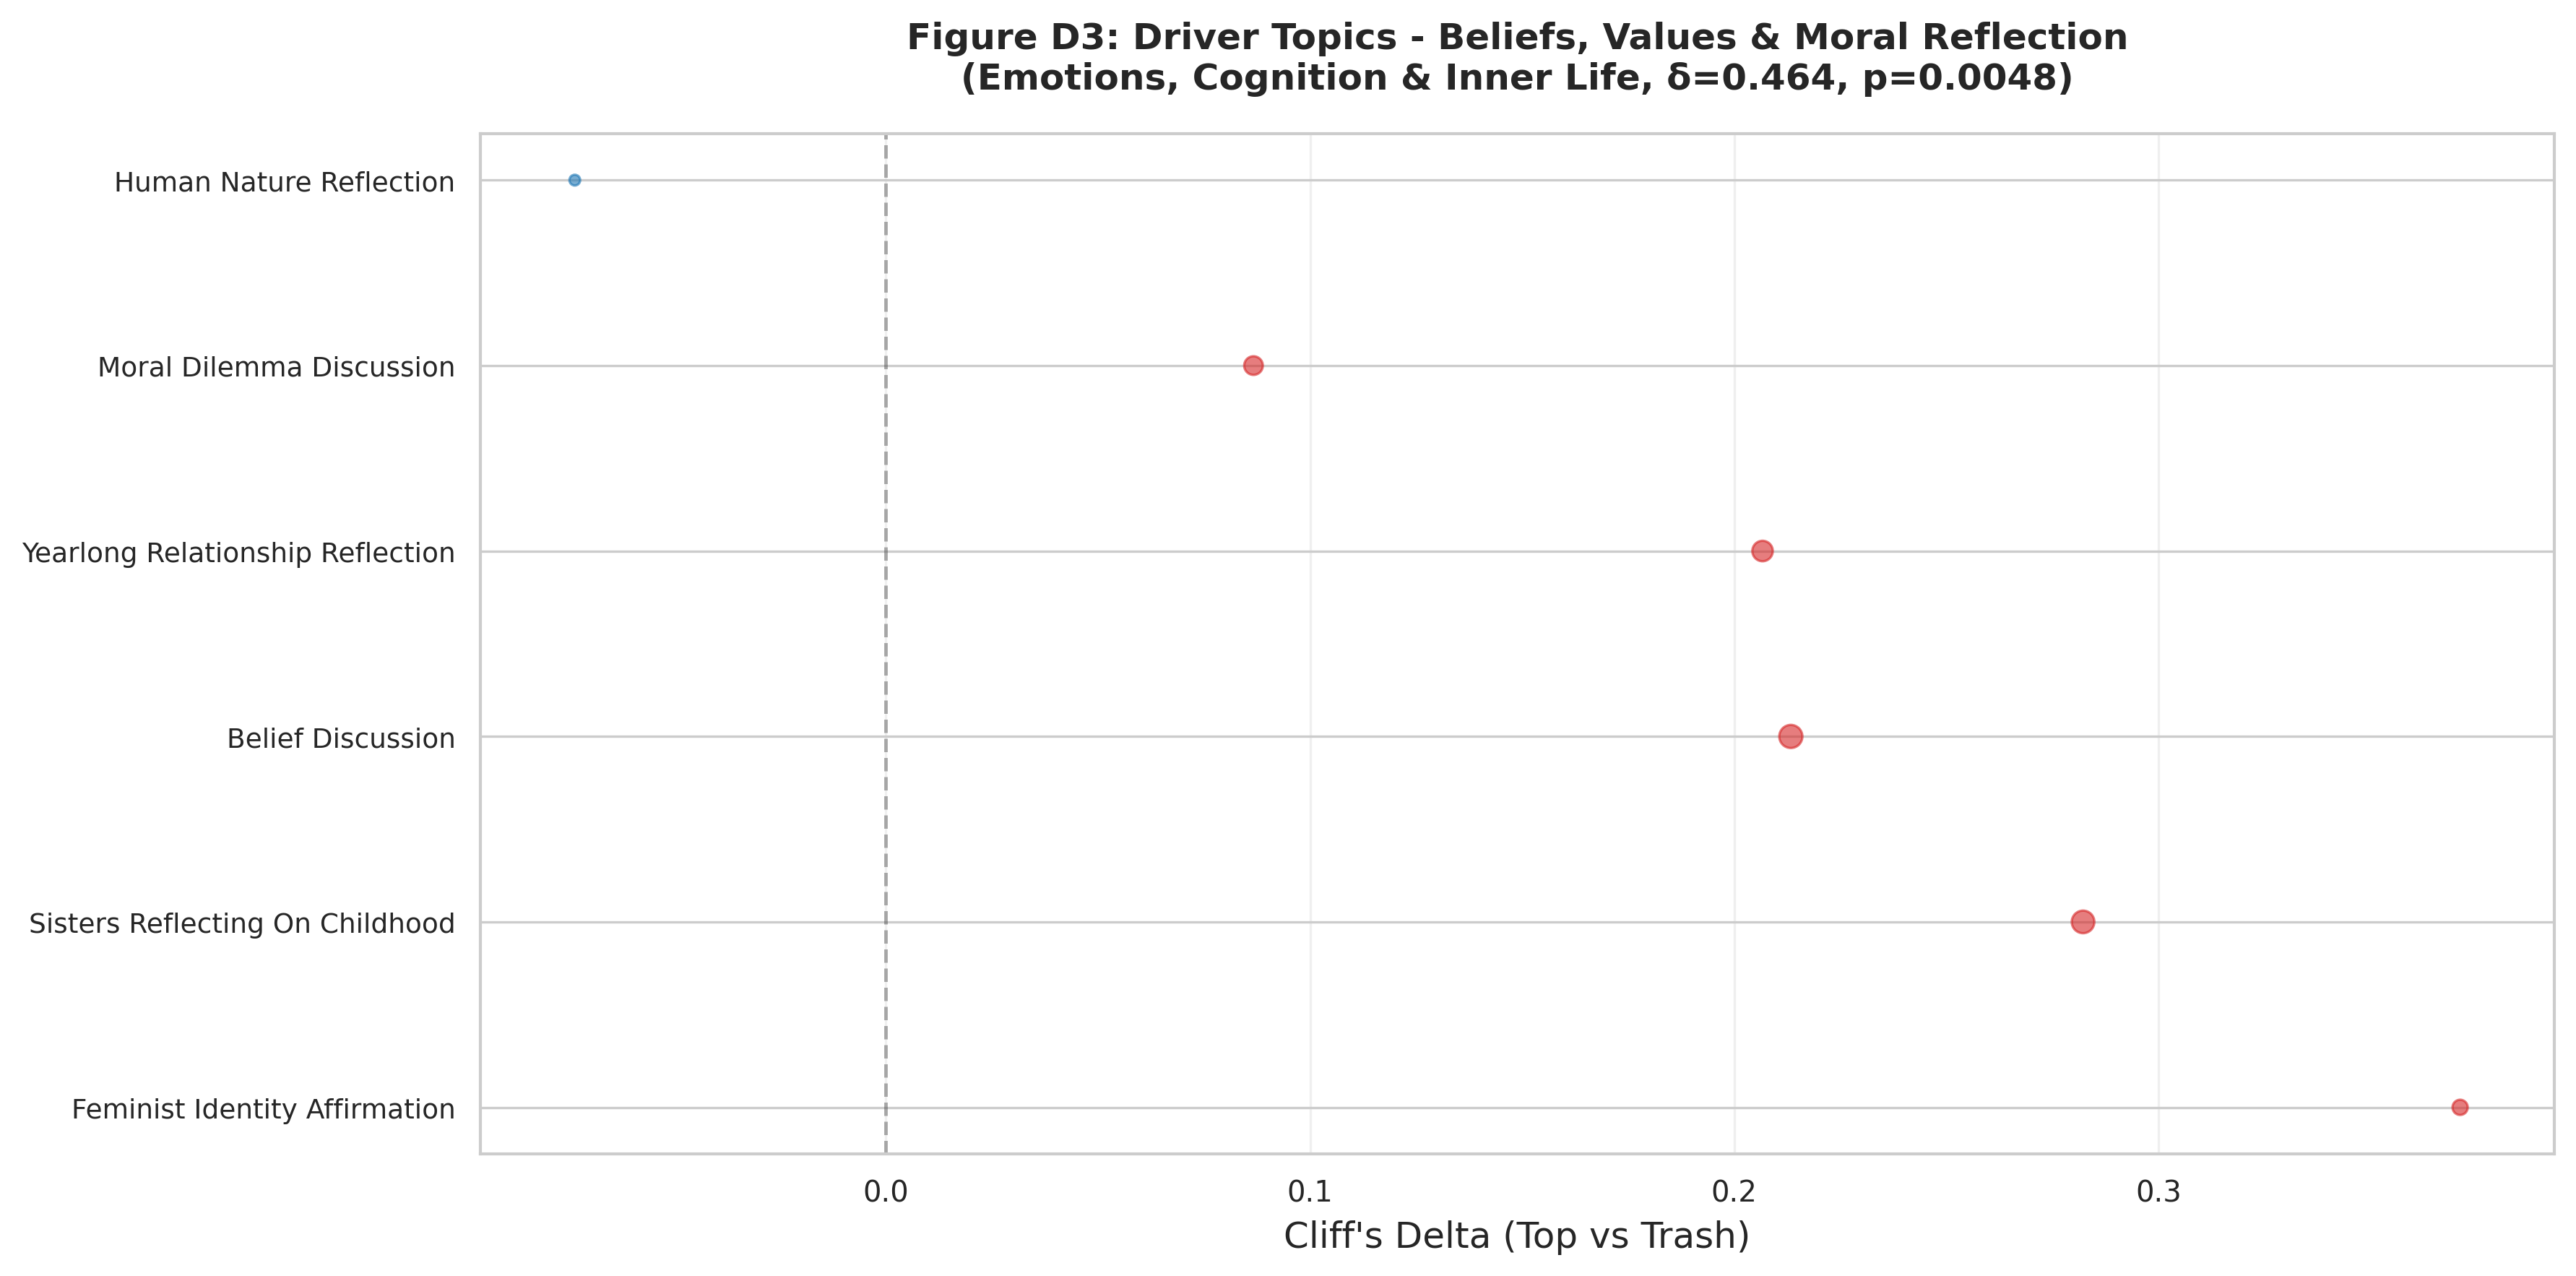

✓ Table D3 & Figure D3 saved: Beliefs, Values & Moral Reflection (6 topics)


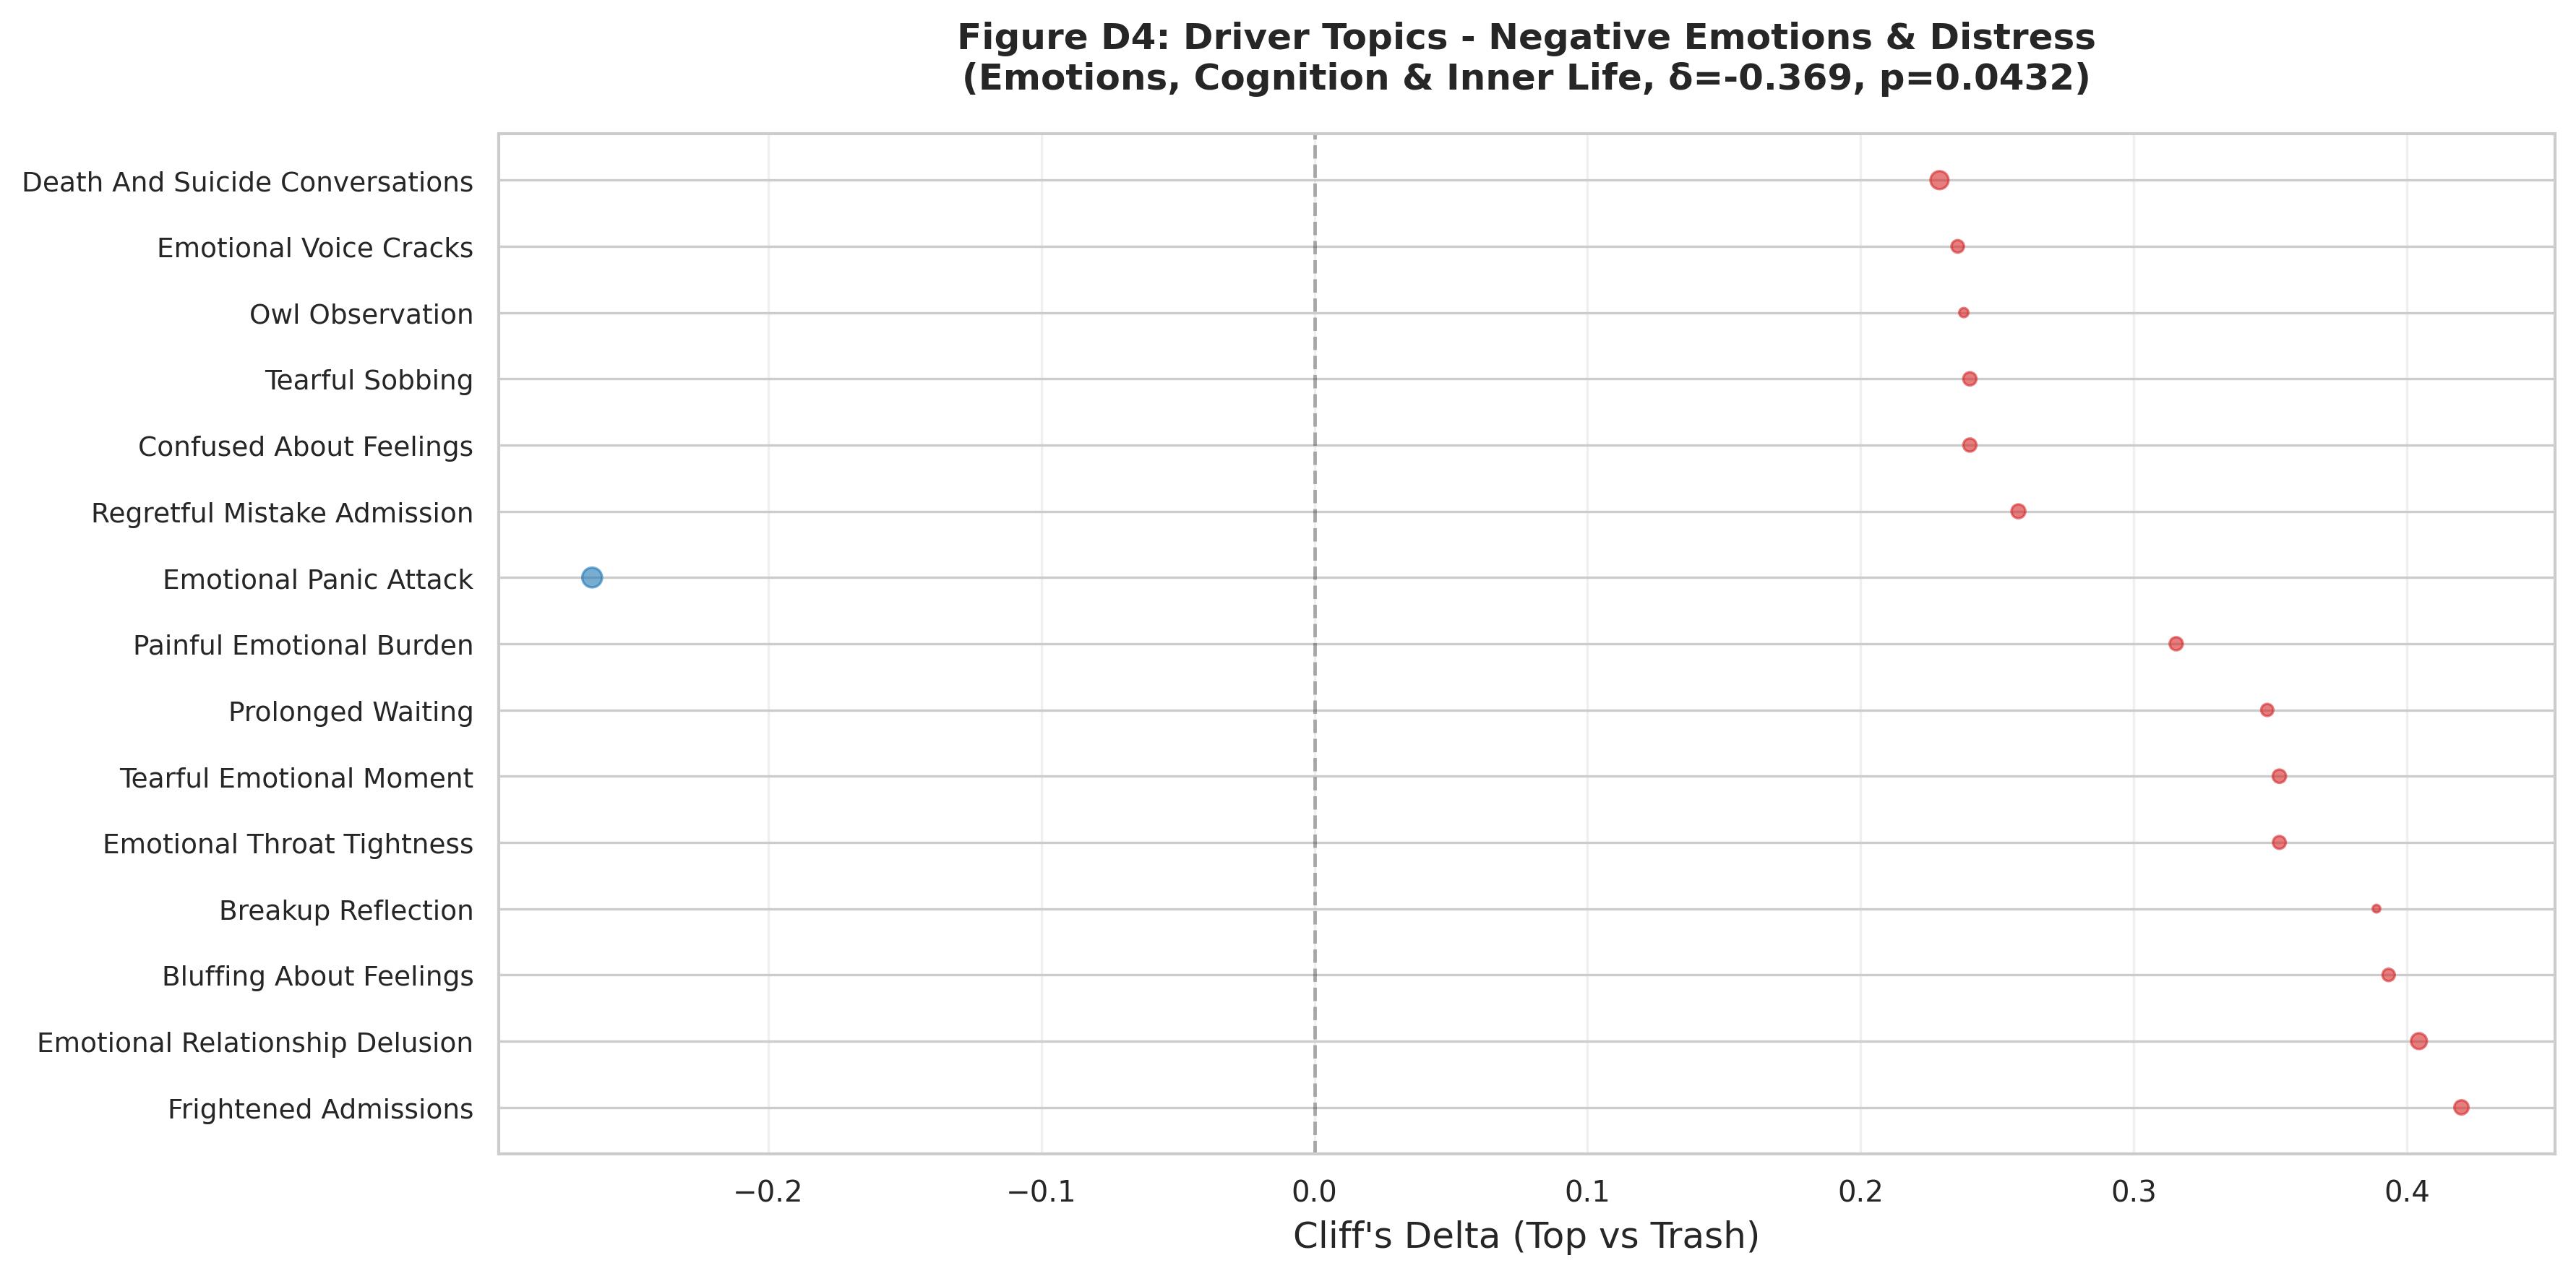

✓ Table D4 & Figure D4 saved: Negative Emotions & Distress (15 topics)


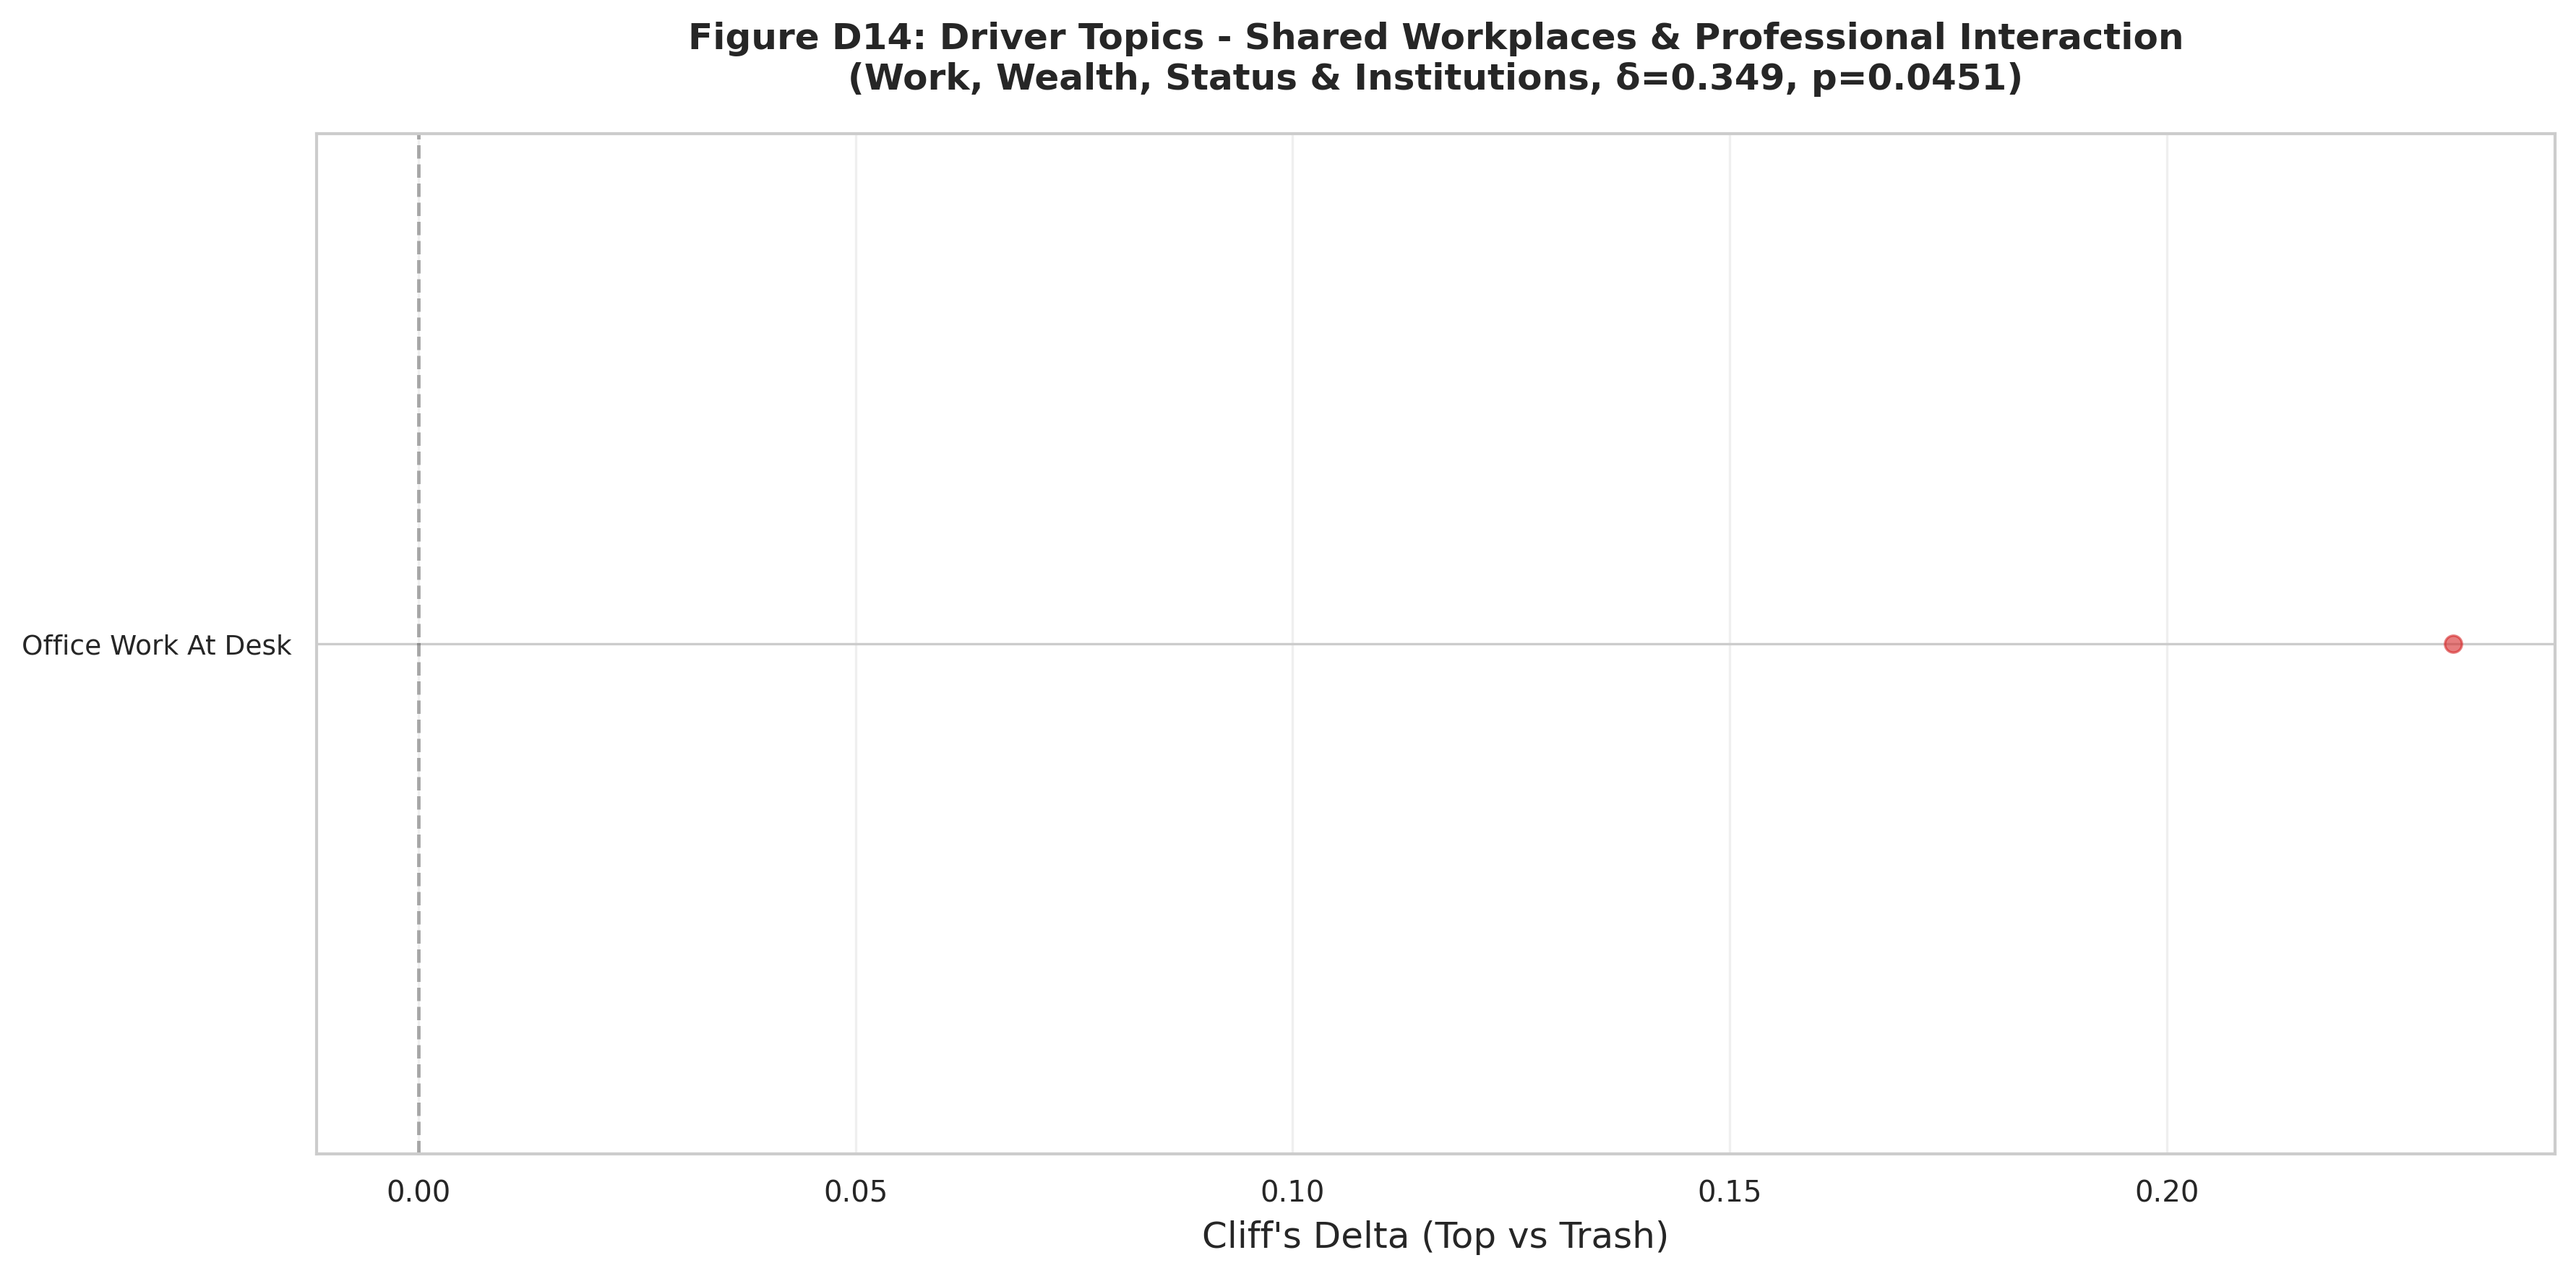

✓ Table D14 & Figure D14 saved: Shared Workplaces & Professional Interaction (1 topics)

✓ Generated 14 driver topic tables and figures


In [100]:
# Table Dk & Figure Dk: Driver Topics per Subgroup
if 'topic_drivers_df' in locals() and len(topic_drivers_df) > 0 and 'subgroup_results' in locals():
    # Get significant subgroups (|δ| ≥ 0.20 OR p < 0.10)
    sig_subgroups = subgroup_results[
        ((subgroup_results['top_vs_trash_delta'].abs() >= 0.20) |
         (subgroup_results['kruskal_p'] < 0.10)) &
        (subgroup_results['kruskal_p'].notna())
    ].copy()
    
    if len(sig_subgroups) > 0:
        print(f"Found {len(sig_subgroups)} significant subgroups for driver analysis")
        
        for idx, (_, sub_row) in enumerate(sig_subgroups.iterrows()):
            main_group = sub_row['taxonomy_main_group']
            subgroup = sub_row['taxonomy_main_name']
            delta = sub_row.get('top_vs_trash_delta', np.nan)
            p_val = sub_row.get('kruskal_p', np.nan)
            
            # Get driver topics for this subgroup
            drivers = topic_drivers_df[
                (topic_drivers_df['taxonomy_main_group'] == main_group) &
                (topic_drivers_df['taxonomy_main_name'] == subgroup)
            ].copy()
            
            if len(drivers) == 0:
                continue
            
            # Sort by absolute delta
            drivers = drivers.sort_values('abs_cliffs_top_trash', ascending=False)
            
            # Table Dk: Formatted driver topics table
            table_dk = drivers[[
                'topic_id', 'label', 'top_median', 'trash_median', 
                'cliffs_top_trash', 'mass', 'prevalence', 'author_dominance_flag'
            ]].copy()
            table_dk.columns = [
                'Topic ID', 'Label', 'Top Median', 'Trash Median',
                "Cliff's δ", 'Mass', 'Prevalence', 'Author Dominant?'
            ]
            table_dk = table_dk.round({'Top Median': 4, 'Trash Median': 4, 
                                      "Cliff's δ": 3, 'Mass': 4, 'Prevalence': 4})
            
            # Save table
            safe_name = "".join(c if c.isalnum() or c in (' ', '-', '_') else '_' for c in subgroup)[:50]
            table_dk.to_csv(REPORT_TABLE_DIR / f"Table_D{idx+1}_drivers_{safe_name}.csv", index=False)
            table_dk.to_csv(REPORT_TABLE_DIR / f"Table_D{idx+1}_drivers_{safe_name}.csv", index=False)
            
            # Figure Dk: Dot plot of driver topics
            fig, ax = plt.subplots(figsize=(12, max(6, len(drivers) * 0.4)))
            
            y_pos = np.arange(len(drivers))
            colors = ['#d62728' if d > 0 else '#1f77b4' for d in drivers['cliffs_top_trash']]
            
            ax.scatter(drivers['cliffs_top_trash'], y_pos, 
                      s=drivers['mass'] * 10000, alpha=0.6, c=colors)
            ax.axvline(x=0, color='black', linestyle='--', alpha=0.3)
            ax.set_yticks(y_pos)
            ax.set_yticklabels(drivers['label'], fontsize=9)
            ax.set_xlabel("Cliff's Delta (Top vs Trash)", fontsize=12)
            ax.set_title(f"Figure D{idx+1}: Driver Topics - {subgroup}\n"
                        f"({main_group}, δ={delta:.3f}, p={p_val:.4f})", 
                        fontsize=12, fontweight='bold', pad=15)
            ax.grid(axis='x', alpha=0.3)
            plt.tight_layout()
            
            plt.savefig(REPORT_FIG_DIR / f"Figure_D{idx+1}_drivers_{safe_name}.png", 
                       dpi=300, bbox_inches='tight')
            plt.show()
            
            # Interactive version
            fig_plotly = px.scatter(drivers, x='cliffs_top_trash', y='label',
                                   size='mass', color='cliffs_top_trash',
                                   color_continuous_scale='RdBu',
                                   title=f"Figure D{idx+1}: Driver Topics - {subgroup}",
                                   labels={'cliffs_top_trash': "Cliff's Delta (Top vs Trash)",
                                          'label': 'Topic', 'mass': 'Mass'})
            fig_plotly.update_layout(height=max(500, len(drivers) * 40))
            fig_plotly.write_html(str(REPORT_FIG_DIR / f"Figure_D{idx+1}_drivers_{safe_name}.html"))
            
            print(f"✓ Table D{idx+1} & Figure D{idx+1} saved: {subgroup} ({len(drivers)} topics)")
        
        print(f"\n✓ Generated {len(sig_subgroups)} driver topic tables and figures")
    else:
        print("⚠️  No significant subgroups found for driver analysis")
else:
    print("⚠️  topic_drivers_df or subgroup_results not available")

### Table T1: Main Group Comparisons

Export formatted main group comparison table with effect sizes and p-values.


In [101]:
# Table T1: Main Group Comparisons
if 'main_group_results' in locals() and len(main_group_results) > 0:
    # Select and format columns for report
    # Use adjusted p-value if available, otherwise use raw p-value
    p_col = 'top_vs_trash_p_adj' if 'top_vs_trash_p_adj' in main_group_results.columns else 'top_vs_trash_p'
    
    table_t1 = main_group_results[[
        'taxonomy_main_group', 'top_mean', 'trash_mean', 
        'top_vs_trash_delta', 'kruskal_p', p_col
    ]].copy()
    
    # Rename columns
    p_label = 'Top-Trash p (adj)' if p_col == 'top_vs_trash_p_adj' else 'Top-Trash p'
    table_t1.columns = [
        'Main Group', 'Top Mean', 'Trash Mean',
        'Top-Trash δ', 'KW p', p_label
    ]
    
    # Round values
    table_t1 = table_t1.round({
        'Top Mean': 4, 'Trash Mean': 4, 'Top-Trash δ': 3,
        'KW p': 4, p_label: 4
    })
    
    # Sort by absolute delta
    table_t1['abs_delta'] = table_t1['Top-Trash δ'].abs()
    table_t1 = table_t1.sort_values('abs_delta', ascending=False)
    table_t1 = table_t1.drop('abs_delta', axis=1)
    
    # Save
    table_t1.to_csv(REPORT_TABLE_DIR / "Table_T1_main_group_comparisons.csv", index=False)
    table_t1.to_csv(REPORT_TABLE_DIR / "Table_T1_main_group_comparisons.csv", index=False)
    
    print("✓ Table T1 saved: Main group comparisons")
    display(table_t1)
else:
    print("⚠️  main_group_results not available")

✓ Table T1 saved: Main group comparisons


,Main Group,Top Mean,Trash Mean,Top-Trash δ,KW p,Top-Trash p (adj)
3,Relationship Trajectory (Main Couple),0.3649,0.3503,0.373,0.0288,0.3185
5,Social World Outside Couple,0.0740,0.0673,0.300,0.1035,0.9351
1,Embodied & Sensory Experience,0.0211,0.0186,0.289,0.0593,1.0000
4,"Sexuality, Attraction & Intimacy",0.1879,0.1999,-0.253,0.0937,1.0000
2,"Emotions, Cognition & Inner Life",0.1914,0.1964,-0.136,0.3652,1.0000
0,"Conflict, Risk & Harm",0.0212,0.0238,0.111,0.6461,1.0000
7,"Work, Wealth, Status & Institutions",0.0649,0.0676,-0.100,0.2202,1.0000
6,"Spaces, Time, Activities & Objects",0.0737,0.0757,-0.038,0.9521,1.0000


### Table S1: Subgroup Comparisons

Export formatted subgroup comparison table with family-wise adjusted p-values.


In [102]:
# Table S1: Subgroup Comparisons
if 'subgroup_results' in locals() and len(subgroup_results) > 0:
    # Select and format columns
    table_s1 = subgroup_results[[
        'taxonomy_main_group', 'taxonomy_main_name',
        'top_vs_trash_delta', 'kruskal_p', 'kruskal_p_adj_family'
    ]].copy()
    
    # Rename columns
    table_s1.columns = [
        'Main Group', 'Subgroup',
        'Top-Trash δ', 'KW p (raw)', 'KW p (adj family)'
    ]
    
    # Round values
    table_s1 = table_s1.round({
        'Top-Trash δ': 3, 'KW p (raw)': 4, 'KW p (adj family)': 4
    })
    
    # Sort by main group, then by absolute delta
    table_s1['abs_delta'] = table_s1['Top-Trash δ'].abs()
    table_s1 = table_s1.sort_values(['Main Group', 'abs_delta'], ascending=[True, False])
    table_s1 = table_s1.drop('abs_delta', axis=1)
    
    # Save
    table_s1.to_csv(REPORT_TABLE_DIR / "Table_S1_subgroup_comparisons.csv", index=False)
    table_s1.to_csv(REPORT_TABLE_DIR / "Table_S1_subgroup_comparisons.csv", index=False)
    
    print("✓ Table S1 saved: Subgroup comparisons")
    print(f"  Total subgroups: {len(table_s1)}")
    print(f"  Significant (p_adj < 0.05): {(table_s1['KW p (adj family)'] < 0.05).sum()}")
    display(table_s1.head(20))
else:
    print("⚠️  subgroup_results not available")

✓ Table S1 saved: Subgroup comparisons
  Total subgroups: 27
  Significant (p_adj < 0.05): 1


,Main Group,Subgroup,Top-Trash δ,KW p (raw),KW p (adj family)
0,"Conflict, Risk & Harm",Interpersonal Non-Romantic Conflict,0.296,0.0961,0.1922
1,"Conflict, Risk & Harm","Violence, Threats & Coercion",-0.296,0.0961,0.1922
2,Embodied & Sensory Experience,Body Parts & Physical Reactions,0.091,0.7113,1.0000
3,Embodied & Sensory Experience,Exercise & Physical Activity,-0.091,0.7113,1.0000
5,"Emotions, Cognition & Inner Life","Beliefs, Values & Moral Reflection",0.464,0.0048,0.0192
6,"Emotions, Cognition & Inner Life",Negative Emotions & Distress,-0.369,0.0432,0.1297
7,"Emotions, Cognition & Inner Life",Positive Emotions & Security,0.316,0.0980,0.1961
4,"Emotions, Cognition & Inner Life",Ambivalence & Internal Conflict,0.131,0.6688,0.6688
10,Relationship Trajectory (Main Couple),"Meeting, First Impressions & Setup",0.249,0.2277,1.0000
11,Relationship Trajectory (Main Couple),"Reconciliation, Commitments & HEA",0.171,0.3303,1.0000


In [103]:
print("\n" + "=" * 80)
print("Report-Ready Outputs Summary")
print("=" * 80)
print(f"\nAll outputs saved to: {REPORT_DIR}")
print(f"\nFigures: {REPORT_FIG_DIR}")
print(f"Tables: {REPORT_TABLE_DIR}")
print("\n✓ Report generation complete!")


Report-Ready Outputs Summary

All outputs saved to: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/02_taxonomy_group_analysis/report_figures_tables

Figures: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/02_taxonomy_group_analysis/report_figures_tables/figures
Tables: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/02_taxonomy_group_analysis/report_figures_tables/tables

✓ Report generation complete!


## Summary

This notebook implements the taxonomy group analysis pipeline:

1. **Spine Export**: `topic_taxonomy_mapping.csv` - single source of truth for topic-to-taxonomy mappings
2. **Dual Normalization**: Absolute and conditional shares to handle OTHER bucket variation
3. **Main Group Comparisons**: ~7-8 main groups compared across tiers with Kruskal-Wallis and effect sizes
4. **Subgroup Analysis**: Within-group normalization and tier comparisons per main group
5. **Topic Drivers**: Ranking of top topics driving subgroup differences

**Key Outputs:**
- `book_main_group_shares.parquet/csv`: Book-level main group shares (absolute + conditional)
- `book_subgroup_shares.parquet/csv`: Book-level subgroup shares (within-group normalized)
- `main_group_comparisons.parquet/csv`: Statistical test results for main groups
- `subgroup_comparisons.parquet/csv`: Statistical test results for subgroups
- `subgroup_topic_drivers.parquet/csv`: Top topic drivers for significant subgroups
- Figures in `figures/main_group_distributions/` and `figures/subgroup_distributions/`

**Next Steps:**
- Use subgroup shares to build A-S composites for hypothesis testing (H1-H6)
- Refine taxonomy mappings based on coherence audit of topic drivers